# belief eye neural analysis


## imports

In [43]:
%reload_ext autoreload
%autoreload 2

In [44]:
import sys
import os
from pathlib import Path
import configparser
config = configparser.ConfigParser()
config.read_file(open('privateconfig'))
resdir = Path(config['Datafolder']['data'])
workdir = Path(config['Codefolder']['workspace'])
os.chdir(workdir)

In [61]:
# analysis
from scipy.io import loadmat
from sklearn.decomposition import FastICA
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from sklearn.cross_decomposition import CCA
from scipy.stats import pearsonr
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression

In [46]:
# misc
import pickle
from collections import defaultdict

In [47]:
from neural_plot_ult import *
import time
tic=time.time()
import warnings
warnings.filterwarnings('ignore')

## load data

In [48]:
df = pd.read_pickle(resdir/'0417_m51df.pkl')
len(df)
df=df[df.session==41]

In [49]:
def process_one(y):
    related_taskvar=np.array(normalize_z(y))
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    related_taskvar[~mask]=0
    return related_taskvar, mask

def process(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    related_taskvar=np.vstack(rawtaskvar).T
    # related_taskvar=np.clip(related_taskvar,-4,4)
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    mask=np.all(mask, axis=1)
    related_taskvar=related_taskvar[mask]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar
def process_list(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    mask=[(a > -4) & (a < 4) for a in rawtaskvar]
    mask=np.all(mask)
    related_taskvar=[a[mask] for a in rawtaskvar]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar

In [50]:
# error distribution
def get_stop_error(row):
    return ((row.fx[-1]-row.mx[-1])**2+(row.fy[-1]-row.my[-1])**2)**0.5
df['state_error']=df.apply(get_stop_error, axis=1)
def get_stop_error(row):
    return ((row.fx[-1]-row.bmx[-1])**2+(row.fy[-1]-row.bmy[-1])**2)**0.5
df['belief_error']=df.apply(get_stop_error, axis=1)

# time ratio
df['time_ratio']=df.apply(lambda x: x.timer/x.timer[-1], axis=1)


In [51]:
for session in sorted(df.session.unique())[:1]:
    sessdf=df[(df.session==session)]

state=np.concatenate(sessdf.belief_ff_hori.to_numpy())
belief=np.concatenate(sessdf.ff_hori.to_numpy())
eye=np.concatenate(sessdf.eye_hori.to_numpy())
timeratio=np.concatenate(sessdf.time_ratio.to_numpy())
timer=np.concatenate(sessdf.timer.to_numpy())
countdown=np.concatenate(sessdf.countdown.to_numpy())


In [52]:
sessdf.columns

Index(['trial', 'session', 'fullon', 'density', 'eye_hori', 'eye_vert',
       'ff_hori', 'ff_vert', 'fx', 'fy', 'mx', 'my', 'mv', 'mw', 'PPC',
       'PPC_var', 'PFC', 'PFC_var', 'MST', 'MST_var', 'error', 'error_sign',
       'target_angle', 'target_distance', 'state', 'action', 'task',
       'likelihood', 'belief', 'rawcov', 'bmx', 'bmy', 'heading',
       'belief_heading', 'timer', 'countdown', 'belief_ff_hori',
       'belief_ff_vert', 'angle_from_start', 'belief_angle_from_start',
       'relcov', 'state_error', 'belief_error', 'time_ratio'],
      dtype='object')

In [ ]:
# make a df by time (each row is a time, instead of a trial)
sessdf['density_t']=sessdf.apply(lambda x: np.array([[x.density]*len(x.mx)]).reshape(-1), axis=1)
sessdf['fullon_t']=sessdf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
sessdf['error_t']=sessdf.apply(lambda x: np.array([[x.error]*len(x.mx)]).reshape(-1), axis=1)
sessdf['triallen_t']=sessdf.apply(lambda x: np.array([[len(x.mx)]*len(x.mx)]).reshape(-1), axis=1)
sessdf['trial_t']=sessdf.apply(lambda x: np.array([[x.trial]*len(x.mx)]).reshape(-1), axis=1)


timedf=pd.DataFrame({'timer':timer})
# timedf['rawcov']=list(np.vstack(sessdf['rawcov'].to_numpy()))
timedf['belief']=np.concatenate(sessdf.belief_ff_hori.to_numpy())
timedf['state']=np.concatenate(sessdf.ff_hori.to_numpy())
timedf['eye']=np.concatenate(sessdf.eye_hori.to_numpy())
timedf['timeratio']=np.concatenate(sessdf.time_ratio.to_numpy())
timedf['mv']=np.concatenate(sessdf.mv.to_numpy())
timedf['mw']=np.concatenate(sessdf.mw.to_numpy())
timedf['belief_heading']=np.concatenate(sessdf.belief_heading.to_numpy())
timedf['timer']=np.concatenate(sessdf.timer.to_numpy())
timedf['countdown']=np.concatenate(sessdf.countdown.to_numpy())
timedf['belief_angle_from_start']=np.concatenate(sessdf.belief_angle_from_start.to_numpy())
timedf['PPC']=list(np.vstack(sessdf.PPC.to_numpy()))
timedf['PPC_var']=list(np.vstack(sessdf.PPC_var.to_numpy()))

timedf['uncertainty']=list(np.concatenate(sessdf.relcov.to_numpy()))

timedf['density']=np.concatenate(sessdf.density_t.to_numpy())
timedf['fullon']=np.concatenate(sessdf.fullon_t.to_numpy())
timedf['error']=np.concatenate(sessdf.error_t.to_numpy())
timedf['trial']=np.concatenate(sessdf.trial_t.to_numpy())


timedf['dbelief']=np.concatenate(sessdf.apply(lambda x: np.diff(x.belief_ff_hori, prepend=x.belief_ff_hori[:1],axis=0),axis=1).to_numpy())
timedf['deye']=np.concatenate(sessdf.apply(lambda x: np.diff(x.eye_hori, prepend=x.eye_hori[:1],axis=0),axis=1).to_numpy())
timedf['dneural']=list(np.vstack(sessdf.apply(lambda x: np.diff(x.PPC, prepend=x.PPC[:1], axis=0),axis=1).to_numpy()))


timedf.head()
timedf = timedf.dropna(subset=['eye', 'state', 'belief'])

# neural rate --> uncertainty



Analyzing uncertainty updates in detail...

Top 5 pre-update neural dimensions predicting uncertainty updates:
Dimension 105: r=0.289 (p=0.000e+00)
Dimension 68: r=0.264 (p=0.000e+00)
Dimension 39: r=0.241 (p=0.000e+00)
Dimension 6: r=0.233 (p=0.000e+00)
Dimension 65: r=0.232 (p=0.000e+00)

Top 5 post-update neural dimensions correlating with uncertainty updates:
Dimension 105: r=0.292 (p=0.000e+00)
Dimension 68: r=0.268 (p=0.000e+00)
Dimension 39: r=0.243 (p=0.000e+00)
Dimension 6: r=0.239 (p=0.000e+00)
Dimension 65: r=0.234 (p=0.000e+00)

Top 5 neural change dimensions correlating with uncertainty updates:
Dimension 6: r=0.050 (p=2.652e-220)
Dimension 0: r=0.032 (p=2.163e-89)
Dimension 70: r=0.030 (p=1.351e-81)
Dimension 79: r=0.026 (p=1.173e-62)
Dimension 66: r=0.026 (p=1.684e-61)

Pre-update neural prediction: R² = 0.269, r = 0.519 (p=0.000e+00)
Post-update neural prediction: R² = 0.275, r = 0.525 (p=0.000e+00)
Neural change prediction: R² = 0.010, r = 0.101 (p=0.000e+00)
Observat

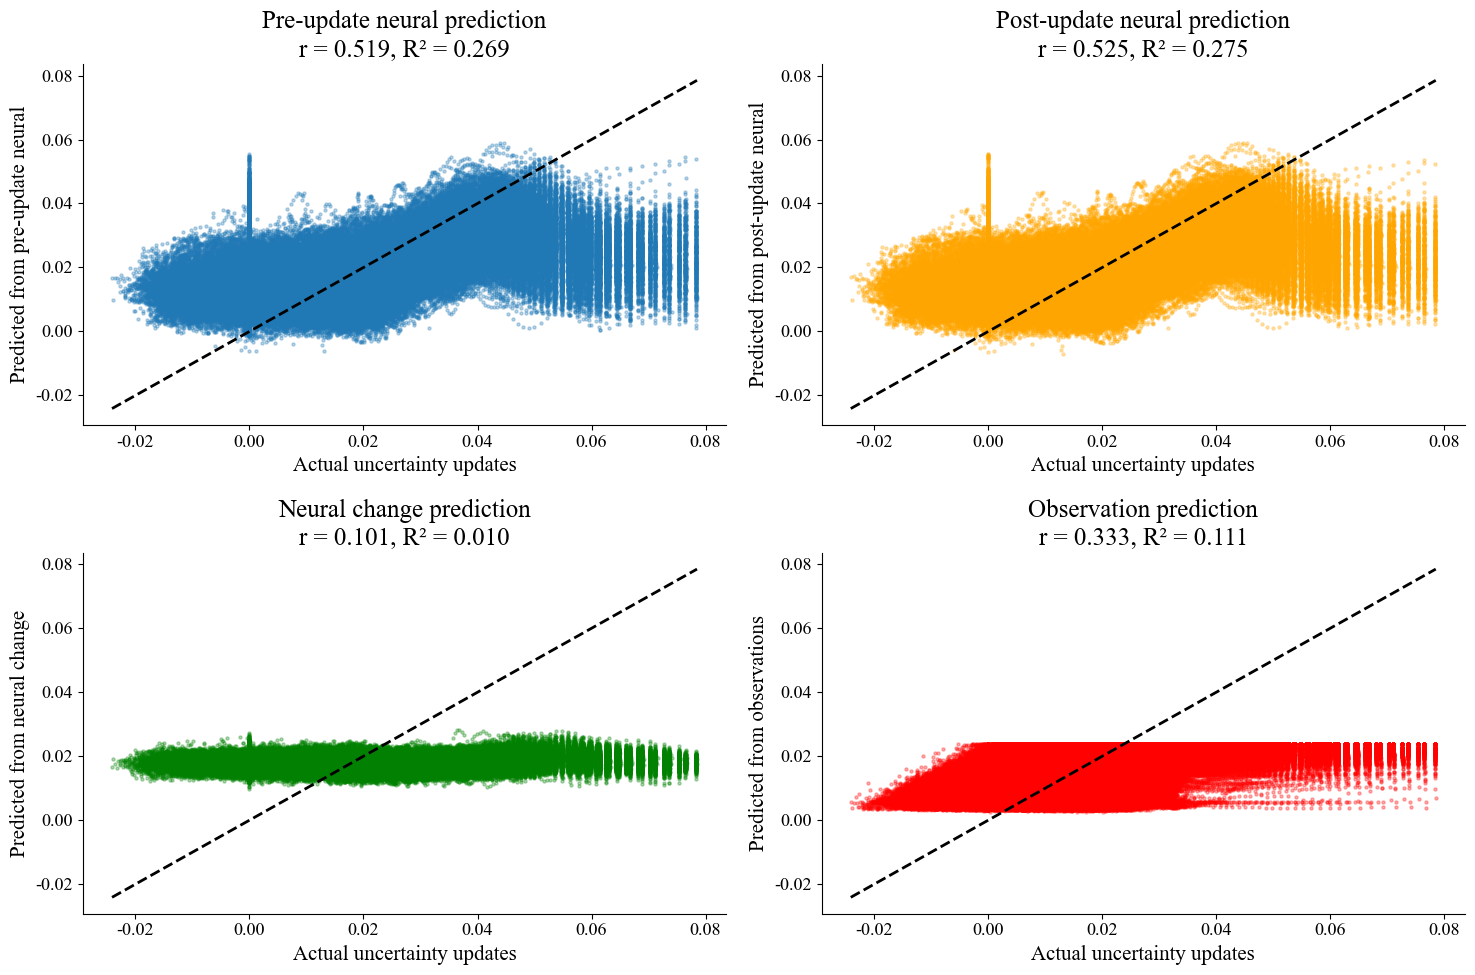

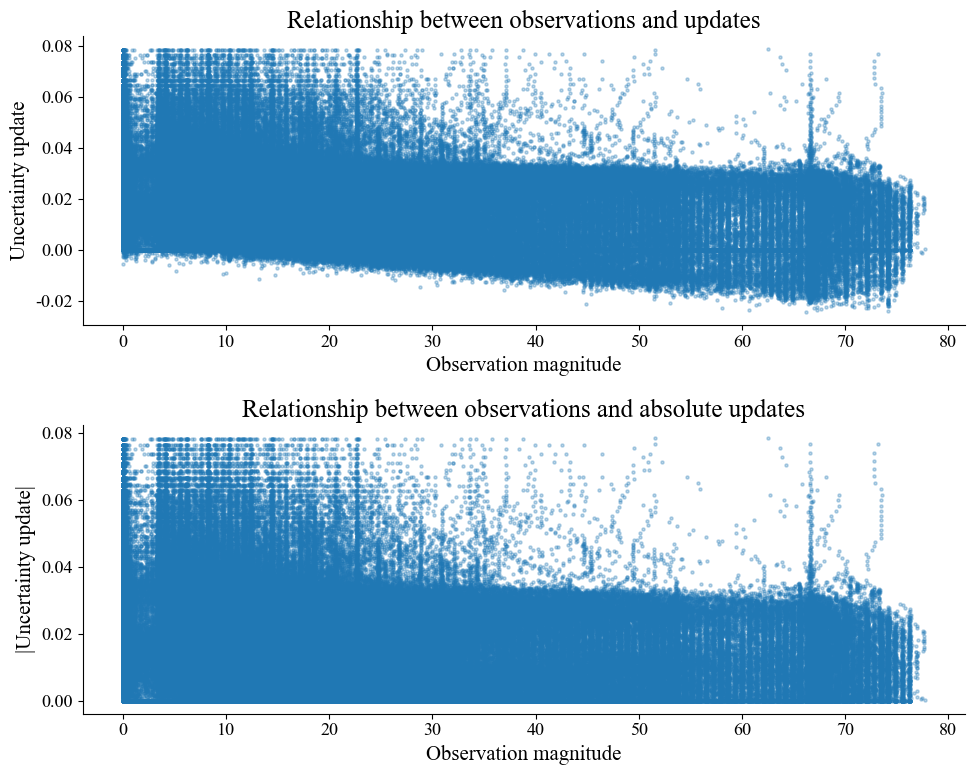

In [67]:
def analyze_detailed_updates(timedf, sessdf):
    """Analyze uncertainty updates in more detail"""
    print("\nAnalyzing uncertainty updates in detail...")
    
    # Import necessary libraries
    from scipy.stats import pearsonr
    from sklearn.metrics import r2_score
    from sklearn.model_selection import KFold, cross_val_predict
    from sklearn.linear_model import LinearRegression
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Extract relevant variables
    neural_data = np.stack(timedf.PPC.to_numpy())
    dneural_data = np.stack(timedf.dneural.to_numpy())  # Neural activity change
    beh_uncertainty = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5  # std
    trial_ids = timedf.trial.to_numpy()
    obs = np.abs(timedf.mw.to_numpy())  # Absolute observation values
    
    # Calculate updates within each trial
    updates_data = []
    
    unique_trials = np.unique(trial_ids)
    for trial in unique_trials:
        trial_mask = trial_ids == trial
        if sum(trial_mask) < 3:  # Skip very short trials
            continue
            
        # Get trial data
        trial_neural = neural_data[trial_mask]
        trial_dneural = dneural_data[trial_mask]
        trial_uncertain = beh_uncertainty[trial_mask]
        trial_obs = obs[trial_mask]
        
        # Calculate updates
        for t in range(1, len(trial_uncertain)):
            updates_data.append({
                'trial': trial,
                'time': t,
                'uncertainty': trial_uncertain[t-1],
                'next_uncertainty': trial_uncertain[t],
                'update': trial_uncertain[t] - trial_uncertain[t-1],
                'neural': trial_neural[t-1],  # Neural activity before update
                'next_neural': trial_neural[t],  # Neural activity after update
                'dneural': trial_dneural[t],  # Change in neural activity
                'obs': trial_obs[t-1]  # Observation at time of update
            })
    
    # Convert to DataFrame
    updates_df = pd.DataFrame(updates_data)
    
    # Extract arrays for analysis
    updates = np.array(updates_df['update'])
    neural_pre = np.stack(updates_df['neural'].to_list())
    neural_post = np.stack(updates_df['next_neural'].to_list())
    dneural = np.stack(updates_df['dneural'].to_list())
    observations = np.array(updates_df['obs'])
    
    # Find neural dimensions that best predict updates
    n_dims = neural_pre.shape[1]
    update_corrs_pre = []
    update_corrs_post = []
    update_corrs_delta = []
    
    for i in range(n_dims):
        # Correlation between pre-update neural activity and update
        corr_pre, p_pre = pearsonr(neural_pre[:, i], updates)
        update_corrs_pre.append((corr_pre, p_pre))
        
        # Correlation between post-update neural activity and update
        corr_post, p_post = pearsonr(neural_post[:, i], updates)
        update_corrs_post.append((corr_post, p_post))
        
        # Correlation between change in neural activity and update
        corr_delta, p_delta = pearsonr(dneural[:, i], updates)
        update_corrs_delta.append((corr_delta, p_delta))
    
    # Find top dimensions
    update_corrs_pre_abs = [abs(c[0]) for c in update_corrs_pre]
    update_corrs_post_abs = [abs(c[0]) for c in update_corrs_post]
    update_corrs_delta_abs = [abs(c[0]) for c in update_corrs_delta]
    
    top_pre_dims = np.argsort(update_corrs_pre_abs)[::-1][:5]
    top_post_dims = np.argsort(update_corrs_post_abs)[::-1][:5]
    top_delta_dims = np.argsort(update_corrs_delta_abs)[::-1][:5]
    
    print("\nTop 5 pre-update neural dimensions predicting uncertainty updates:")
    for i, dim in enumerate(top_pre_dims):
        corr, p = update_corrs_pre[dim]
        print(f"Dimension {dim}: r={corr:.3f} (p={p:.3e})")
    
    print("\nTop 5 post-update neural dimensions correlating with uncertainty updates:")
    for i, dim in enumerate(top_post_dims):
        corr, p = update_corrs_post[dim]
        print(f"Dimension {dim}: r={corr:.3f} (p={p:.3e})")
    
    print("\nTop 5 neural change dimensions correlating with uncertainty updates:")
    for i, dim in enumerate(top_delta_dims):
        corr, p = update_corrs_delta[dim]
        print(f"Dimension {dim}: r={corr:.3f} (p={p:.3e})")
    
    # Build models to predict updates
    model_pre = LinearRegression()
    model_post = LinearRegression()
    model_delta = LinearRegression()
    model_obs = LinearRegression()
    
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    pre_predictions = cross_val_predict(model_pre, neural_pre, updates, cv=cv)
    post_predictions = cross_val_predict(model_post, neural_post, updates, cv=cv)
    delta_predictions = cross_val_predict(model_delta, dneural, updates, cv=cv)
    obs_predictions = cross_val_predict(model_obs, observations.reshape(-1, 1), updates, cv=cv)
    
    # Evaluate models
    r2_pre = r2_score(updates, pre_predictions)
    r2_post = r2_score(updates, post_predictions)
    r2_delta = r2_score(updates, delta_predictions)
    r2_obs = r2_score(updates, obs_predictions)
    
    corr_pre, p_pre = pearsonr(updates, pre_predictions)
    corr_post, p_post = pearsonr(updates, post_predictions)
    corr_delta, p_delta = pearsonr(updates, delta_predictions)
    corr_obs, p_obs = pearsonr(updates, obs_predictions)
    
    print(f"\nPre-update neural prediction: R² = {r2_pre:.3f}, r = {corr_pre:.3f} (p={p_pre:.3e})")
    print(f"Post-update neural prediction: R² = {r2_post:.3f}, r = {corr_post:.3f} (p={p_post:.3e})")
    print(f"Neural change prediction: R² = {r2_delta:.3f}, r = {corr_delta:.3f} (p={p_delta:.3e})")
    print(f"Observation-only prediction: R² = {r2_obs:.3f}, r = {corr_obs:.3f} (p={p_obs:.3e})")
    
    # Plot results
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    plt.scatter(updates, pre_predictions, alpha=0.3, s=5)
    plt.plot([min(updates), max(updates)], [min(updates), max(updates)], 'k--')
    plt.xlabel('Actual uncertainty updates')
    plt.ylabel('Predicted from pre-update neural')
    plt.title(f'Pre-update neural prediction\nr = {corr_pre:.3f}, R² = {r2_pre:.3f}')
    
    plt.subplot(2, 2, 2)
    plt.scatter(updates, post_predictions, alpha=0.3, s=5, color='orange')
    plt.plot([min(updates), max(updates)], [min(updates), max(updates)], 'k--')
    plt.xlabel('Actual uncertainty updates')
    plt.ylabel('Predicted from post-update neural')
    plt.title(f'Post-update neural prediction\nr = {corr_post:.3f}, R² = {r2_post:.3f}')
    
    plt.subplot(2, 2, 3)
    plt.scatter(updates, delta_predictions, alpha=0.3, s=5, color='green')
    plt.plot([min(updates), max(updates)], [min(updates), max(updates)], 'k--')
    plt.xlabel('Actual uncertainty updates')
    plt.ylabel('Predicted from neural change')
    plt.title(f'Neural change prediction\nr = {corr_delta:.3f}, R² = {r2_delta:.3f}')
    
    plt.subplot(2, 2, 4)
    plt.scatter(updates, obs_predictions, alpha=0.3, s=5, color='red')
    plt.plot([min(updates), max(updates)], [min(updates), max(updates)], 'k--')
    plt.xlabel('Actual uncertainty updates')
    plt.ylabel('Predicted from observations')
    plt.title(f'Observation prediction\nr = {corr_obs:.3f}, R² = {r2_obs:.3f}')
    
    plt.tight_layout()
    plt.show()
    
    # Plot relationship between updates and observations
    plt.figure(figsize=(10, 8))
    
    plt.subplot(2, 1, 1)
    plt.scatter(observations, updates, alpha=0.3, s=5)
    plt.xlabel('Observation magnitude')
    plt.ylabel('Uncertainty update')
    plt.title('Relationship between observations and updates')
    
    plt.subplot(2, 1, 2)
    plt.scatter(observations, abs(updates), alpha=0.3, s=5)
    plt.xlabel('Observation magnitude')
    plt.ylabel('|Uncertainty update|')
    plt.title('Relationship between observations and absolute updates')
    
    plt.tight_layout()
    plt.show()
    
    return updates_df, {
        'pre': {'r2': r2_pre, 'corr': corr_pre, 'top_dims': top_pre_dims},
        'post': {'r2': r2_post, 'corr': corr_post, 'top_dims': top_post_dims},
        'delta': {'r2': r2_delta, 'corr': corr_delta, 'top_dims': top_delta_dims},
        'obs': {'r2': r2_obs, 'corr': corr_obs}
    }

updates_df, updates_results = analyze_detailed_updates(timedf, sessdf)

Active control / compensation:
When animals move faster (higher angular velocity), they might engage stronger active correction mechanisms — like faster feedback loops to stabilize their position.
So even if raw sensory noise increases with speed, behaviorally they compensate more effectively.

Speed-dependent sensory gain:
Some systems upregulate sensory input at higher speeds — e.g., visual systems can "boost" gain when motion is faster.
This would flatten the relationship between speed and uncertainty.

Different noise regimes:
At low speeds, noise might be sensory-limited (e.g., visual/vestibular noise), but at high speeds, it could be motor-limited (execution noise, delayed responses), and those two types of noise scale differently with speed.

Nonlinear Weber scaling:
In real systems (especially biological ones), Weber’s Law often breaks down at extremes (very high or very low stimulus values).
There's sometimes a compressive nonlinearity: noise increases with speed, but sublinearly (e.g., noise ~ speed^0.7 instead of speed^1).

Task structure / demands:
If in your task higher angular speed naturally leads to more frequent feedback (like passing landmarks or reorienting), animals could anchor their position estimates more often, reducing uncertainty growth.


Analyzing how neural encoding varies with update magnitude...

Small updates (n=132847):
Neural prediction: R² = 0.036, r = 0.190 (p=0.000e+00)
Observation prediction: R² = 0.060, r = 0.245 (p=0.000e+00)
Top 5 dimensions for Small updates:
Dimension 6: r=-0.086 (p=4.030e-215)
Dimension 105: r=-0.071 (p=1.114e-146)
Dimension 0: r=-0.065 (p=1.355e-125)
Dimension 79: r=-0.063 (p=1.422e-117)
Dimension 78: r=-0.061 (p=3.389e-109)

Medium updates (n=132886):
Neural prediction: R² = 0.085, r = 0.291 (p=0.000e+00)
Observation prediction: R² = 0.071, r = 0.267 (p=0.000e+00)
Top 5 dimensions for Medium updates:
Dimension 6: r=0.093 (p=4.136e-252)
Dimension 24: r=-0.079 (p=6.632e-184)
Dimension 19: r=-0.071 (p=2.474e-147)
Dimension 38: r=-0.070 (p=1.158e-144)
Dimension 104: r=0.070 (p=3.529e-143)

Large updates (n=132847):
Neural prediction: R² = 0.334, r = 0.578 (p=0.000e+00)
Observation prediction: R² = 0.185, r = 0.430 (p=0.000e+00)
Top 5 dimensions for Large updates:
Dimension 6: r=-0.390 (p

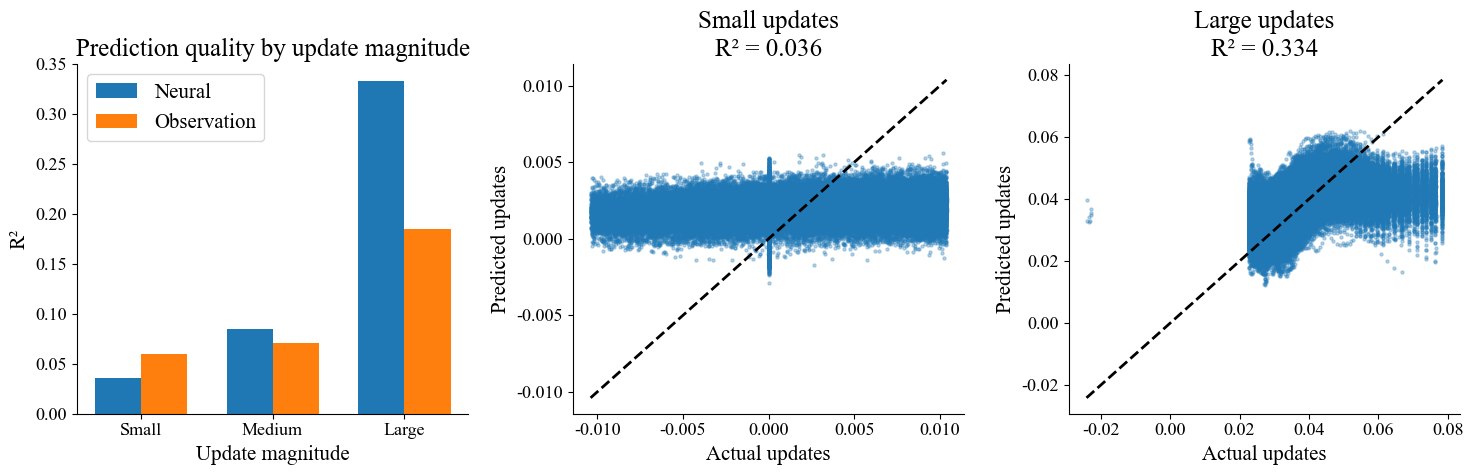

In [69]:
def analyze_update_magnitude(timedf, updates_df):
    """Analyze how neural encoding varies with magnitude of uncertainty updates"""
    print("\nAnalyzing how neural encoding varies with update magnitude...")
    
    # Import necessary libraries
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import pearsonr
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import r2_score
    
    # Extract updates from the DataFrame
    updates = np.array(updates_df['update'])
    neural_pre = np.stack(updates_df['neural'].to_list())
    observations = np.array(updates_df['obs'])
    
    # Categorize updates by magnitude
    abs_updates = np.abs(updates)
    update_terciles = np.percentile(abs_updates, [33.33, 66.67])
    
    small_mask = abs_updates <= update_terciles[0]
    medium_mask = (abs_updates > update_terciles[0]) & (abs_updates <= update_terciles[1])
    large_mask = abs_updates > update_terciles[1]
    
    # Analyze correlation for each update magnitude category
    def analyze_category(mask, name):
        if sum(mask) < 10:  # Skip if too few samples
            return None
            
        cat_updates = updates[mask]
        cat_neural = neural_pre[mask]
        cat_obs = observations[mask]
        
        # Find neural dimensions with strongest correlation
        cat_corrs = []
        for dim in range(cat_neural.shape[1]):
            corr, p = pearsonr(cat_neural[:, dim], cat_updates)
            cat_corrs.append((corr, p))
        
        # Find top dimensions
        cat_corrs_abs = [abs(c[0]) for c in cat_corrs]
        top_dims = np.argsort(cat_corrs_abs)[::-1][:5]
        
        # Build model
        model = LinearRegression()
        model.fit(cat_neural, cat_updates)
        predictions = model.predict(cat_neural)
        
        # Evaluate
        r2 = r2_score(cat_updates, predictions)
        corr, p = pearsonr(cat_updates, predictions)
        
        # Observation-only model
        obs_model = LinearRegression()
        obs_model.fit(cat_obs.reshape(-1, 1), cat_updates)
        obs_predictions = obs_model.predict(cat_obs.reshape(-1, 1))
        
        obs_r2 = r2_score(cat_updates, obs_predictions)
        obs_corr, obs_p = pearsonr(cat_updates, obs_predictions)
        
        print(f"\n{name} updates (n={sum(mask)}):")
        print(f"Neural prediction: R² = {r2:.3f}, r = {corr:.3f} (p={p:.3e})")
        print(f"Observation prediction: R² = {obs_r2:.3f}, r = {obs_corr:.3f} (p={obs_p:.3e})")
        
        print(f"Top 5 dimensions for {name} updates:")
        for i, dim in enumerate(top_dims):
            dim_corr, dim_p = cat_corrs[dim]
            print(f"Dimension {dim}: r={dim_corr:.3f} (p={dim_p:.3e})")
        
        return {
            'updates': cat_updates,
            'predictions': predictions,
            'obs_predictions': obs_predictions,
            'r2': r2,
            'corr': corr,
            'obs_r2': obs_r2,
            'obs_corr': obs_corr,
            'top_dims': top_dims,
            'dim_corrs': cat_corrs
        }
    
    small_results = analyze_category(small_mask, "Small")
    medium_results = analyze_category(medium_mask, "Medium")
    large_results = analyze_category(large_mask, "Large")
    
    # Plot results
    plt.figure(figsize=(15, 5))
    
    # Compare R² across update magnitudes
    categories = ['Small', 'Medium', 'Large']
    neural_r2 = [small_results['r2'], medium_results['r2'], large_results['r2']]
    obs_r2 = [small_results['obs_r2'], medium_results['obs_r2'], large_results['obs_r2']]
    
    plt.subplot(1, 3, 1)
    bar_width = 0.35
    x = np.arange(len(categories))
    plt.bar(x - bar_width/2, neural_r2, bar_width, label='Neural')
    plt.bar(x + bar_width/2, obs_r2, bar_width, label='Observation')
    plt.xlabel('Update magnitude')
    plt.ylabel('R²')
    plt.title('Prediction quality by update magnitude')
    plt.xticks(x, categories)
    plt.legend()
    
    # Compare scatter plots for small vs large updates
    plt.subplot(1, 3, 2)
    plt.scatter(small_results['updates'], small_results['predictions'], alpha=0.3, s=5, label='Predictions')
    plt.plot([min(small_results['updates']), max(small_results['updates'])], 
             [min(small_results['updates']), max(small_results['updates'])], 'k--')
    plt.xlabel('Actual updates')
    plt.ylabel('Predicted updates')
    plt.title(f'Small updates\nR² = {small_results["r2"]:.3f}')
    
    plt.subplot(1, 3, 3)
    plt.scatter(large_results['updates'], large_results['predictions'], alpha=0.3, s=5, label='Predictions')
    plt.plot([min(large_results['updates']), max(large_results['updates'])], 
             [min(large_results['updates']), max(large_results['updates'])], 'k--')
    plt.xlabel('Actual updates')
    plt.ylabel('Predicted updates')
    plt.title(f'Large updates\nR² = {large_results["r2"]:.3f}')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'small': small_results,
        'medium': medium_results,
        'large': large_results
    }

magnitude_results = analyze_update_magnitude(timedf, updates_df)

Large updates are encoded much more strongly (R² = 0.334) than medium (R² = 0.085) or small updates (R² = 0.036). This suggests the neural system is specifically tuned to represent significant changes in uncertainty rather than minor fluctuations.
Neural prediction outperforms observation-based prediction for large updates (R² = 0.334 vs. 0.185), but for small updates, observations are slightly better predictors (R² = 0.060 vs. 0.036). This suggests a threshold effect where neural encoding becomes more prominent when updates exceed a certain magnitude.
Different neural dimensions encode different update magnitudes. While dimension 6 appears consistently important across all update sizes, large updates recruit additional dimensions (105, 39, 77, 66) that aren't dominant for small updates.


Analyzing neural decoded uncertainty at onset vs initial target distance...
Generating neural decoded uncertainty...
Neural uncertainty decoder: R² = 0.148, r = 0.385 (p=0.000e+00)
Onset period contains 39919 time points
Correlation between initial target distance and mean neural uncertainty: r=-0.161 (p=2.399e-10)
Correlation between initial target distance and std of neural uncertainty: r=0.203 (p=8.996e-16)


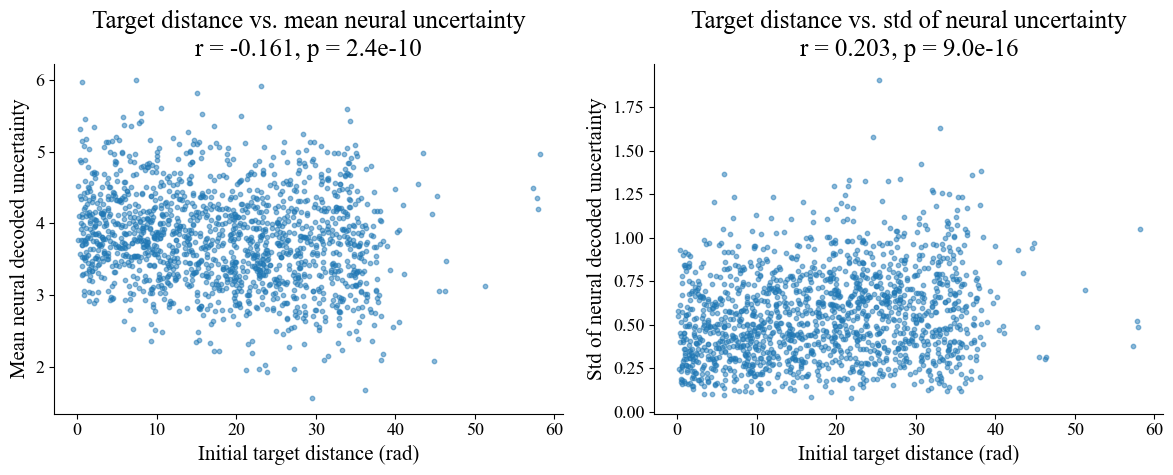

In [84]:
def analyze_onset_uncertainty_vs_distance(timedf, sessdf):
    """
    Analyze relationship between neural decoded uncertainty at onset and initial target distance
    """
    print("\nAnalyzing neural decoded uncertainty at onset vs initial target distance...")
    
    # Import necessary libraries
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import pearsonr
    from sklearn.linear_model import LinearRegression
    from sklearn.model_selection import cross_val_predict
    from sklearn.metrics import r2_score
    
    # Extract variables
    neural_data = np.stack(timedf.PPC.to_numpy())
    beh_uncertainty = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5  # std
    belief_angle_from_start = timedf.belief.to_numpy()  # Angle from start
    timer = timedf.timer.to_numpy()
    trial_ids = timedf.trial.to_numpy()
    
    # Generate neural decoded uncertainty using linear regression
    print("Generating neural decoded uncertainty...")
    model = LinearRegression()
    neural_uncertainty = cross_val_predict(model, neural_data, beh_uncertainty, cv=5)
    
    # Evaluate model
    r2 = r2_score(beh_uncertainty, neural_uncertainty)
    corr, p = pearsonr(beh_uncertainty, neural_uncertainty)
    print(f"Neural uncertainty decoder: R² = {r2:.3f}, r = {corr:.3f} (p={p:.3e})")
    
    # Define onset period (0.05 to 0.2) in time ratio
    onset_mask = (timer >= 5) & (timer <= 30)
    print(f"Onset period contains {sum(onset_mask)} time points")
    
    # Group data by trials
    trial_data = []
    
    unique_trials = np.unique(trial_ids)
    for trial in unique_trials:
        # Trial mask and onset mask for this trial
        trial_mask = trial_ids == trial
        trial_onset_mask = trial_mask & onset_mask
        
        # Skip trials with no onset data
        if sum(trial_onset_mask) < 3:  # Require at least 3 time points
            continue
        
        # Get onset data
        onset_belief = np.abs(belief_angle_from_start[trial_onset_mask])  # Use absolute angle
        mean_onset_belief = np.mean(onset_belief)
        
        # Get neural decoded uncertainty at onset
        onset_neural_uncertainty = neural_uncertainty[trial_onset_mask]
        mean_neural_uncertainty = np.mean(onset_neural_uncertainty)
        std_neural_uncertainty = np.std(onset_neural_uncertainty)
        
        # Store trial data
        trial_data.append({
            'trial': trial,
            'mean_onset_belief': mean_onset_belief,
            'mean_neural_uncertainty': mean_neural_uncertainty,
            'std_neural_uncertainty': std_neural_uncertainty,
            'n_points': sum(trial_onset_mask)
        })
    
    # Convert to DataFrame
    trial_df = pd.DataFrame(trial_data)
    
    # Calculate correlations
    mean_corr, mean_p = pearsonr(trial_df['mean_onset_belief'], trial_df['mean_neural_uncertainty'])
    std_corr, std_p = pearsonr(trial_df['mean_onset_belief'], trial_df['std_neural_uncertainty'])
    
    print(f"Correlation between initial target distance and mean neural uncertainty: r={mean_corr:.3f} (p={mean_p:.3e})")
    print(f"Correlation between initial target distance and std of neural uncertainty: r={std_corr:.3f} (p={std_p:.3e})")
    
    # Plot results
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(trial_df['mean_onset_belief'], trial_df['mean_neural_uncertainty'], alpha=0.5, s=10)
    plt.xlabel('Initial target distance (rad)')
    plt.ylabel('Mean neural decoded uncertainty')
    plt.title(f'Target distance vs. mean neural uncertainty\nr = {mean_corr:.3f}, p = {mean_p:.1e}')
    
    plt.subplot(1, 2, 2)
    plt.scatter(trial_df['mean_onset_belief'], trial_df['std_neural_uncertainty'], alpha=0.5, s=10)
    plt.xlabel('Initial target distance (rad)')
    plt.ylabel('Std of neural decoded uncertainty')
    plt.title(f'Target distance vs. std of neural uncertainty\nr = {std_corr:.3f}, p = {std_p:.1e}')
    
    plt.tight_layout()
    plt.show()
    
    return trial_df, neural_uncertainty

onset_uncertainty_df, neural_uncertainty = analyze_onset_uncertainty_vs_distance(timedf, sessdf)


Analyzing relationship between observations and uncertainty updates...
Correlation between observation magnitude and behavioral uncertainty update: r=-0.333 (p=0.000e+00)
Correlation between observation magnitude and neural uncertainty update: r=0.056 (p=2.936e-276)
Correlation between observation magnitude and |behavioral uncertainty update|: r=-0.275 (p=0.000e+00)
Correlation between observation magnitude and |neural uncertainty update|: r=-0.044 (p=1.320e-171)


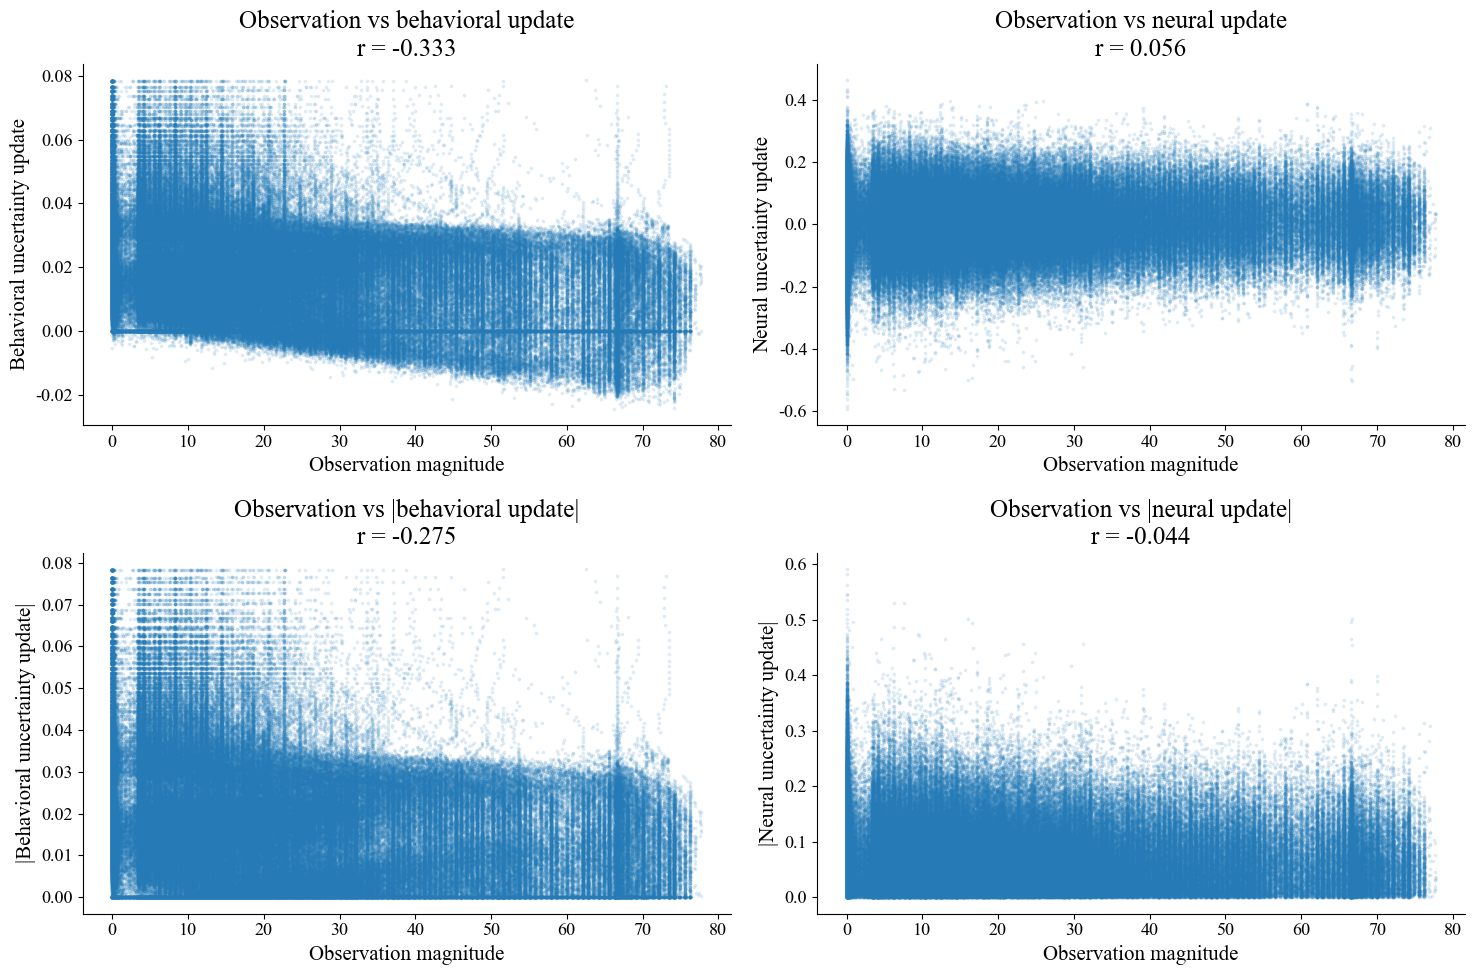

In [85]:
def analyze_observation_uncertainty_relationship(timedf, neural_uncertainty):
    """Analyze the relationship between observations and both behavioral and neural uncertainty updates"""
    print("\nAnalyzing relationship between observations and uncertainty updates...")
    
    # Import necessary libraries
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import pearsonr
    
    # Extract variables
    beh_uncertainty = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5  # std
    obs = np.abs(timedf.mw.to_numpy())  # Absolute observation values
    trial_ids = timedf.trial.to_numpy()
    
    # Calculate updates within each trial
    beh_updates = []
    neural_updates = []
    obs_values = []
    
    unique_trials = np.unique(trial_ids)
    for trial in unique_trials:
        trial_mask = trial_ids == trial
        if sum(trial_mask) < 3:  # Skip very short trials
            continue
            
        # Get trial data
        trial_beh = beh_uncertainty[trial_mask]
        trial_neural = neural_uncertainty[trial_mask]
        trial_obs = obs[trial_mask]
        
        # Calculate updates
        for t in range(1, len(trial_beh)):
            beh_updates.append(trial_beh[t] - trial_beh[t-1])
            neural_updates.append(trial_neural[t] - trial_neural[t-1])
            obs_values.append(trial_obs[t-1])  # Observation at previous timestep
    
    # Convert to arrays
    beh_updates = np.array(beh_updates)
    neural_updates = np.array(neural_updates)
    obs_values = np.array(obs_values)
    
    # Compute correlations
    beh_obs_corr, beh_obs_p = pearsonr(obs_values, beh_updates)
    neural_obs_corr, neural_obs_p = pearsonr(obs_values, neural_updates)
    
    # Also compute correlations with absolute update values
    abs_beh_obs_corr, abs_beh_obs_p = pearsonr(obs_values, np.abs(beh_updates))
    abs_neural_obs_corr, abs_neural_obs_p = pearsonr(obs_values, np.abs(neural_updates))
    
    print(f"Correlation between observation magnitude and behavioral uncertainty update: r={beh_obs_corr:.3f} (p={beh_obs_p:.3e})")
    print(f"Correlation between observation magnitude and neural uncertainty update: r={neural_obs_corr:.3f} (p={neural_obs_p:.3e})")
    print(f"Correlation between observation magnitude and |behavioral uncertainty update|: r={abs_beh_obs_corr:.3f} (p={abs_beh_obs_p:.3e})")
    print(f"Correlation between observation magnitude and |neural uncertainty update|: r={abs_neural_obs_corr:.3f} (p={abs_neural_obs_p:.3e})")
    
    # Plot results
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    plt.scatter(obs_values, beh_updates, alpha=0.1, s=3)
    plt.xlabel('Observation magnitude')
    plt.ylabel('Behavioral uncertainty update')
    plt.title(f'Observation vs behavioral update\nr = {beh_obs_corr:.3f}')
    
    plt.subplot(2, 2, 2)
    plt.scatter(obs_values, neural_updates, alpha=0.1, s=3)
    plt.xlabel('Observation magnitude')
    plt.ylabel('Neural uncertainty update')
    plt.title(f'Observation vs neural update\nr = {neural_obs_corr:.3f}')
    
    plt.subplot(2, 2, 3)
    plt.scatter(obs_values, np.abs(beh_updates), alpha=0.1, s=3)
    plt.xlabel('Observation magnitude')
    plt.ylabel('|Behavioral uncertainty update|')
    plt.title(f'Observation vs |behavioral update|\nr = {abs_beh_obs_corr:.3f}')
    
    plt.subplot(2, 2, 4)
    plt.scatter(obs_values, np.abs(neural_updates), alpha=0.1, s=3)
    plt.xlabel('Observation magnitude')
    plt.ylabel('|Neural uncertainty update|')
    plt.title(f'Observation vs |neural update|\nr = {abs_neural_obs_corr:.3f}')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'beh_updates': beh_updates,
        'neural_updates': neural_updates,
        'obs_values': obs_values,
        'beh_obs_corr': beh_obs_corr,
        'neural_obs_corr': neural_obs_corr,
        'abs_beh_obs_corr': abs_beh_obs_corr,
        'abs_neural_obs_corr': abs_neural_obs_corr
    }

update_results = analyze_observation_uncertainty_relationship(timedf, neural_uncertainty)


Analyzing direct neural patterns associated with uncertainty conditions...
Thresholds - Long trials: > 337 timesteps, Far targets: > 26.38 rad
Long trials: 381, Short trials: 1157
Error trials: 0, Success trials: 0
Far targets: 385, Near targets: 1153
Timepoints - Long trials: 130732, Short trials: 269385
Timepoints - Error trials: 0, Success trials: 0
Timepoints - Far targets: 108278, Near targets: 291839

Neural variance across dimensions:
Long trials: 0.005, Short trials: 0.006
Error trials: nan, Success trials: nan
Far targets: 0.006, Near targets: 0.005

Dimensions with consistently higher activity in uncertainty conditions: 0
Dimensions with consistently lower activity in uncertainty conditions: 0
PCA component 1: correlation with uncertainty r=0.027 (p=1.362e-59)
PCA component 2: correlation with uncertainty r=0.032 (p=2.091e-81)
PCA component 3: correlation with uncertainty r=0.052 (p=2.119e-214)
PCA component 4: correlation with uncertainty r=0.037 (p=6.883e-114)
PCA componen

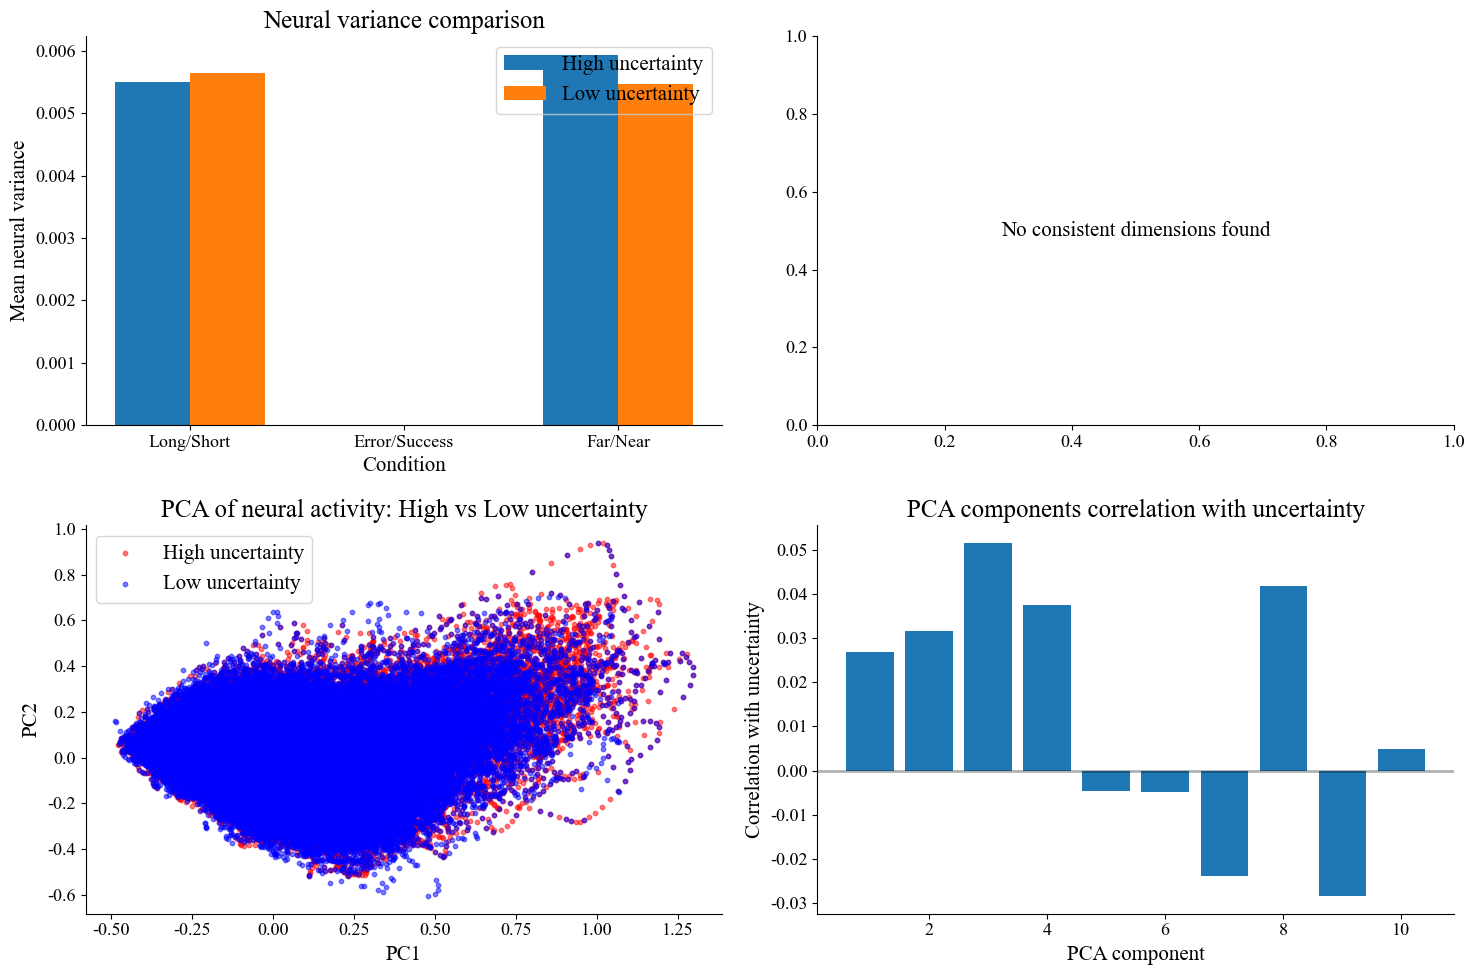

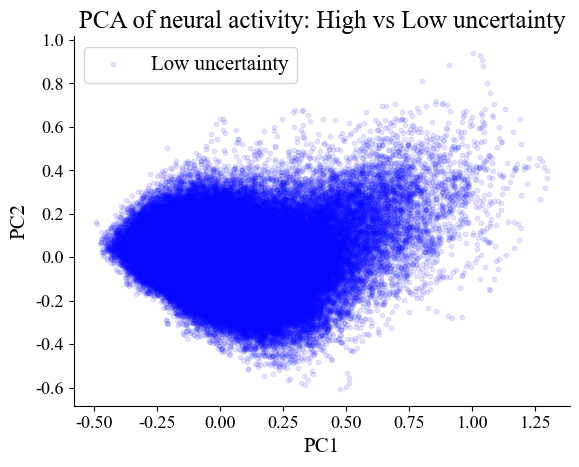

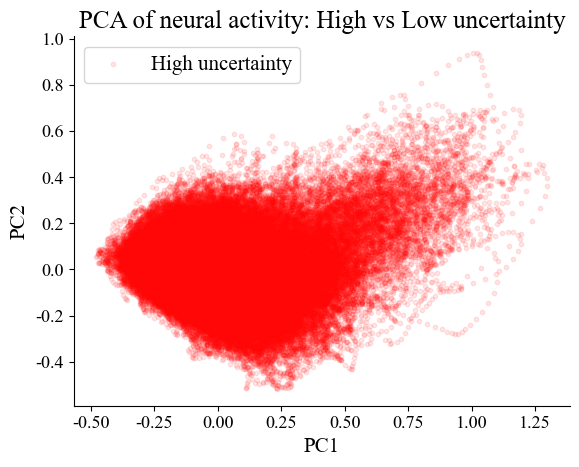

In [88]:
def analyze_direct_neural_patterns(timedf, sessdf):
    """
    Analyze neural activity directly to find patterns associated with expected uncertainty conditions
    """
    print("\nAnalyzing direct neural patterns associated with uncertainty conditions...")
    
    # Import necessary libraries
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import pearsonr, ttest_ind
    import pandas as pd
    from sklearn.decomposition import PCA
    
    # Extract variables
    neural_data = np.stack(timedf.PPC.to_numpy())
    trial_ids = timedf.trial.to_numpy()
    timer = timedf.timer.to_numpy()
    belief = timedf.belief.to_numpy()
    
    # Get trial-level metrics from sessdf
    trials = sessdf.trial.values
    trial_length = np.array([len(x) for x in sessdf.timer.values])  # Length of trials in timesteps
    error_trials = sessdf.error.values  # Error flag (1 = error, 0 = success)
    initial_target = np.array([abs(x[0]) for x in sessdf.belief_ff_hori.values])  # Initial target distance
    
    # Set thresholds for categorizing trials
    long_trial_threshold = np.percentile(trial_length, 75)
    far_target_threshold = np.percentile(initial_target, 75)
    
    print(f"Thresholds - Long trials: > {long_trial_threshold:.0f} timesteps, Far targets: > {far_target_threshold:.2f} rad")
    
    # Create masks for trial categories
    long_trials = np.where(trial_length > long_trial_threshold)[0]
    short_trials = np.where(trial_length <= long_trial_threshold)[0]
    error_trial_idx = np.where(error_trials == 1)[0]
    success_trial_idx = np.where(error_trials == 0)[0]
    far_targets = np.where(initial_target > far_target_threshold)[0]
    near_targets = np.where(initial_target <= far_target_threshold)[0]
    
    print(f"Long trials: {len(long_trials)}, Short trials: {len(short_trials)}")
    print(f"Error trials: {len(error_trial_idx)}, Success trials: {len(success_trial_idx)}")
    print(f"Far targets: {len(far_targets)}, Near targets: {len(near_targets)}")
    
    # Get trial indices in timedf for each category
    def get_timedf_indices(trial_indices):
        mask = np.zeros(len(trial_ids), dtype=bool)
        for idx in trial_indices:
            if idx < len(trials):
                mask |= (trial_ids == trials[idx])
        return mask
    
    long_trials_mask = get_timedf_indices(long_trials)
    short_trials_mask = get_timedf_indices(short_trials)
    error_trials_mask = get_timedf_indices(error_trial_idx)
    success_trials_mask = get_timedf_indices(success_trial_idx)
    far_targets_mask = get_timedf_indices(far_targets)
    near_targets_mask = get_timedf_indices(near_targets)
    
    print(f"Timepoints - Long trials: {sum(long_trials_mask)}, Short trials: {sum(short_trials_mask)}")
    print(f"Timepoints - Error trials: {sum(error_trials_mask)}, Success trials: {sum(success_trials_mask)}")
    print(f"Timepoints - Far targets: {sum(far_targets_mask)}, Near targets: {sum(near_targets_mask)}")
    
    # Analyze neural activity patterns for each category
    # 1. Compute average activity per dimension for each category
    long_neural_mean = np.mean(neural_data[long_trials_mask], axis=0)
    short_neural_mean = np.mean(neural_data[short_trials_mask], axis=0)
    error_neural_mean = np.mean(neural_data[error_trials_mask], axis=0)
    success_neural_mean = np.mean(neural_data[success_trials_mask], axis=0)
    far_neural_mean = np.mean(neural_data[far_targets_mask], axis=0)
    near_neural_mean = np.mean(neural_data[near_targets_mask], axis=0)
    
    # 2. Compute variance of activity across dimensions for each category
    long_neural_var = np.var(neural_data[long_trials_mask], axis=1).mean()
    short_neural_var = np.var(neural_data[short_trials_mask], axis=1).mean()
    error_neural_var = np.var(neural_data[error_trials_mask], axis=1).mean()
    success_neural_var = np.var(neural_data[success_trials_mask], axis=1).mean()
    far_neural_var = np.var(neural_data[far_targets_mask], axis=1).mean()
    near_neural_var = np.var(neural_data[near_targets_mask], axis=1).mean()
    
    print("\nNeural variance across dimensions:")
    print(f"Long trials: {long_neural_var:.3f}, Short trials: {short_neural_var:.3f}")
    print(f"Error trials: {error_neural_var:.3f}, Success trials: {success_neural_var:.3f}")
    print(f"Far targets: {far_neural_var:.3f}, Near targets: {near_neural_var:.3f}")
    
    # 3. Find dimensions that show consistent differences across all uncertainty conditions
    # We expect higher activity in: long trials, error trials, and far targets
    dim_diff_long_short = long_neural_mean - short_neural_mean
    dim_diff_error_success = error_neural_mean - success_neural_mean
    dim_diff_far_near = far_neural_mean - near_neural_mean
    
    # Find dimensions where all differences have the same sign (all positive or all negative)
    all_positive = (dim_diff_long_short > 0) & (dim_diff_error_success > 0) & (dim_diff_far_near > 0)
    all_negative = (dim_diff_long_short < 0) & (dim_diff_error_success < 0) & (dim_diff_far_near < 0)
    
    consistent_dims_pos = np.where(all_positive)[0]
    consistent_dims_neg = np.where(all_negative)[0]
    
    print(f"\nDimensions with consistently higher activity in uncertainty conditions: {len(consistent_dims_pos)}")
    print(f"Dimensions with consistently lower activity in uncertainty conditions: {len(consistent_dims_neg)}")
    
    # 4. Sort dimensions by consistency strength
    if len(consistent_dims_pos) > 0:
        dim_strength_pos = np.abs(dim_diff_long_short[consistent_dims_pos]) + \
                           np.abs(dim_diff_error_success[consistent_dims_pos]) + \
                           np.abs(dim_diff_far_near[consistent_dims_pos])
        top_pos_dims = consistent_dims_pos[np.argsort(dim_strength_pos)[::-1][:5]]
        print(f"Top positive dimensions: {top_pos_dims}")
    
    if len(consistent_dims_neg) > 0:
        dim_strength_neg = np.abs(dim_diff_long_short[consistent_dims_neg]) + \
                           np.abs(dim_diff_error_success[consistent_dims_neg]) + \
                           np.abs(dim_diff_far_near[consistent_dims_neg])
        top_neg_dims = consistent_dims_neg[np.argsort(dim_strength_neg)[::-1][:5]]
        print(f"Top negative dimensions: {top_neg_dims}")
    
    # 5. Test if there's an uncertainty signature across dimensions using PCA
    # Combine neural data from high uncertainty conditions
    high_uncertainty_mask = long_trials_mask | error_trials_mask | far_targets_mask
    low_uncertainty_mask = short_trials_mask | success_trials_mask | near_targets_mask
    
    # Subsample to balance the datasets
    max_samples = min(sum(high_uncertainty_mask), sum(low_uncertainty_mask))
    high_indices = np.random.choice(np.where(high_uncertainty_mask)[0], max_samples, replace=False)
    low_indices = np.random.choice(np.where(low_uncertainty_mask)[0], max_samples, replace=False)
    
    # Combine data and create labels
    combined_data = np.vstack([neural_data[high_indices], neural_data[low_indices]])
    labels = np.hstack([np.ones(max_samples), np.zeros(max_samples)])
    
    # Apply PCA
    pca = PCA(n_components=10)
    pca_result = pca.fit_transform(combined_data)
    
    # Test if PCA components separate high vs low uncertainty
    pca_corrs = []
    for i in range(10):
        corr, p = pearsonr(pca_result[:, i], labels)
        pca_corrs.append((corr, p))
        print(f"PCA component {i+1}: correlation with uncertainty r={corr:.3f} (p={p:.3e})")
    
    # Plot results
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Neural variance comparison
    plt.subplot(2, 2, 1)
    categories = ['Long/Short', 'Error/Success', 'Far/Near']
    var_high = [long_neural_var, error_neural_var, far_neural_var]
    var_low = [short_neural_var, success_neural_var, near_neural_var]
    
    bar_width = 0.35
    x = np.arange(len(categories))
    plt.bar(x - bar_width/2, var_high, bar_width, label='High uncertainty')
    plt.bar(x + bar_width/2, var_low, bar_width, label='Low uncertainty')
    plt.xlabel('Condition')
    plt.ylabel('Mean neural variance')
    plt.title('Neural variance comparison')
    plt.xticks(x, categories)
    plt.legend()
    
    # Plot 2: Activity in top consistent dimensions
    plt.subplot(2, 2, 2)
    if len(consistent_dims_pos) > 0 or len(consistent_dims_neg) > 0:
        # Choose which dimensions to plot
        if len(consistent_dims_pos) > 0:
            plot_dims = top_pos_dims[:3] if len(top_pos_dims) >= 3 else top_pos_dims
            plot_label = 'positive'
        else:
            plot_dims = top_neg_dims[:3] if len(top_neg_dims) >= 3 else top_neg_dims
            plot_label = 'negative'
            
        for i, dim in enumerate(plot_dims):
            plt.bar(x*3 + i - 1, [dim_diff_long_short[dim], dim_diff_error_success[dim], dim_diff_far_near[dim]])
            
        plt.xlabel('Condition')
        plt.ylabel('Activity difference')
        plt.title(f'Top {plot_label} consistent dimensions')
        plt.xticks(x*3, categories)
    else:
        plt.text(0.5, 0.5, 'No consistent dimensions found', ha='center', va='center')
    
    # Plot 3: PCA separation of high vs low uncertainty
    plt.subplot(2, 2, 3)
    plt.scatter(pca_result[:max_samples, 0], pca_result[:max_samples, 1], 
                c='red', alpha=0.5, s=10, label='High uncertainty')
    plt.scatter(pca_result[max_samples:, 0], pca_result[max_samples:, 1], 
                c='blue', alpha=0.5, s=10, label='Low uncertainty')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA of neural activity: High vs Low uncertainty')
    plt.legend()
    
    # Plot 4: Correlation of PCA components with uncertainty
    plt.subplot(2, 2, 4)
    corr_values = [c[0] for c in pca_corrs]
    plt.bar(np.arange(1, 11), corr_values)
    plt.xlabel('PCA component')
    plt.ylabel('Correlation with uncertainty')
    plt.title('PCA components correlation with uncertainty')
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    


    plt.scatter(pca_result[max_samples:, 0], pca_result[max_samples:, 1], 
                c='blue', alpha=0.1, s=10, label='Low uncertainty')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA of neural activity: High vs Low uncertainty')
    plt.legend()
    plt.show()

    plt.scatter(pca_result[:max_samples, 0], pca_result[:max_samples, 1], 
                c='red', alpha=0.1, s=10, label='High uncertainty')

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA of neural activity: High vs Low uncertainty')
    plt.legend()
    plt.show()

    # Return consistent dimensions and their properties
    return {
        'consistent_dims_pos': consistent_dims_pos,
        'consistent_dims_neg': consistent_dims_neg,
        'top_pos_dims': top_pos_dims if len(consistent_dims_pos) > 0 else None,
        'top_neg_dims': top_neg_dims if len(consistent_dims_neg) > 0 else None,
        'pca_corrs': pca_corrs,
        'variance_comparison': {
            'long_short': (long_neural_var, short_neural_var),
            'error_success': (error_neural_var, success_neural_var),
            'far_near': (far_neural_var, near_neural_var)
        }
    }

neural_patterns = analyze_direct_neural_patterns(timedf, sessdf)


Analyzing direct neural patterns associated with uncertainty conditions...
Thresholds - Long trials: > 337 timesteps, Far targets: > 26.38 rad
Long trials: 381, Short trials: 1157
Error trials: 291, Success trials: 1246
Far targets: 385, Near targets: 1153
Timepoints - Long trials: 130732, Short trials: 269385
Timepoints - Error trials: 81692, Success trials: 318425
Timepoints - Far targets: 108278, Near targets: 291839

Neural variance across dimensions:
Long trials: 0.005, Short trials: 0.006
Error trials: 0.006, Success trials: 0.006
Far targets: 0.006, Near targets: 0.005

Dimensions with consistently higher activity in uncertainty conditions: 22
Dimensions with consistently lower activity in uncertainty conditions: 8
Top positive dimensions: [105  14  37  19   1]
Top negative dimensions: [  6  72  78 102  11]
PCA component 1: correlation with uncertainty r=0.026 (p=1.901e-04)
PCA component 2: correlation with uncertainty r=0.025 (p=3.594e-04)
PCA component 3: correlation with unc

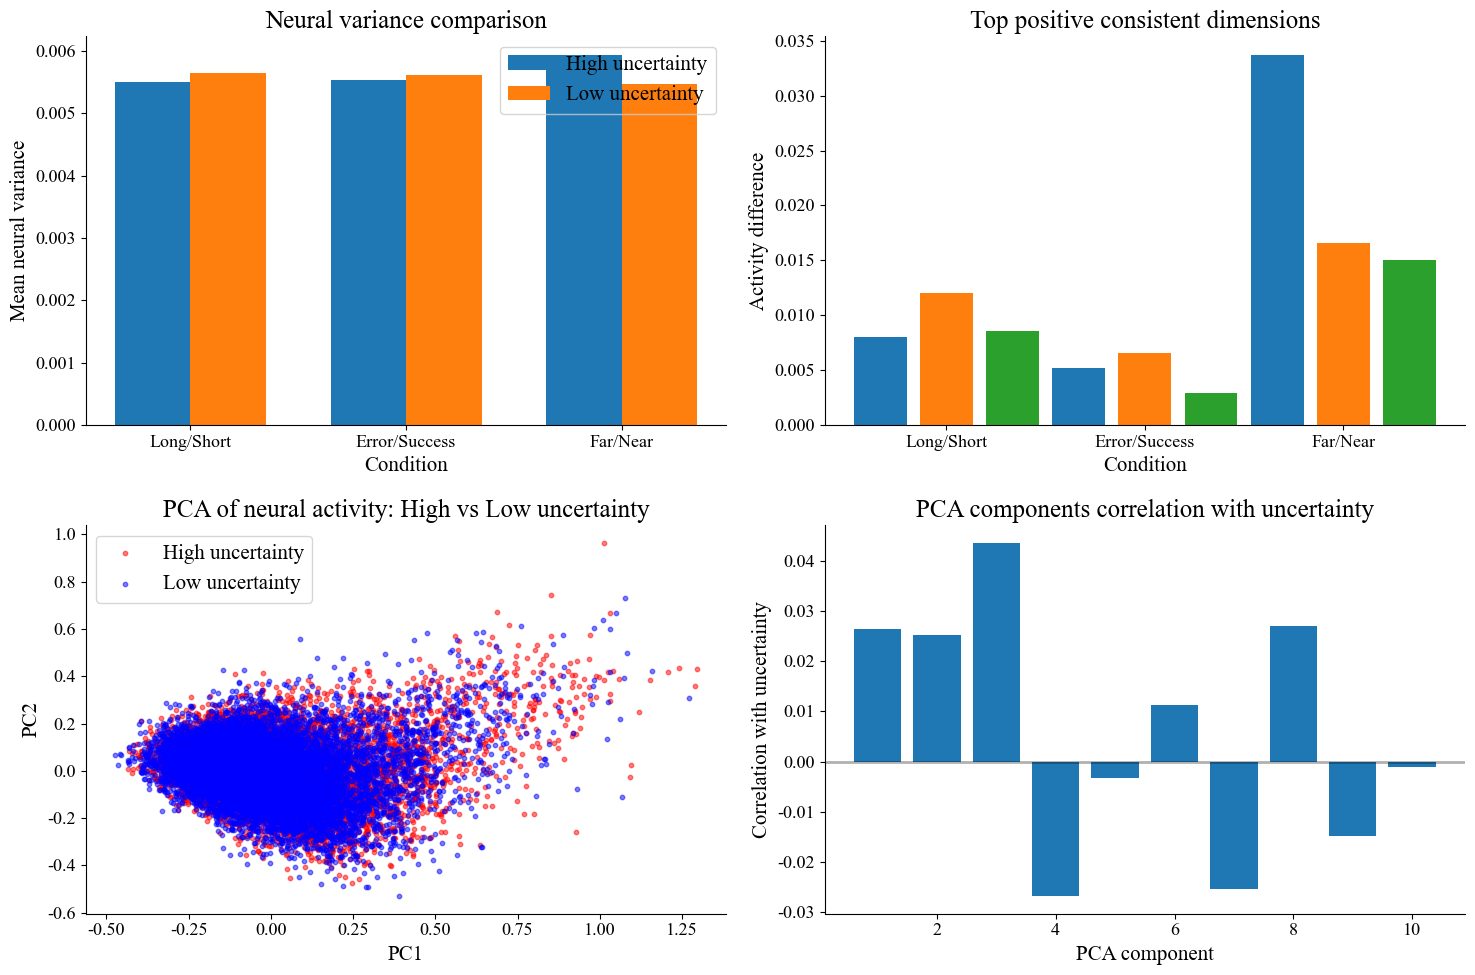

In [92]:
def analyze_direct_neural_patterns_updated(timedf, sessdf):
    """
    Analyze neural activity directly to find patterns associated with expected uncertainty conditions
    """
    print("\nAnalyzing direct neural patterns associated with uncertainty conditions...")
    
    # Import necessary libraries
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import pearsonr, ttest_ind
    import pandas as pd
    from sklearn.decomposition import PCA
    
    # Extract variables
    neural_data = np.stack(timedf.PPC.to_numpy())
    trial_ids = timedf.trial.to_numpy()
    timer = timedf.timer.to_numpy()
    belief = timedf.belief.to_numpy()
    errors = timedf.error.to_numpy()  # Use the error field from timedf
    
    # Get trial-level metrics from sessdf
    trials = sessdf.trial.values
    trial_length = np.array([len(x) for x in sessdf.timer.values])  # Length of trials in timesteps
    initial_target = np.array([abs(x[0]) for x in sessdf.belief_ff_hori.values])  # Initial target distance
    
    # Define error trials based on timedf.error > 65
    error_trial_ids = set(trial_ids[errors > 65])
    success_trial_ids = set(trial_ids) - error_trial_ids
    
    # Set thresholds for categorizing trials
    long_trial_threshold = np.percentile(trial_length, 75)
    far_target_threshold = np.percentile(initial_target, 75)
    
    print(f"Thresholds - Long trials: > {long_trial_threshold:.0f} timesteps, Far targets: > {far_target_threshold:.2f} rad")
    
    # Create masks for trial categories
    long_trials = np.where(trial_length > long_trial_threshold)[0]
    short_trials = np.where(trial_length <= long_trial_threshold)[0]
    far_targets = np.where(initial_target > far_target_threshold)[0]
    near_targets = np.where(initial_target <= far_target_threshold)[0]
    
    # Create masks directly in timedf
    long_trials_mask = np.isin(trial_ids, [trials[i] for i in long_trials if i < len(trials)])
    short_trials_mask = np.isin(trial_ids, [trials[i] for i in short_trials if i < len(trials)])
    far_targets_mask = np.isin(trial_ids, [trials[i] for i in far_targets if i < len(trials)])
    near_targets_mask = np.isin(trial_ids, [trials[i] for i in near_targets if i < len(trials)])
    error_trials_mask = np.isin(trial_ids, list(error_trial_ids))
    success_trials_mask = np.isin(trial_ids, list(success_trial_ids))
    
    print(f"Long trials: {len(long_trials)}, Short trials: {len(short_trials)}")
    print(f"Error trials: {len(error_trial_ids)}, Success trials: {len(success_trial_ids)}")
    print(f"Far targets: {len(far_targets)}, Near targets: {len(near_targets)}")
    
    print(f"Timepoints - Long trials: {sum(long_trials_mask)}, Short trials: {sum(short_trials_mask)}")
    print(f"Timepoints - Error trials: {sum(error_trials_mask)}, Success trials: {sum(success_trials_mask)}")
    print(f"Timepoints - Far targets: {sum(far_targets_mask)}, Near targets: {sum(near_targets_mask)}")
    
    # Analyze neural activity patterns for each category
    # 1. Compute average activity per dimension for each category
    long_neural_mean = np.mean(neural_data[long_trials_mask], axis=0)
    short_neural_mean = np.mean(neural_data[short_trials_mask], axis=0)
    far_neural_mean = np.mean(neural_data[far_targets_mask], axis=0)
    near_neural_mean = np.mean(neural_data[near_targets_mask], axis=0)
    
    # Only compute if there are both error and success trials
    if sum(error_trials_mask) > 0 and sum(success_trials_mask) > 0:
        error_neural_mean = np.mean(neural_data[error_trials_mask], axis=0)
        success_neural_mean = np.mean(neural_data[success_trials_mask], axis=0)
    else:
        error_neural_mean = None
        success_neural_mean = None
    
    # 2. Compute variance of activity across dimensions for each category
    long_neural_var = np.var(neural_data[long_trials_mask], axis=1).mean()
    short_neural_var = np.var(neural_data[short_trials_mask], axis=1).mean()
    far_neural_var = np.var(neural_data[far_targets_mask], axis=1).mean()
    near_neural_var = np.var(neural_data[near_targets_mask], axis=1).mean()
    
    if sum(error_trials_mask) > 0 and sum(success_trials_mask) > 0:
        error_neural_var = np.var(neural_data[error_trials_mask], axis=1).mean()
        success_neural_var = np.var(neural_data[success_trials_mask], axis=1).mean()
    else:
        error_neural_var = float('nan')
        success_neural_var = float('nan')
    
    print("\nNeural variance across dimensions:")
    print(f"Long trials: {long_neural_var:.3f}, Short trials: {short_neural_var:.3f}")
    print(f"Error trials: {error_neural_var:.3f}, Success trials: {success_neural_var:.3f}")
    print(f"Far targets: {far_neural_var:.3f}, Near targets: {near_neural_var:.3f}")
    
    # 3. Find dimensions that show consistent differences across all uncertainty conditions
    # We expect higher activity in: long trials, error trials, and far targets
    dim_diff_long_short = long_neural_mean - short_neural_mean
    dim_diff_far_near = far_neural_mean - near_neural_mean
    
    if error_neural_mean is not None and success_neural_mean is not None:
        dim_diff_error_success = error_neural_mean - success_neural_mean
        
        # Find dimensions where all differences have the same sign (all positive or all negative)
        all_positive = (dim_diff_long_short > 0) & (dim_diff_error_success > 0) & (dim_diff_far_near > 0)
        all_negative = (dim_diff_long_short < 0) & (dim_diff_error_success < 0) & (dim_diff_far_near < 0)
    else:
        # If no error trials, just look at long/short and far/near
        all_positive = (dim_diff_long_short > 0) & (dim_diff_far_near > 0)
        all_negative = (dim_diff_long_short < 0) & (dim_diff_far_near < 0)
    
    consistent_dims_pos = np.where(all_positive)[0]
    consistent_dims_neg = np.where(all_negative)[0]
    
    print(f"\nDimensions with consistently higher activity in uncertainty conditions: {len(consistent_dims_pos)}")
    print(f"Dimensions with consistently lower activity in uncertainty conditions: {len(consistent_dims_neg)}")
    
    # 4. Sort dimensions by consistency strength
    if len(consistent_dims_pos) > 0:
        if error_neural_mean is not None:
            dim_strength_pos = np.abs(dim_diff_long_short[consistent_dims_pos]) + \
                              np.abs(dim_diff_error_success[consistent_dims_pos]) + \
                              np.abs(dim_diff_far_near[consistent_dims_pos])
        else:
            dim_strength_pos = np.abs(dim_diff_long_short[consistent_dims_pos]) + \
                              np.abs(dim_diff_far_near[consistent_dims_pos])
                              
        top_pos_dims = consistent_dims_pos[np.argsort(dim_strength_pos)[::-1][:5]]
        print(f"Top positive dimensions: {top_pos_dims}")
    
    if len(consistent_dims_neg) > 0:
        if error_neural_mean is not None:
            dim_strength_neg = np.abs(dim_diff_long_short[consistent_dims_neg]) + \
                              np.abs(dim_diff_error_success[consistent_dims_neg]) + \
                              np.abs(dim_diff_far_near[consistent_dims_neg])
        else:
            dim_strength_neg = np.abs(dim_diff_long_short[consistent_dims_neg]) + \
                              np.abs(dim_diff_far_near[consistent_dims_neg])
                              
        top_neg_dims = consistent_dims_neg[np.argsort(dim_strength_neg)[::-1][:5]]
        print(f"Top negative dimensions: {top_neg_dims}")
    
    # 5. Test if there's an uncertainty signature across dimensions using PCA
    # Combine neural data from high uncertainty conditions
    high_uncertainty_mask = long_trials_mask | far_targets_mask
    low_uncertainty_mask = short_trials_mask | near_targets_mask
    
    if sum(error_trials_mask) > 0:
        high_uncertainty_mask = high_uncertainty_mask | error_trials_mask
    
    # Subsample to balance the datasets
    max_samples = min(sum(high_uncertainty_mask), sum(low_uncertainty_mask))
    if max_samples > 10000:  # Limit for computational efficiency
        max_samples = 10000
        
    high_indices = np.random.choice(np.where(high_uncertainty_mask)[0], max_samples, replace=False)
    low_indices = np.random.choice(np.where(low_uncertainty_mask)[0], max_samples, replace=False)
    
    # Combine data and create labels
    combined_data = np.vstack([neural_data[high_indices], neural_data[low_indices]])
    labels = np.hstack([np.ones(max_samples), np.zeros(max_samples)])
    
    # Apply PCA
    pca = PCA(n_components=10)
    pca_result = pca.fit_transform(combined_data)
    
    # Test if PCA components separate high vs low uncertainty
    pca_corrs = []
    for i in range(10):
        corr, p = pearsonr(pca_result[:, i], labels)
        pca_corrs.append((corr, p))
        print(f"PCA component {i+1}: correlation with uncertainty r={corr:.3f} (p={p:.3e})")
    
    # Plot results
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Neural variance comparison
    plt.subplot(2, 2, 1)
    categories = ['Long/Short', 'Error/Success', 'Far/Near']
    var_high = [long_neural_var, error_neural_var, far_neural_var]
    var_low = [short_neural_var, success_neural_var, near_neural_var]
    
    bar_width = 0.35
    x = np.arange(len(categories))
    plt.bar(x - bar_width/2, var_high, bar_width, label='High uncertainty')
    plt.bar(x + bar_width/2, var_low, bar_width, label='Low uncertainty')
    plt.xlabel('Condition')
    plt.ylabel('Mean neural variance')
    plt.title('Neural variance comparison')
    plt.xticks(x, categories)
    plt.legend()
    
    # Plot 2: Activity in top consistent dimensions
    plt.subplot(2, 2, 2)
    if len(consistent_dims_pos) > 0 or len(consistent_dims_neg) > 0:
        # Choose which dimensions to plot
        if len(consistent_dims_pos) > 0:
            plot_dims = top_pos_dims[:3] if len(top_pos_dims) >= 3 else top_pos_dims
            plot_label = 'positive'
        else:
            plot_dims = top_neg_dims[:3] if len(top_neg_dims) >= 3 else top_neg_dims
            plot_label = 'negative'
            
        for i, dim in enumerate(plot_dims):
            if error_neural_mean is not None:
                plt.bar(x*3 + i - 1, [dim_diff_long_short[dim], dim_diff_error_success[dim], dim_diff_far_near[dim]])
            else:
                plt.bar([0, 2], [dim_diff_long_short[dim], dim_diff_far_near[dim]])
                
        plt.xlabel('Condition')
        plt.ylabel('Activity difference')
        plt.title(f'Top {plot_label} consistent dimensions')
        plt.xticks(x*3, categories)
    else:
        plt.text(0.5, 0.5, 'No consistent dimensions found', ha='center', va='center')
    
    # Plot 3: PCA separation of high vs low uncertainty
    plt.subplot(2, 2, 3)
    plt.scatter(pca_result[:max_samples, 0], pca_result[:max_samples, 1], 
                c='red', alpha=0.5, s=10, label='High uncertainty')
    plt.scatter(pca_result[max_samples:, 0], pca_result[max_samples:, 1], 
                c='blue', alpha=0.5, s=10, label='Low uncertainty')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA of neural activity: High vs Low uncertainty')
    plt.legend()
    
    # Plot 4: Correlation of PCA components with uncertainty
    plt.subplot(2, 2, 4)
    corr_values = [c[0] for c in pca_corrs]
    plt.bar(np.arange(1, 11), corr_values)
    plt.xlabel('PCA component')
    plt.ylabel('Correlation with uncertainty')
    plt.title('PCA components correlation with uncertainty')
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Return consistent dimensions and their properties
    result = {
        'consistent_dims_pos': consistent_dims_pos,
        'consistent_dims_neg': consistent_dims_neg,
        'pca_corrs': pca_corrs,
        'variance_comparison': {
            'long_short': (long_neural_var, short_neural_var),
            'far_near': (far_neural_var, near_neural_var)
        }
    }
    
    if len(consistent_dims_pos) > 0:
        result['top_pos_dims'] = top_pos_dims
    
    if len(consistent_dims_neg) > 0:
        result['top_neg_dims'] = top_neg_dims
        
    if error_neural_var is not float('nan'):
        result['variance_comparison']['error_success'] = (error_neural_var, success_neural_var)
    
    return result

neural_patterns_updated = analyze_direct_neural_patterns_updated(timedf, sessdf)

# temmporal var


Analyzing temporal variance for all neurons...
Total neurons to analyze: 112
Progress: 0/112 neurons analyzed
Progress: 10/112 neurons analyzed
Progress: 20/112 neurons analyzed
Progress: 30/112 neurons analyzed
Progress: 40/112 neurons analyzed
Progress: 50/112 neurons analyzed
Progress: 60/112 neurons analyzed
Progress: 70/112 neurons analyzed
Progress: 80/112 neurons analyzed
Progress: 90/112 neurons analyzed
Progress: 100/112 neurons analyzed
Progress: 110/112 neurons analyzed

Summary of neural variance correlations:
Mean time correlation: -0.056 (std: 0.087)
Mean uncertainty correlation: -0.039 (std: 0.052)
Mean partial correlation: -0.014 (std: 0.020)

Significant correlations (p < 0.01):
Time: 98 neurons (87.5%)
Uncertainty: 89 neurons (79.5%)
Partial: 68 neurons (60.7%)

Top 5 neurons with positive time correlation:
    neuron  time_corr         time_p
3        3   0.114124  9.620436e-114
86      86   0.106049   2.134691e-98
2        2   0.104851   3.235092e-96
64      64   0

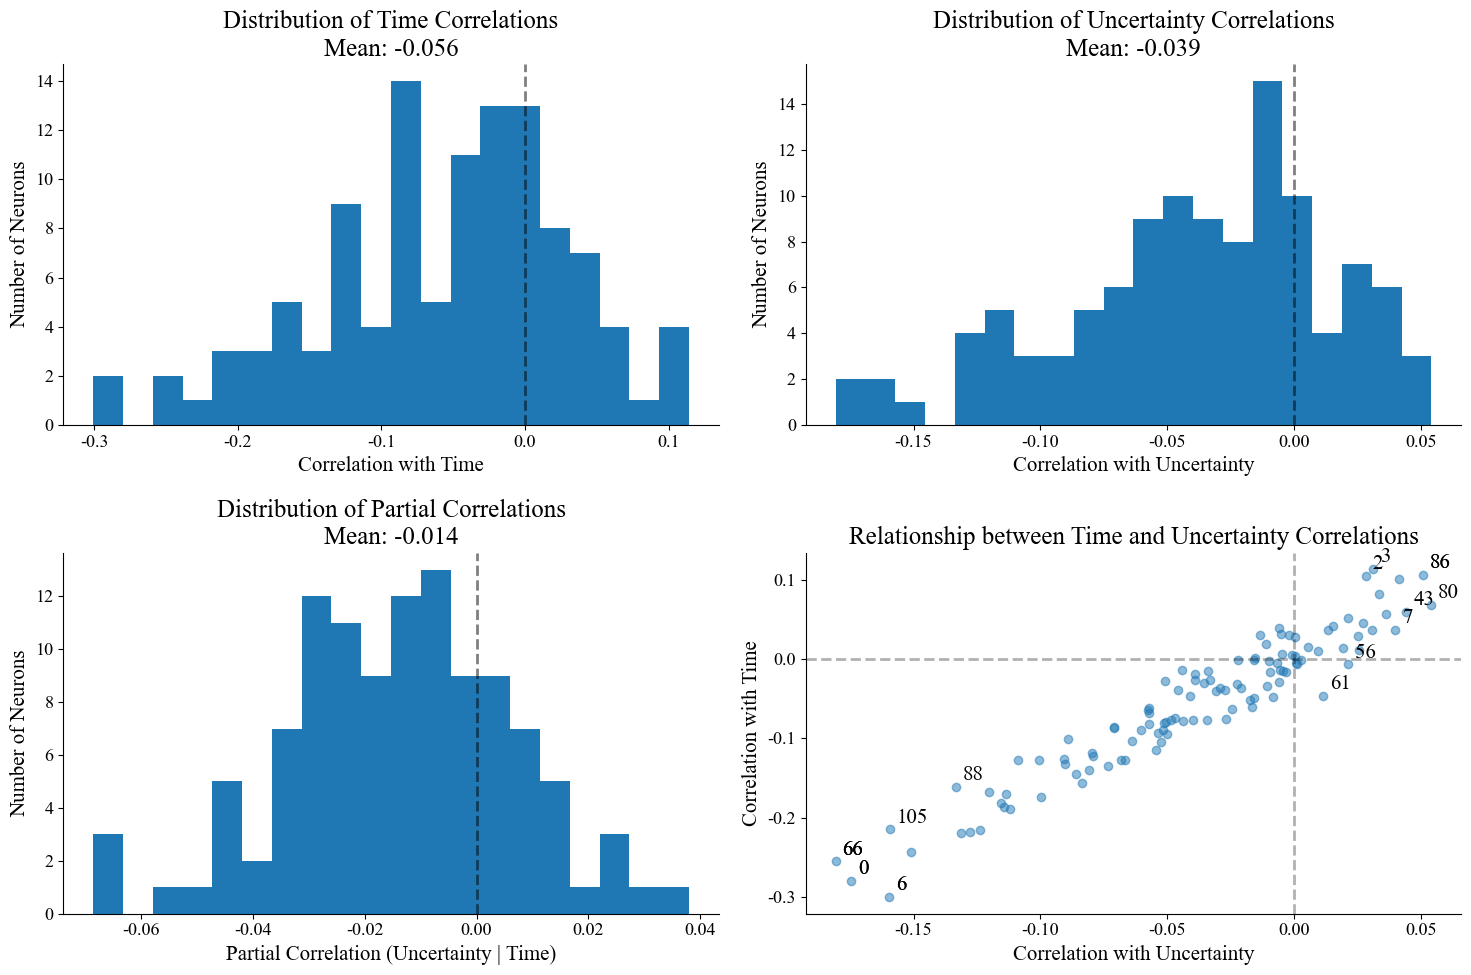

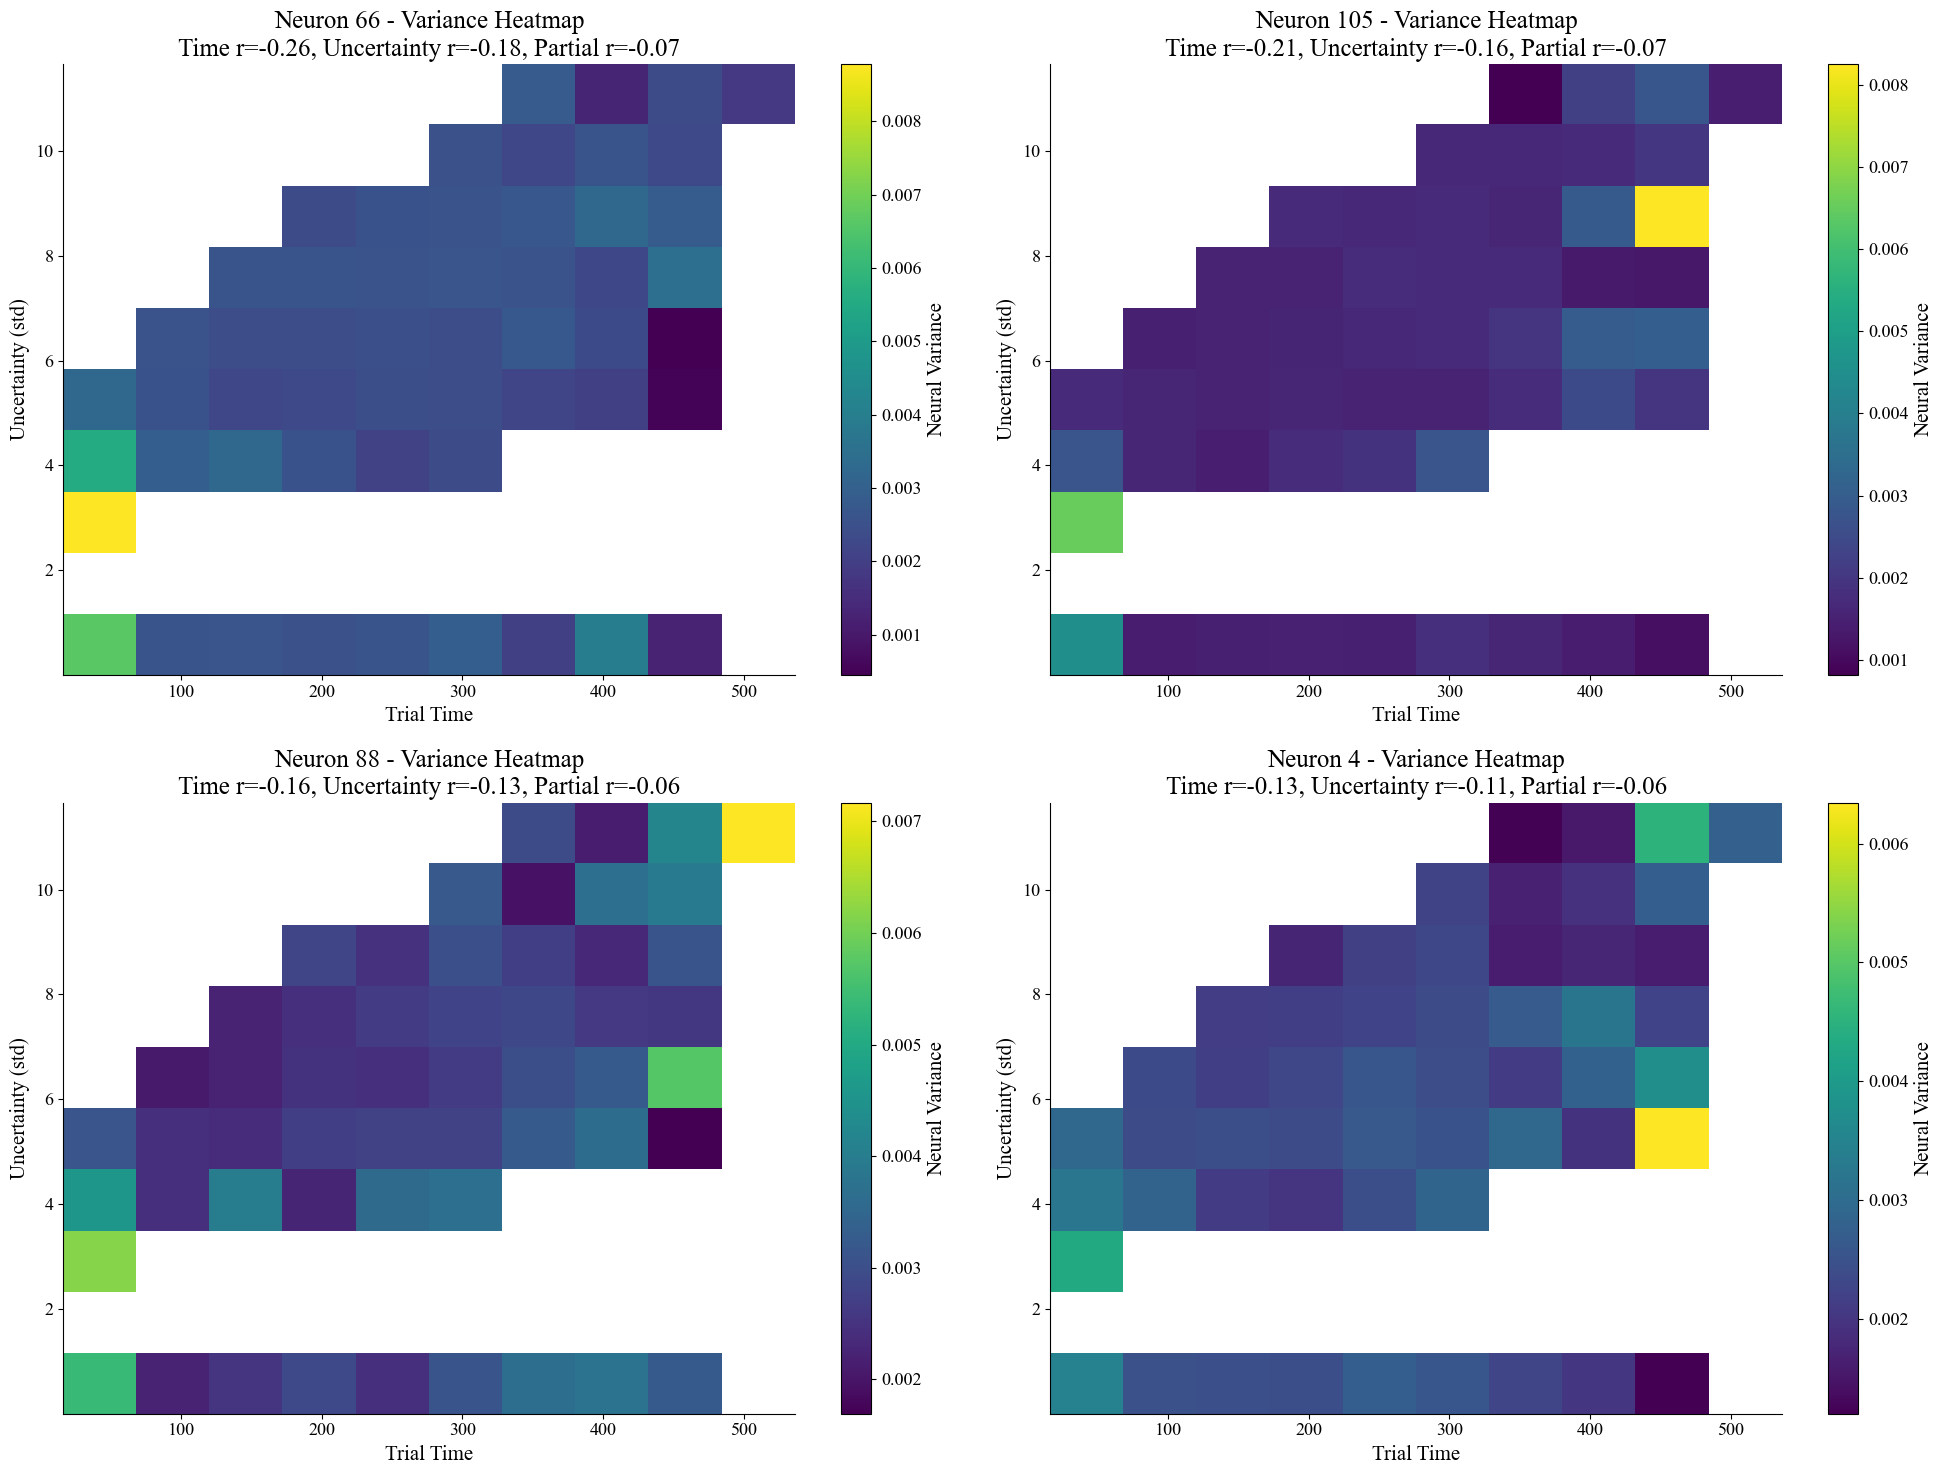

In [95]:
def analyze_all_neural_temporal_variance(timedf, sessdf):
    """
    Analyze temporal variance for all neurons using a moving window approach
    """
    print("\nAnalyzing temporal variance for all neurons...")
    
    # Import necessary libraries
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import pearsonr
    from sklearn.linear_model import LinearRegression
    import pandas as pd
    
    # Extract variables
    trialstart = 2
    uncertainty = np.concatenate([a[trialstart:] for a in sessdf.relcov.to_numpy()])[:,0,0]**0.5  # std
    trial_time = np.concatenate([a[trialstart:] for a in sessdf.timer])
    neural_data = np.concatenate([a[trialstart:] for a in sessdf.PPC.to_numpy()])
    trial_ids = np.concatenate([np.ones(len(a[trialstart:])) * i for i, a in enumerate(sessdf.timer)])
    
    # Apply mask for valid trials
    mask = (np.concatenate([a[trialstart:] for a in sessdf.triallen_t]) > 2)
    uncertainty, trial_time, neural_data, trial_ids = uncertainty[mask], trial_time[mask], neural_data[mask], trial_ids[mask]
    
    # Define moving window parameters
    window_size = 30  # Number of time points in each window
    stride = 10  # Step size for moving window
    
    # Analyze all neurons
    n_neurons = neural_data.shape[1]
    print(f"Total neurons to analyze: {n_neurons}")
    
    neuron_results = []
    
    for i_neuron in range(n_neurons):
        if i_neuron % 10 == 0:
            print(f"Progress: {i_neuron}/{n_neurons} neurons analyzed")
        
        # Create bins for this neuron's activity
        neuron_activity = neural_data[:, i_neuron]
        
        # Calculate moving window variance
        window_times = []
        window_variances = []
        window_uncertainties = []
        
        # Process each trial separately to avoid window spanning multiple trials
        unique_trials = np.unique(trial_ids)
        
        for trial in unique_trials:
            trial_mask = trial_ids == trial
            trial_neural = neuron_activity[trial_mask]
            trial_timer = trial_time[trial_mask]
            trial_uncertainty = uncertainty[trial_mask]
            
            if len(trial_neural) < window_size:
                continue
                
            # Apply moving window
            for start_idx in range(0, len(trial_neural) - window_size + 1, stride):
                end_idx = start_idx + window_size
                window_neural = trial_neural[start_idx:end_idx]
                
                # Calculate variance in this window
                window_variance = np.var(window_neural)
                window_time = np.mean(trial_timer[start_idx:end_idx])
                window_uncertainty = np.mean(trial_uncertainty[start_idx:end_idx])
                
                window_times.append(window_time)
                window_variances.append(window_variance)
                window_uncertainties.append(window_uncertainty)
        
        # Convert to arrays
        window_times = np.array(window_times)
        window_variances = np.array(window_variances)
        window_uncertainties = np.array(window_uncertainties)
        
        # Skip if not enough data points
        if len(window_times) < 10:
            continue
        
        # Calculate correlations
        time_corr, time_p = pearsonr(window_times, window_variances)
        uncertainty_corr, uncertainty_p = pearsonr(window_uncertainties, window_variances)
        
        # Calculate partial correlation (uncertainty controlling for time)
        # Use regression approach
        X_time = window_times.reshape(-1, 1)
        residuals_uncertainty = window_uncertainties - LinearRegression().fit(X_time, window_uncertainties).predict(X_time)
        residuals_variance = window_variances - LinearRegression().fit(X_time, window_variances).predict(X_time)
        partial_corr, partial_p = pearsonr(residuals_uncertainty, residuals_variance)
        
        # Store results
        neuron_results.append({
            'neuron': i_neuron,
            'time_corr': time_corr,
            'time_p': time_p,
            'uncertainty_corr': uncertainty_corr,
            'uncertainty_p': uncertainty_p,
            'partial_corr': partial_corr,
            'partial_p': partial_p
        })
    
    # Convert to DataFrame for easier analysis
    results_df = pd.DataFrame(neuron_results)
    
    # Print summary statistics
    print("\nSummary of neural variance correlations:")
    print(f"Mean time correlation: {results_df['time_corr'].mean():.3f} (std: {results_df['time_corr'].std():.3f})")
    print(f"Mean uncertainty correlation: {results_df['uncertainty_corr'].mean():.3f} (std: {results_df['uncertainty_corr'].std():.3f})")
    print(f"Mean partial correlation: {results_df['partial_corr'].mean():.3f} (std: {results_df['partial_corr'].std():.3f})")
    
    # Count significant correlations
    alpha = 0.01
    sig_time = (results_df['time_p'] < alpha).sum()
    sig_uncertainty = (results_df['uncertainty_p'] < alpha).sum()
    sig_partial = (results_df['partial_p'] < alpha).sum()
    
    print(f"\nSignificant correlations (p < {alpha}):")
    print(f"Time: {sig_time} neurons ({sig_time/len(results_df)*100:.1f}%)")
    print(f"Uncertainty: {sig_uncertainty} neurons ({sig_uncertainty/len(results_df)*100:.1f}%)")
    print(f"Partial: {sig_partial} neurons ({sig_partial/len(results_df)*100:.1f}%)")
    
    # Find neurons with strongest correlations
    top_time_pos = results_df.loc[results_df['time_corr'].nlargest(5).index]
    top_time_neg = results_df.loc[results_df['time_corr'].nsmallest(5).index]
    top_uncertainty_pos = results_df.loc[results_df['uncertainty_corr'].nlargest(5).index]
    top_uncertainty_neg = results_df.loc[results_df['uncertainty_corr'].nsmallest(5).index]
    top_partial_pos = results_df.loc[results_df['partial_corr'].nlargest(5).index]
    top_partial_neg = results_df.loc[results_df['partial_corr'].nsmallest(5).index]
    
    print("\nTop 5 neurons with positive time correlation:")
    print(top_time_pos[['neuron', 'time_corr', 'time_p']])
    
    print("\nTop 5 neurons with negative time correlation:")
    print(top_time_neg[['neuron', 'time_corr', 'time_p']])
    
    print("\nTop 5 neurons with positive uncertainty correlation:")
    print(top_uncertainty_pos[['neuron', 'uncertainty_corr', 'uncertainty_p']])
    
    print("\nTop 5 neurons with negative uncertainty correlation:")
    print(top_uncertainty_neg[['neuron', 'uncertainty_corr', 'uncertainty_p']])
    
    print("\nTop 5 neurons with positive partial correlation (uncertainty controlling for time):")
    print(top_partial_pos[['neuron', 'partial_corr', 'partial_p']])
    
    print("\nTop 5 neurons with negative partial correlation (uncertainty controlling for time):")
    print(top_partial_neg[['neuron', 'partial_corr', 'partial_p']])
    
    # Create plots
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Distribution of time correlations
    plt.subplot(2, 2, 1)
    plt.hist(results_df['time_corr'], bins=20)
    plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
    plt.xlabel('Correlation with Time')
    plt.ylabel('Number of Neurons')
    plt.title(f'Distribution of Time Correlations\nMean: {results_df["time_corr"].mean():.3f}')
    
    # Plot 2: Distribution of uncertainty correlations
    plt.subplot(2, 2, 2)
    plt.hist(results_df['uncertainty_corr'], bins=20)
    plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
    plt.xlabel('Correlation with Uncertainty')
    plt.ylabel('Number of Neurons')
    plt.title(f'Distribution of Uncertainty Correlations\nMean: {results_df["uncertainty_corr"].mean():.3f}')
    
    # Plot 3: Distribution of partial correlations
    plt.subplot(2, 2, 3)
    plt.hist(results_df['partial_corr'], bins=20)
    plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
    plt.xlabel('Partial Correlation (Uncertainty | Time)')
    plt.ylabel('Number of Neurons')
    plt.title(f'Distribution of Partial Correlations\nMean: {results_df["partial_corr"].mean():.3f}')
    
    # Plot 4: Scatter plot of time vs uncertainty correlations
    plt.subplot(2, 2, 4)
    plt.scatter(results_df['uncertainty_corr'], results_df['time_corr'], alpha=0.5)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    plt.xlabel('Correlation with Uncertainty')
    plt.ylabel('Correlation with Time')
    plt.title('Relationship between Time and Uncertainty Correlations')
    
    # Label some interesting neurons
    for category, neurons in [
        ("Top Time+", top_time_pos['neuron'].iloc[:3]),
        ("Top Time-", top_time_neg['neuron'].iloc[:3]),
        ("Top Uncert+", top_uncertainty_pos['neuron'].iloc[:3]),
        ("Top Uncert-", top_uncertainty_neg['neuron'].iloc[:3]),
        ("Top Partial+", top_partial_pos['neuron'].iloc[:3]),
        ("Top Partial-", top_partial_neg['neuron'].iloc[:3])
    ]:
        for n in neurons:
            idx = results_df[results_df['neuron'] == n].index[0]
            plt.annotate(str(int(n)), 
                        (results_df.iloc[idx]['uncertainty_corr'], results_df.iloc[idx]['time_corr']),
                        xytext=(5, 5), textcoords='offset points')
    
    plt.tight_layout()
    plt.show()
    
    # Plot a second figure with detailed analysis of top neurons
    # Let's analyze the top neurons with strongest partial correlation in detail
    
    # Get top 10 neurons by absolute partial correlation
    top_partial_abs = results_df.iloc[np.abs(results_df['partial_corr']).nlargest(10).index]
    
    # Recalculate details for these neurons
    detailed_neurons = []
    
    for _, row in top_partial_abs.iterrows():
        i_neuron = int(row['neuron'])
        
        # Extract this neuron's activity
        neuron_activity = neural_data[:, i_neuron]
        
        # Calculate moving window variance
        window_times = []
        window_variances = []
        window_uncertainties = []
        
        # Process each trial
        unique_trials = np.unique(trial_ids)
        
        for trial in unique_trials:
            trial_mask = trial_ids == trial
            trial_neural = neuron_activity[trial_mask]
            trial_timer = trial_time[trial_mask]
            trial_uncertainty = uncertainty[trial_mask]
            
            if len(trial_neural) < window_size:
                continue
                
            # Apply moving window
            for start_idx in range(0, len(trial_neural) - window_size + 1, stride):
                end_idx = start_idx + window_size
                window_neural = trial_neural[start_idx:end_idx]
                
                # Calculate variance in this window
                window_variance = np.var(window_neural)
                window_time = np.mean(trial_timer[start_idx:end_idx])
                window_uncertainty = np.mean(trial_uncertainty[start_idx:end_idx])
                
                window_times.append(window_time)
                window_variances.append(window_variance)
                window_uncertainties.append(window_uncertainty)
        
        # Convert to arrays
        window_times = np.array(window_times)
        window_variances = np.array(window_variances)
        window_uncertainties = np.array(window_uncertainties)
        
        detailed_neurons.append({
            'neuron': i_neuron,
            'window_times': window_times,
            'window_variances': window_variances,
            'window_uncertainties': window_uncertainties,
            'time_corr': row['time_corr'],
            'uncertainty_corr': row['uncertainty_corr'],
            'partial_corr': row['partial_corr']
        })
    
    # Create a 2D heatmap figure for each of the top 4 neurons
    plt.figure(figsize=(20, 15))
    
    for i, neuron_data in enumerate(detailed_neurons[:4]):
        # Create 2D grid for heatmap
        n_bins_time = 10
        n_bins_uncertainty = 10
        bins_time = np.linspace(min(neuron_data['window_times']), max(neuron_data['window_times']), n_bins_time+1)
        bins_uncertainty = np.linspace(min(neuron_data['window_uncertainties']), max(neuron_data['window_uncertainties']), n_bins_uncertainty+1)
        
        grid = np.zeros((n_bins_time, n_bins_uncertainty))
        counts = np.zeros((n_bins_time, n_bins_uncertainty))
        
        for t, u, v in zip(neuron_data['window_times'], neuron_data['window_uncertainties'], neuron_data['window_variances']):
            t_bin = np.digitize(t, bins_time) - 1
            u_bin = np.digitize(u, bins_uncertainty) - 1
            
            if t_bin >= 0 and t_bin < n_bins_time and u_bin >= 0 and u_bin < n_bins_uncertainty:
                grid[t_bin, u_bin] += v
                counts[t_bin, u_bin] += 1
        
        # Average the values
        mask = counts > 0
        grid[mask] = grid[mask] / counts[mask]
        grid[~mask] = np.nan
        
        # Plot heatmap
        plt.subplot(2, 2, i+1)
        im = plt.imshow(grid.T, origin='lower', aspect='auto', extent=[min(neuron_data['window_times']), 
                                                                       max(neuron_data['window_times']), 
                                                                       min(neuron_data['window_uncertainties']), 
                                                                       max(neuron_data['window_uncertainties'])], 
                        cmap='viridis')
        plt.colorbar(im, label='Neural Variance')
        plt.xlabel('Trial Time')
        plt.ylabel('Uncertainty (std)')
        
        neuron_id = neuron_data['neuron']
        time_corr = neuron_data['time_corr']
        uncert_corr = neuron_data['uncertainty_corr']
        partial_corr = neuron_data['partial_corr']
        
        plt.title(f'Neuron {neuron_id} - Variance Heatmap\n' +
                 f'Time r={time_corr:.2f}, Uncertainty r={uncert_corr:.2f}, Partial r={partial_corr:.2f}')
    
    plt.tight_layout()
    plt.show()
    
    return results_df

all_neurons_results = analyze_all_neural_temporal_variance(timedf, sessdf)


Analyzing temporal variance for all neurons...
Total neurons to analyze: 112
Progress: 0/112 neurons analyzed
Progress: 10/112 neurons analyzed
Progress: 20/112 neurons analyzed
Progress: 30/112 neurons analyzed
Progress: 40/112 neurons analyzed
Progress: 50/112 neurons analyzed
Progress: 60/112 neurons analyzed
Progress: 70/112 neurons analyzed
Progress: 80/112 neurons analyzed
Progress: 90/112 neurons analyzed
Progress: 100/112 neurons analyzed
Progress: 110/112 neurons analyzed

Summary of neural variance correlations:
Mean time correlation: -0.056 (std: 0.087)
Mean uncertainty correlation: -0.045 (std: 0.063)
Mean partial correlation: -0.013 (std: 0.021)

Significant correlations (p < 0.01):
Time: 98 neurons (87.5%)
Uncertainty: 92 neurons (82.1%)
Partial: 67 neurons (59.8%)

Top 5 neurons with positive time correlation:
    neuron  time_corr         time_p
3        3   0.114124  9.620436e-114
86      86   0.106049   2.134691e-98
2        2   0.104851   3.235092e-96
64      64   0

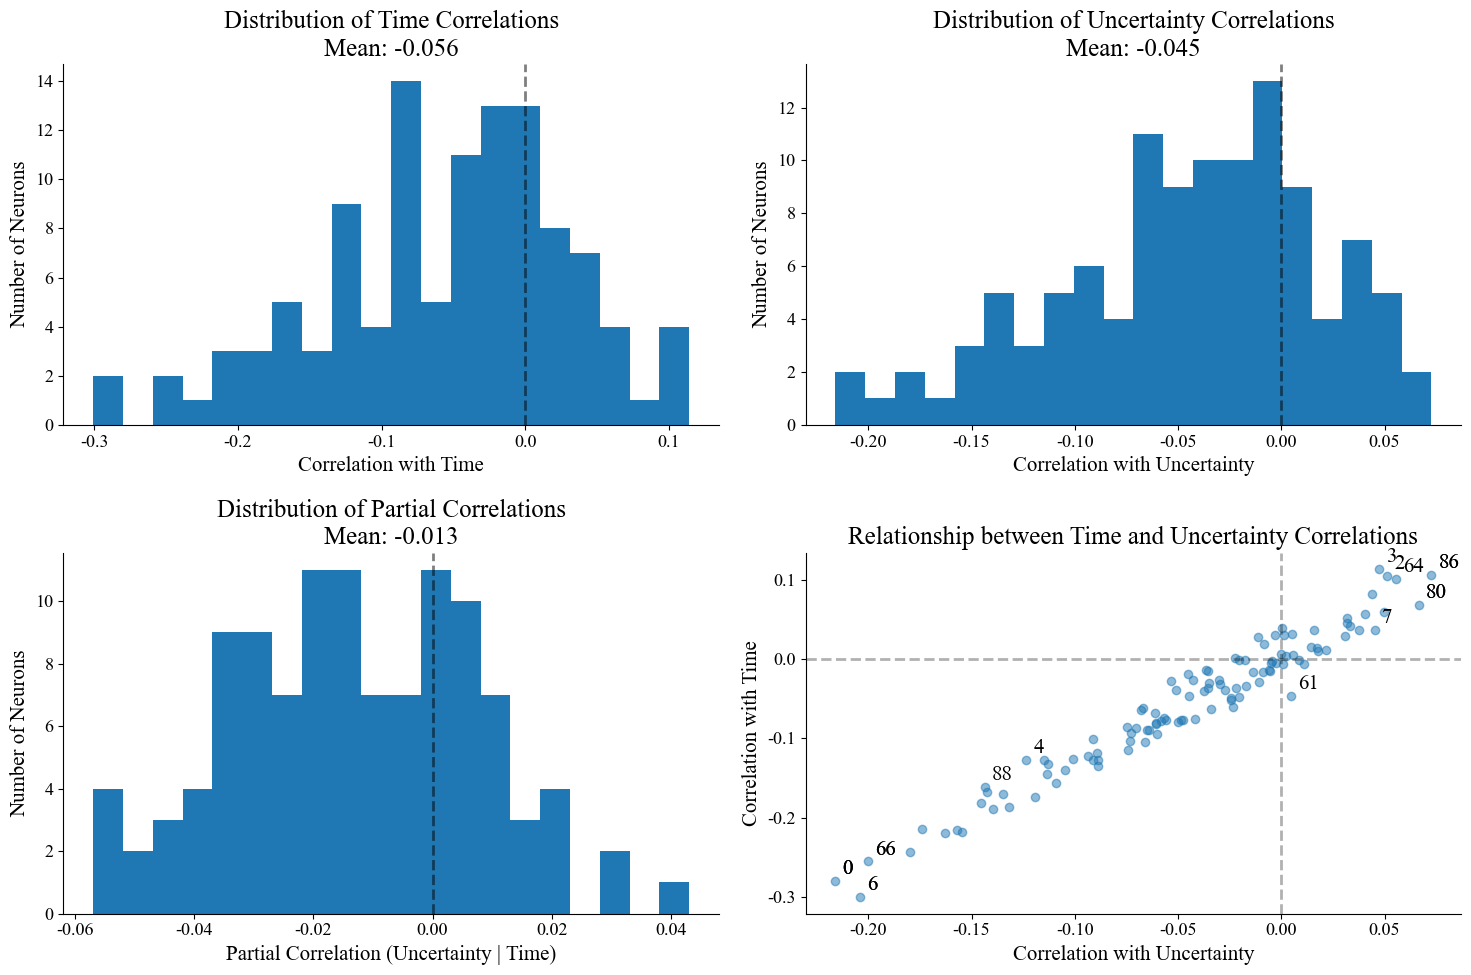

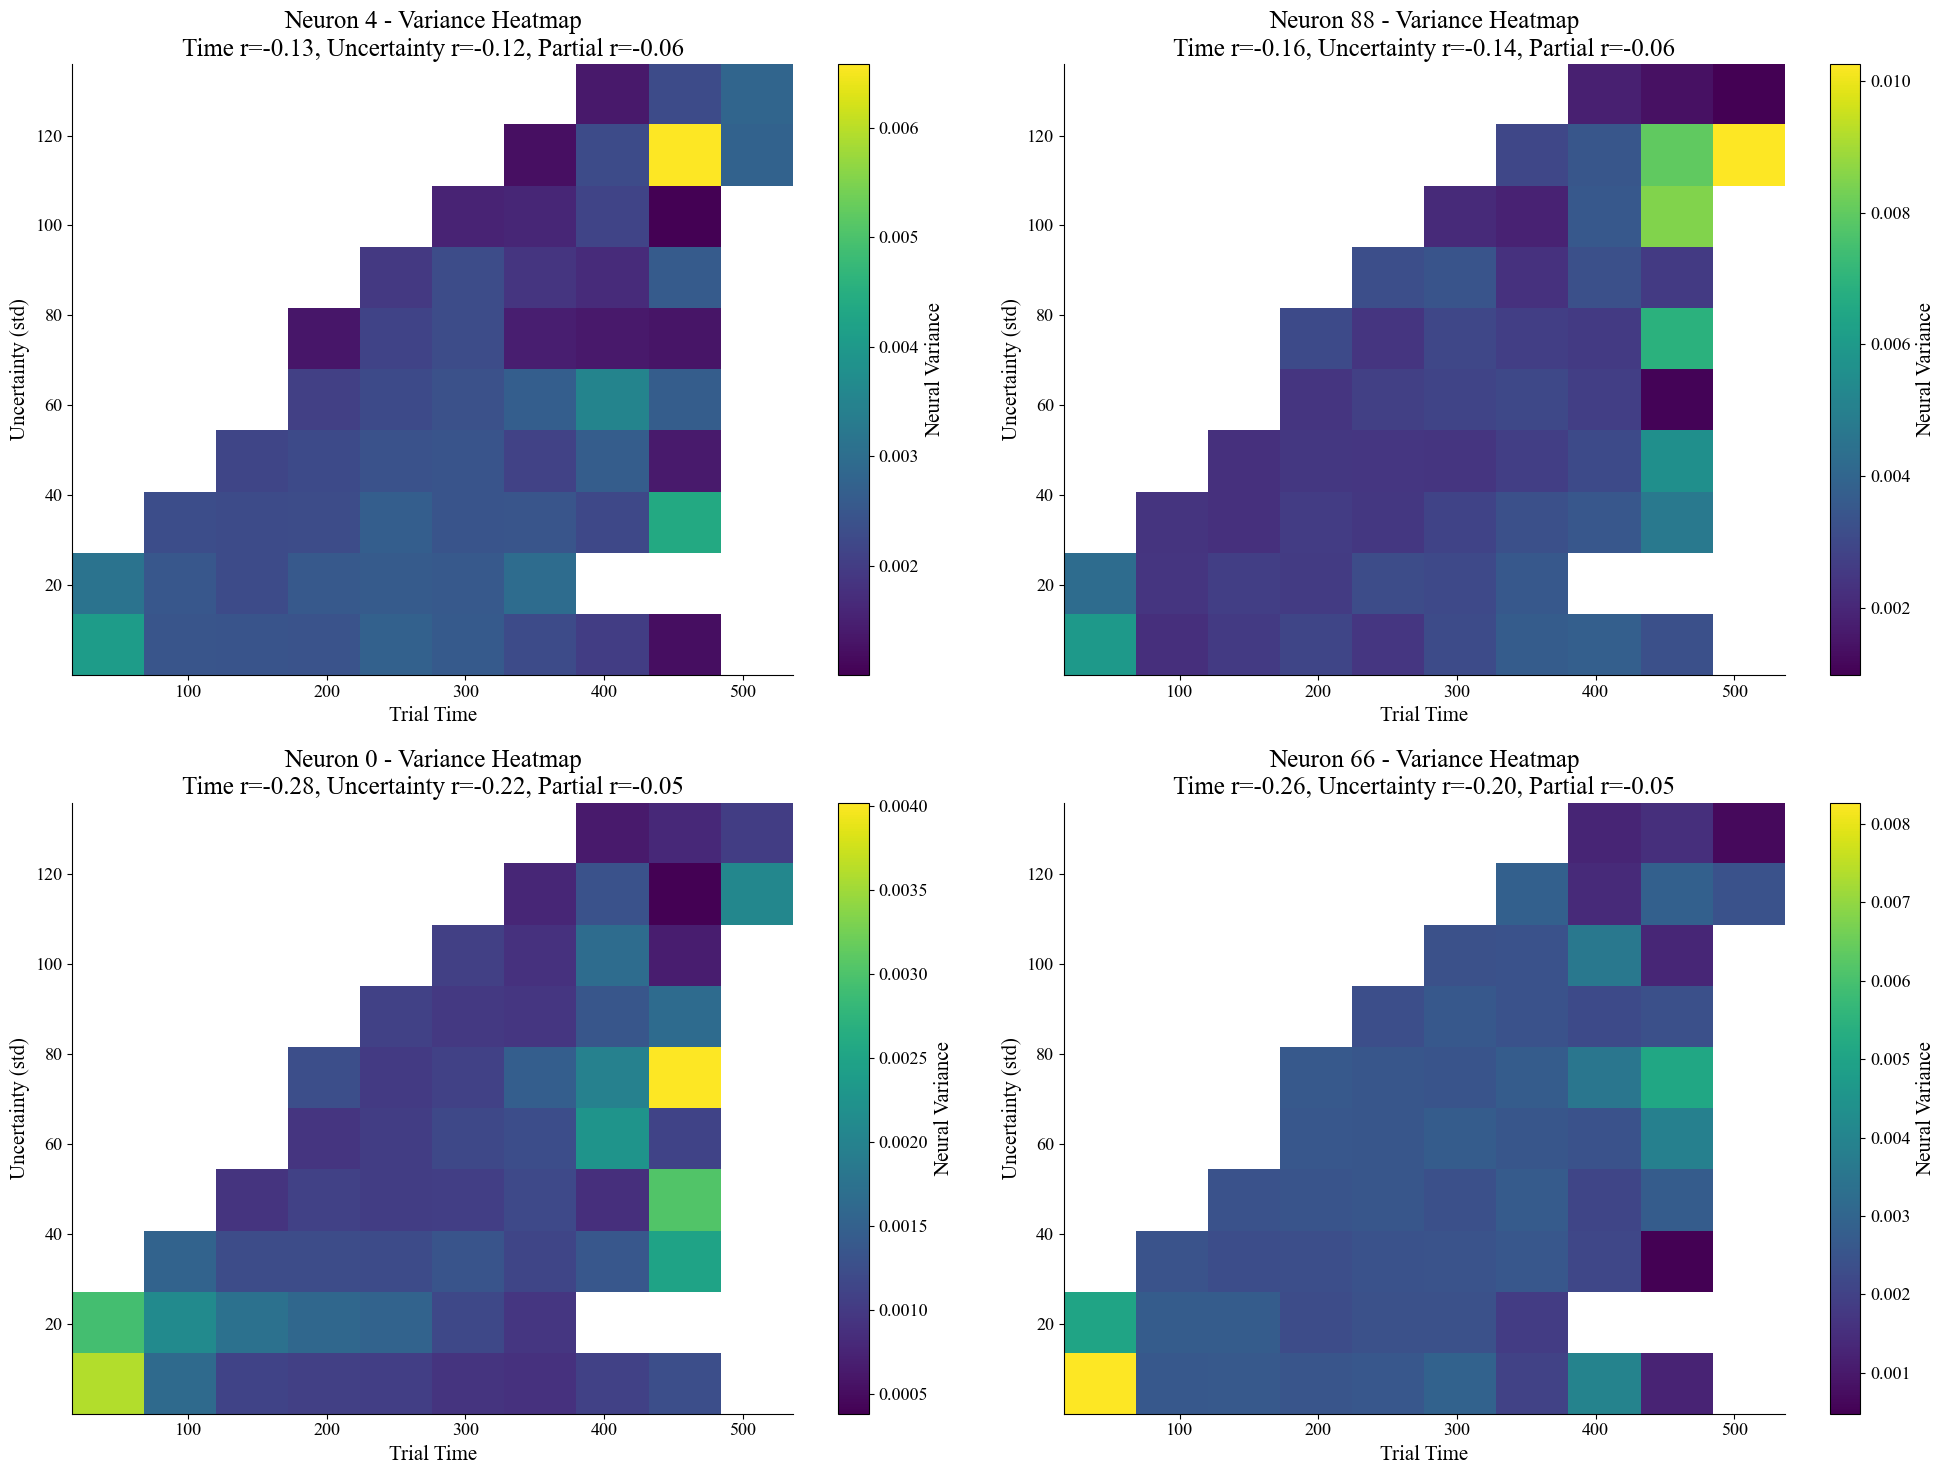

In [96]:
def analyze_all_neural_temporal_variance(timedf, sessdf):
    """
    Analyze temporal variance for all neurons using a moving window approach
    """
    print("\nAnalyzing temporal variance for all neurons...")
    
    # Import necessary libraries
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import pearsonr
    from sklearn.linear_model import LinearRegression
    import pandas as pd
    
    # Extract variables
    trialstart = 2
    uncertainty = np.concatenate([a[trialstart:] for a in sessdf.relcov.to_numpy()])[:,0,0]
    trial_time = np.concatenate([a[trialstart:] for a in sessdf.timer])
    neural_data = np.concatenate([a[trialstart:] for a in sessdf.PPC.to_numpy()])
    trial_ids = np.concatenate([np.ones(len(a[trialstart:])) * i for i, a in enumerate(sessdf.timer)])
    
    # Apply mask for valid trials
    mask = (np.concatenate([a[trialstart:] for a in sessdf.triallen_t]) > 2)
    uncertainty, trial_time, neural_data, trial_ids = uncertainty[mask], trial_time[mask], neural_data[mask], trial_ids[mask]
    
    # Define moving window parameters
    window_size = 30  # Number of time points in each window
    stride = 10  # Step size for moving window
    
    # Analyze all neurons
    n_neurons = neural_data.shape[1]
    print(f"Total neurons to analyze: {n_neurons}")
    
    neuron_results = []
    
    for i_neuron in range(n_neurons):
        if i_neuron % 10 == 0:
            print(f"Progress: {i_neuron}/{n_neurons} neurons analyzed")
        
        # Create bins for this neuron's activity
        neuron_activity = neural_data[:, i_neuron]
        
        # Calculate moving window variance
        window_times = []
        window_variances = []
        window_uncertainties = []
        
        # Process each trial separately to avoid window spanning multiple trials
        unique_trials = np.unique(trial_ids)
        
        for trial in unique_trials:
            trial_mask = trial_ids == trial
            trial_neural = neuron_activity[trial_mask]
            trial_timer = trial_time[trial_mask]
            trial_uncertainty = uncertainty[trial_mask]
            
            if len(trial_neural) < window_size:
                continue
                
            # Apply moving window
            for start_idx in range(0, len(trial_neural) - window_size + 1, stride):
                end_idx = start_idx + window_size
                window_neural = trial_neural[start_idx:end_idx]
                
                # Calculate variance in this window
                window_variance = np.var(window_neural)
                window_time = np.mean(trial_timer[start_idx:end_idx])
                window_uncertainty = np.mean(trial_uncertainty[start_idx:end_idx])
                
                window_times.append(window_time)
                window_variances.append(window_variance)
                window_uncertainties.append(window_uncertainty)
        
        # Convert to arrays
        window_times = np.array(window_times)
        window_variances = np.array(window_variances)
        window_uncertainties = np.array(window_uncertainties)
        
        # Skip if not enough data points
        if len(window_times) < 10:
            continue
        
        # Calculate correlations
        time_corr, time_p = pearsonr(window_times, window_variances)
        uncertainty_corr, uncertainty_p = pearsonr(window_uncertainties, window_variances)
        
        # Calculate partial correlation (uncertainty controlling for time)
        # Use regression approach
        X_time = window_times.reshape(-1, 1)
        residuals_uncertainty = window_uncertainties - LinearRegression().fit(X_time, window_uncertainties).predict(X_time)
        residuals_variance = window_variances - LinearRegression().fit(X_time, window_variances).predict(X_time)
        partial_corr, partial_p = pearsonr(residuals_uncertainty, residuals_variance)
        
        # Store results
        neuron_results.append({
            'neuron': i_neuron,
            'time_corr': time_corr,
            'time_p': time_p,
            'uncertainty_corr': uncertainty_corr,
            'uncertainty_p': uncertainty_p,
            'partial_corr': partial_corr,
            'partial_p': partial_p
        })
    
    # Convert to DataFrame for easier analysis
    results_df = pd.DataFrame(neuron_results)
    
    # Print summary statistics
    print("\nSummary of neural variance correlations:")
    print(f"Mean time correlation: {results_df['time_corr'].mean():.3f} (std: {results_df['time_corr'].std():.3f})")
    print(f"Mean uncertainty correlation: {results_df['uncertainty_corr'].mean():.3f} (std: {results_df['uncertainty_corr'].std():.3f})")
    print(f"Mean partial correlation: {results_df['partial_corr'].mean():.3f} (std: {results_df['partial_corr'].std():.3f})")
    
    # Count significant correlations
    alpha = 0.01
    sig_time = (results_df['time_p'] < alpha).sum()
    sig_uncertainty = (results_df['uncertainty_p'] < alpha).sum()
    sig_partial = (results_df['partial_p'] < alpha).sum()
    
    print(f"\nSignificant correlations (p < {alpha}):")
    print(f"Time: {sig_time} neurons ({sig_time/len(results_df)*100:.1f}%)")
    print(f"Uncertainty: {sig_uncertainty} neurons ({sig_uncertainty/len(results_df)*100:.1f}%)")
    print(f"Partial: {sig_partial} neurons ({sig_partial/len(results_df)*100:.1f}%)")
    
    # Find neurons with strongest correlations
    top_time_pos = results_df.loc[results_df['time_corr'].nlargest(5).index]
    top_time_neg = results_df.loc[results_df['time_corr'].nsmallest(5).index]
    top_uncertainty_pos = results_df.loc[results_df['uncertainty_corr'].nlargest(5).index]
    top_uncertainty_neg = results_df.loc[results_df['uncertainty_corr'].nsmallest(5).index]
    top_partial_pos = results_df.loc[results_df['partial_corr'].nlargest(5).index]
    top_partial_neg = results_df.loc[results_df['partial_corr'].nsmallest(5).index]
    
    print("\nTop 5 neurons with positive time correlation:")
    print(top_time_pos[['neuron', 'time_corr', 'time_p']])
    
    print("\nTop 5 neurons with negative time correlation:")
    print(top_time_neg[['neuron', 'time_corr', 'time_p']])
    
    print("\nTop 5 neurons with positive uncertainty correlation:")
    print(top_uncertainty_pos[['neuron', 'uncertainty_corr', 'uncertainty_p']])
    
    print("\nTop 5 neurons with negative uncertainty correlation:")
    print(top_uncertainty_neg[['neuron', 'uncertainty_corr', 'uncertainty_p']])
    
    print("\nTop 5 neurons with positive partial correlation (uncertainty controlling for time):")
    print(top_partial_pos[['neuron', 'partial_corr', 'partial_p']])
    
    print("\nTop 5 neurons with negative partial correlation (uncertainty controlling for time):")
    print(top_partial_neg[['neuron', 'partial_corr', 'partial_p']])
    
    # Create plots
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Distribution of time correlations
    plt.subplot(2, 2, 1)
    plt.hist(results_df['time_corr'], bins=20)
    plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
    plt.xlabel('Correlation with Time')
    plt.ylabel('Number of Neurons')
    plt.title(f'Distribution of Time Correlations\nMean: {results_df["time_corr"].mean():.3f}')
    
    # Plot 2: Distribution of uncertainty correlations
    plt.subplot(2, 2, 2)
    plt.hist(results_df['uncertainty_corr'], bins=20)
    plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
    plt.xlabel('Correlation with Uncertainty')
    plt.ylabel('Number of Neurons')
    plt.title(f'Distribution of Uncertainty Correlations\nMean: {results_df["uncertainty_corr"].mean():.3f}')
    
    # Plot 3: Distribution of partial correlations
    plt.subplot(2, 2, 3)
    plt.hist(results_df['partial_corr'], bins=20)
    plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
    plt.xlabel('Partial Correlation (Uncertainty | Time)')
    plt.ylabel('Number of Neurons')
    plt.title(f'Distribution of Partial Correlations\nMean: {results_df["partial_corr"].mean():.3f}')
    
    # Plot 4: Scatter plot of time vs uncertainty correlations
    plt.subplot(2, 2, 4)
    plt.scatter(results_df['uncertainty_corr'], results_df['time_corr'], alpha=0.5)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    plt.xlabel('Correlation with Uncertainty')
    plt.ylabel('Correlation with Time')
    plt.title('Relationship between Time and Uncertainty Correlations')
    
    # Label some interesting neurons
    for category, neurons in [
        ("Top Time+", top_time_pos['neuron'].iloc[:3]),
        ("Top Time-", top_time_neg['neuron'].iloc[:3]),
        ("Top Uncert+", top_uncertainty_pos['neuron'].iloc[:3]),
        ("Top Uncert-", top_uncertainty_neg['neuron'].iloc[:3]),
        ("Top Partial+", top_partial_pos['neuron'].iloc[:3]),
        ("Top Partial-", top_partial_neg['neuron'].iloc[:3])
    ]:
        for n in neurons:
            idx = results_df[results_df['neuron'] == n].index[0]
            plt.annotate(str(int(n)), 
                        (results_df.iloc[idx]['uncertainty_corr'], results_df.iloc[idx]['time_corr']),
                        xytext=(5, 5), textcoords='offset points')
    
    plt.tight_layout()
    plt.show()
    
    # Plot a second figure with detailed analysis of top neurons
    # Let's analyze the top neurons with strongest partial correlation in detail
    
    # Get top 10 neurons by absolute partial correlation
    top_partial_abs = results_df.iloc[np.abs(results_df['partial_corr']).nlargest(10).index]
    
    # Recalculate details for these neurons
    detailed_neurons = []
    
    for _, row in top_partial_abs.iterrows():
        i_neuron = int(row['neuron'])
        
        # Extract this neuron's activity
        neuron_activity = neural_data[:, i_neuron]
        
        # Calculate moving window variance
        window_times = []
        window_variances = []
        window_uncertainties = []
        
        # Process each trial
        unique_trials = np.unique(trial_ids)
        
        for trial in unique_trials:
            trial_mask = trial_ids == trial
            trial_neural = neuron_activity[trial_mask]
            trial_timer = trial_time[trial_mask]
            trial_uncertainty = uncertainty[trial_mask]
            
            if len(trial_neural) < window_size:
                continue
                
            # Apply moving window
            for start_idx in range(0, len(trial_neural) - window_size + 1, stride):
                end_idx = start_idx + window_size
                window_neural = trial_neural[start_idx:end_idx]
                
                # Calculate variance in this window
                window_variance = np.var(window_neural)
                window_time = np.mean(trial_timer[start_idx:end_idx])
                window_uncertainty = np.mean(trial_uncertainty[start_idx:end_idx])
                
                window_times.append(window_time)
                window_variances.append(window_variance)
                window_uncertainties.append(window_uncertainty)
        
        # Convert to arrays
        window_times = np.array(window_times)
        window_variances = np.array(window_variances)
        window_uncertainties = np.array(window_uncertainties)
        
        detailed_neurons.append({
            'neuron': i_neuron,
            'window_times': window_times,
            'window_variances': window_variances,
            'window_uncertainties': window_uncertainties,
            'time_corr': row['time_corr'],
            'uncertainty_corr': row['uncertainty_corr'],
            'partial_corr': row['partial_corr']
        })
    
    # Create a 2D heatmap figure for each of the top 4 neurons
    plt.figure(figsize=(20, 15))
    
    for i, neuron_data in enumerate(detailed_neurons[:4]):
        # Create 2D grid for heatmap
        n_bins_time = 10
        n_bins_uncertainty = 10
        bins_time = np.linspace(min(neuron_data['window_times']), max(neuron_data['window_times']), n_bins_time+1)
        bins_uncertainty = np.linspace(min(neuron_data['window_uncertainties']), max(neuron_data['window_uncertainties']), n_bins_uncertainty+1)
        
        grid = np.zeros((n_bins_time, n_bins_uncertainty))
        counts = np.zeros((n_bins_time, n_bins_uncertainty))
        
        for t, u, v in zip(neuron_data['window_times'], neuron_data['window_uncertainties'], neuron_data['window_variances']):
            t_bin = np.digitize(t, bins_time) - 1
            u_bin = np.digitize(u, bins_uncertainty) - 1
            
            if t_bin >= 0 and t_bin < n_bins_time and u_bin >= 0 and u_bin < n_bins_uncertainty:
                grid[t_bin, u_bin] += v
                counts[t_bin, u_bin] += 1
        
        # Average the values
        mask = counts > 0
        grid[mask] = grid[mask] / counts[mask]
        grid[~mask] = np.nan
        
        # Plot heatmap
        plt.subplot(2, 2, i+1)
        im = plt.imshow(grid.T, origin='lower', aspect='auto', extent=[min(neuron_data['window_times']), 
                                                                       max(neuron_data['window_times']), 
                                                                       min(neuron_data['window_uncertainties']), 
                                                                       max(neuron_data['window_uncertainties'])], 
                        cmap='viridis')
        plt.colorbar(im, label='Neural Variance')
        plt.xlabel('Trial Time')
        plt.ylabel('Uncertainty (std)')
        
        neuron_id = neuron_data['neuron']
        time_corr = neuron_data['time_corr']
        uncert_corr = neuron_data['uncertainty_corr']
        partial_corr = neuron_data['partial_corr']
        
        plt.title(f'Neuron {neuron_id} - Variance Heatmap\n' +
                 f'Time r={time_corr:.2f}, Uncertainty r={uncert_corr:.2f}, Partial r={partial_corr:.2f}')
    
    plt.tight_layout()
    plt.show()
    
    return results_df

all_neurons_results = analyze_all_neural_temporal_variance(timedf, sessdf)

In [ ]:
def analyze_neural_variance_high_resolution(timedf, sessdf):
    """
    Analyze neural temporal variance with higher resolution heatmaps
    """
    print("\nAnalyzing neural variance with higher resolution...")
    
    # Import necessary libraries
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import pearsonr
    import pandas as pd
    from matplotlib.colors import LinearSegmentedColormap
    
    # Extract variables
    trialstart = 2
    uncertainty = np.concatenate([a[trialstart:] for a in sessdf.relcov.to_numpy()])[:,0,0]  # variance directly
    trial_time = np.concatenate([a[trialstart:] for a in sessdf.timer])
    neural_data = np.concatenate([a[trialstart:] for a in sessdf.PPC.to_numpy()])
    trial_ids = np.concatenate([np.ones(len(a[trialstart:])) * i for i, a in enumerate(sessdf.timer)])
    
    # Apply mask for valid trials
    mask = (np.concatenate([a[trialstart:] for a in sessdf.triallen_t]) > 2)
    uncertainty, trial_time, neural_data, trial_ids = uncertainty[mask], trial_time[mask], neural_data[mask], trial_ids[mask]
    
    # Define moving window parameters (smaller window for higher resolution)
    window_size = 20  # Smaller window
    stride = 5  # Smaller stride for more windows
    
    # Select neurons to analyze in detail - using the top neurons from previous results
    interesting_neurons = [66, 105, 0, 6, 68, 80, 86, 43, 61, 56]  # Top uncertainty correlations (both positive and negative)
    
    # Create a custom colormap for better visualization
    colors = plt.cm.viridis(np.linspace(0, 1, 256))
    custom_cmap = LinearSegmentedColormap.from_list('custom_viridis', colors)
    
    # Setup figure for detailed analysis
    for neuron_batch in range(0, len(interesting_neurons), 4):
        neurons_to_show = interesting_neurons[neuron_batch:neuron_batch+4]
        print(f"Analyzing neurons: {neurons_to_show}")
        
        plt.figure(figsize=(20, 15))
        
        for i, i_neuron in enumerate(neurons_to_show):
            if i >= 4:  # Only show 4 neurons per figure
                break
                
            # Extract this neuron's activity
            neuron_activity = neural_data[:, i_neuron]
            
            # Calculate moving window variance
            window_times = []
            window_variances = []
            window_uncertainties = []
            window_trial_ids = []
            
            # Process each trial
            unique_trials = np.unique(trial_ids)
            
            for trial in unique_trials:
                trial_mask = trial_ids == trial
                trial_neural = neuron_activity[trial_mask]
                trial_timer = trial_time[trial_mask]
                trial_uncertainty = uncertainty[trial_mask]
                
                if len(trial_neural) < window_size:
                    continue
                    
                # Apply moving window
                for start_idx in range(0, len(trial_neural) - window_size + 1, stride):
                    end_idx = start_idx + window_size
                    window_neural = trial_neural[start_idx:end_idx]
                    
                    # Calculate variance in this window
                    window_variance = np.var(window_neural)
                    window_time = np.mean(trial_timer[start_idx:end_idx])
                    window_uncertainty = np.mean(trial_uncertainty[start_idx:end_idx])
                    
                    window_times.append(window_time)
                    window_variances.append(window_variance)
                    window_uncertainties.append(window_uncertainty)
                    window_trial_ids.append(trial)
            
            # Convert to arrays
            window_times = np.array(window_times)
            window_variances = np.array(window_variances)
            window_uncertainties = np.array(window_uncertainties)
            
            # Calculate correlations
            time_corr, time_p = pearsonr(window_times, window_variances)
            uncertainty_corr, uncertainty_p = pearsonr(window_uncertainties, window_variances)
            
            # Create high-resolution 2D grid for heatmap
            n_bins_time = 20  # More bins for higher resolution
            n_bins_uncertainty = 20
            
            bins_time = np.linspace(min(window_times), max(window_times), n_bins_time+1)
            bins_uncertainty = np.linspace(min(window_uncertainties), max(window_uncertainties), n_bins_uncertainty+1)
            
            grid = np.zeros((n_bins_time, n_bins_uncertainty))
            counts = np.zeros((n_bins_time, n_bins_uncertainty))
            
            for t, u, v in zip(window_times, window_uncertainties, window_variances):
                t_bin = np.digitize(t, bins_time) - 1
                u_bin = np.digitize(u, bins_uncertainty) - 1
                
                if t_bin >= 0 and t_bin < n_bins_time and u_bin >= 0 and u_bin < n_bins_uncertainty:
                    grid[t_bin, u_bin] += v
                    counts[t_bin, u_bin] += 1
            
            # Average the values
            mask = counts > 0
            grid[mask] = grid[mask] / counts[mask]
            grid[~mask] = np.nan
            
            # Apply smoothing for better visualization
            from scipy.ndimage import gaussian_filter
            smooth_grid = gaussian_filter(np.nan_to_num(grid, nan=0), sigma=0.8)
            smooth_grid[~mask] = np.nan
            
            # Plot main heatmap
            plt.subplot(2, 2, i+1)
            im = plt.imshow(smooth_grid.T, origin='lower', aspect='auto', 
                           extent=[min(window_times), max(window_times), 
                                  min(window_uncertainties), max(window_uncertainties)],
                           cmap=custom_cmap)
            plt.colorbar(im, label='Neural Variance')
            plt.xlabel('Trial Time')
            plt.ylabel('Uncertainty (Variance)')
            
            plt.title(f'Neuron {i_neuron} - Variance Heatmap\n' +
                     f'Time r={time_corr:.3f} (p={time_p:.1e}), Uncertainty r={uncertainty_corr:.3f} (p={uncertainty_p:.1e})')
            
            # Add trend lines to show patterns more clearly
            # For each uncertainty bin, find the time-variance relationship
            for u_bin in range(n_bins_uncertainty):
                u_mask = mask[:, u_bin]
                if np.sum(u_mask) > 3:  # Need at least a few points
                    t_values = [(bins_time[t_bin] + bins_time[t_bin+1])/2 for t_bin in range(n_bins_time) if mask[t_bin, u_bin]]
                    v_values = [grid[t_bin, u_bin] for t_bin in range(n_bins_time) if mask[t_bin, u_bin]]
                    
                    if len(t_values) > 3:  # Need enough points for meaningful trend
                        # Calculate trend line
                        z = np.polyfit(t_values, v_values, 1)
                        p = np.poly1d(z)
                        
                        # Plot trend line for this uncertainty level
                        u_val = (bins_uncertainty[u_bin] + bins_uncertainty[u_bin+1])/2
                        line_color = plt.cm.viridis(u_bin / n_bins_uncertainty)
                        plt.plot([min(t_values), max(t_values)], 
                               [p(min(t_values)), p(max(t_values))], 
                               color=line_color, alpha=0.3, linewidth=1)
        
        plt.tight_layout()
        plt.savefig(f'neural_variance_heatmaps_batch_{neuron_batch}.png', dpi=300)
        plt.show()
    
    # Also create slices through the data to see the relationship more clearly
    plt.figure(figsize=(16, 12))
    
    for i, i_neuron in enumerate(interesting_neurons[:4]):  # Top 4 neurons
        # Extract this neuron's activity
        neuron_activity = neural_data[:, i_neuron]
        
        # Calculate moving window variance
        window_times = []
        window_variances = []
        window_uncertainties = []
        
        # Process each trial
        unique_trials = np.unique(trial_ids)
        
        for trial in unique_trials:
            trial_mask = trial_ids == trial
            trial_neural = neuron_activity[trial_mask]
            trial_timer = trial_time[trial_mask]
            trial_uncertainty = uncertainty[trial_mask]
            
            if len(trial_neural) < window_size:
                continue
                
            # Apply moving window
            for start_idx in range(0, len(trial_neural) - window_size + 1, stride):
                end_idx = start_idx + window_size
                window_neural = trial_neural[start_idx:end_idx]
                
                # Calculate variance in this window
                window_variance = np.var(window_neural)
                window_time = np.mean(trial_timer[start_idx:end_idx])
                window_uncertainty = np.mean(trial_uncertainty[start_idx:end_idx])
                
                window_times.append(window_time)
                window_variances.append(window_variance)
                window_uncertainties.append(window_uncertainty)
        
        # Create slices of the data
        # 1. Group by time bins and show uncertainty-variance relationship
        n_time_bins = 4
        time_bin_edges = np.linspace(min(window_times), max(window_times), n_time_bins+1)
        
        plt.subplot(2, 2, i+1)
        
        for t_bin in range(n_time_bins):
            bin_mask = (window_times >= time_bin_edges[t_bin]) & (window_times < time_bin_edges[t_bin+1])
            bin_uncertainties = np.array(window_uncertainties)[bin_mask]
            bin_variances = np.array(window_variances)[bin_mask]
            
            if len(bin_uncertainties) > 10:
                # Sort by uncertainty for cleaner plotting
                sort_idx = np.argsort(bin_uncertainties)
                bin_uncertainties = bin_uncertainties[sort_idx]
                bin_variances = bin_variances[sort_idx]
                
                # Bin further to reduce noise
                n_smooth_bins = 20
                smooth_uncert = []
                smooth_var = []
                
                bin_size = len(bin_uncertainties) // n_smooth_bins
                if bin_size > 0:
                    for j in range(n_smooth_bins):
                        start = j * bin_size
                        end = min((j+1) * bin_size, len(bin_uncertainties))
                        if start < end:
                            smooth_uncert.append(np.mean(bin_uncertainties[start:end]))
                            smooth_var.append(np.mean(bin_variances[start:end]))
                    
                    # Plot this time slice
                    time_label = f"Time: {time_bin_edges[t_bin]:.0f}-{time_bin_edges[t_bin+1]:.0f}"
                    plt.plot(smooth_uncert, smooth_var, 'o-', label=time_label, alpha=0.7)
        
        plt.xlabel('Uncertainty (Variance)')
        plt.ylabel('Neural Variance')
        plt.title(f'Neuron {i_neuron} - Uncertainty vs Neural Variance\nAcross Different Time Periods')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('neural_variance_slices.png', dpi=300)
    plt.show()
    
    return interesting_neurons

all_neurons_results = analyze_all_neural_temporal_variance(timedf, sessdf)


Analyzing temporal variance for all neurons...
Total neurons to analyze: 112
Progress: 0/112 neurons analyzed
Progress: 10/112 neurons analyzed
Progress: 20/112 neurons analyzed


# trash


Analyzing relationship between uncertainty encoding and behavior...
Correlation between mean uncertainty and state error: r=-0.031 (p=2.279e-01)
Correlation between final uncertainty and state error: r=-0.041 (p=1.094e-01)
Correlation between mean uncertainty and belief error: r=-0.003 (p=9.150e-01)
Correlation between final uncertainty and belief error: r=-0.027 (p=2.815e-01)


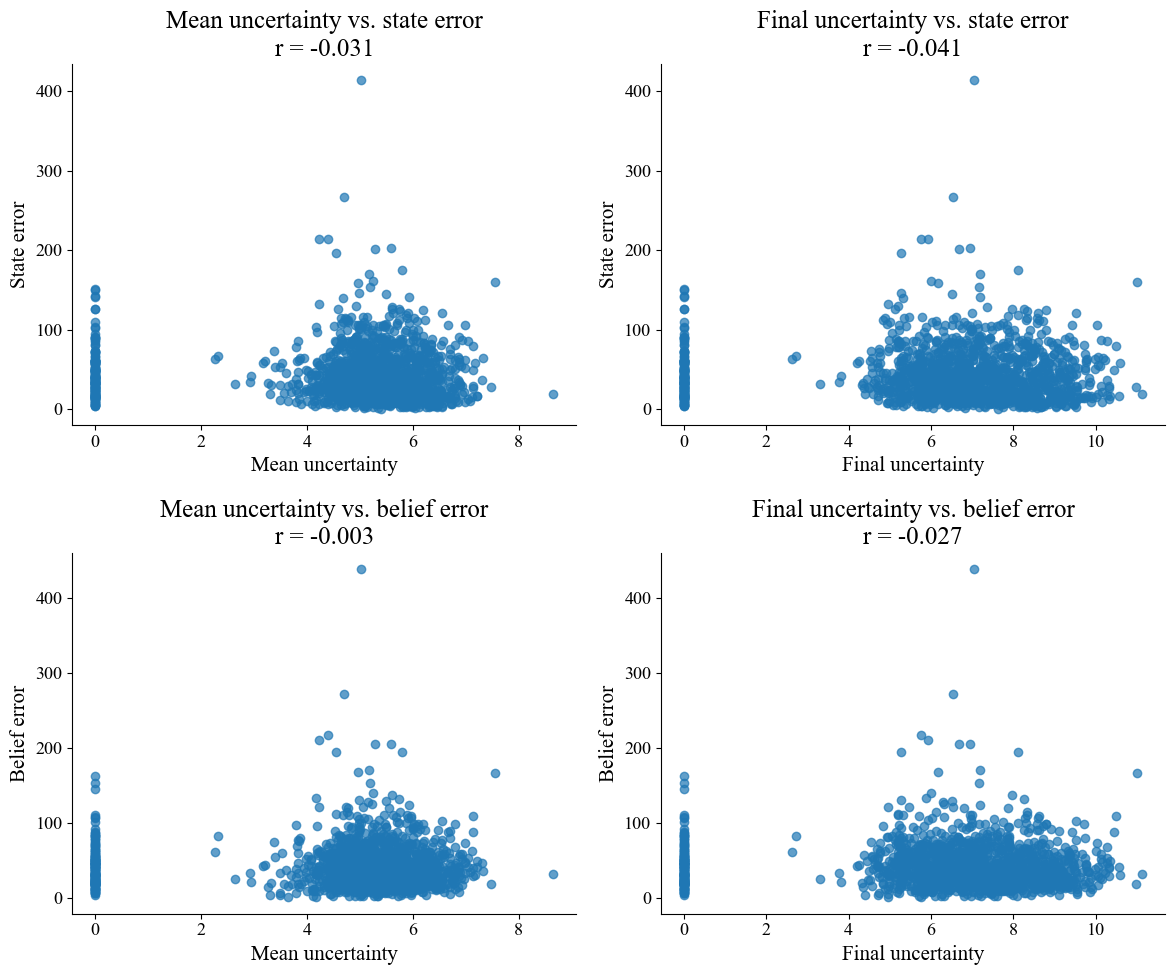

In [66]:
def analyze_behavior_relationship(timedf, sessdf):
    """Analyze relationship between neural encoding of uncertainty and behavioral outcomes"""
    print("\nAnalyzing relationship between uncertainty encoding and behavior...")
    
    # Import necessary libraries
    from scipy.stats import pearsonr
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    
    # Get trial-level data
    neural_data = np.stack(timedf.PPC.to_numpy())
    beh_uncertainty = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5  # std
    trial_ids = timedf.trial.to_numpy()
    
    # Get behavioral metrics from the sessdf DataFrame
    state_error = sessdf.state_error.to_numpy()
    belief_error = sessdf.belief_error.to_numpy()
    
    # Analyze per-trial correlation between neural encoding and behavior
    trial_data = []
    
    unique_trials = np.unique(trial_ids)
    for trial_idx, trial in enumerate(unique_trials):
        if trial_idx >= len(state_error):  # Ensure we don't exceed array bounds
            break
            
        trial_mask = trial_ids == trial
        if sum(trial_mask) < 5:  # Skip very short trials
            continue
            
        # Get trial data
        trial_neural = neural_data[trial_mask]
        trial_uncertainty = beh_uncertainty[trial_mask]
        
        # Calculate correlation between neural activity and uncertainty for this trial
        trial_corrs = []
        for dim in range(trial_neural.shape[1]):
            corr, p = pearsonr(trial_neural[:, dim], trial_uncertainty)
            trial_corrs.append((corr, p))
        
        # Find dimension with strongest correlation
        trial_corrs_abs = [abs(c[0]) for c in trial_corrs]
        best_dim = np.argmax(trial_corrs_abs)
        best_corr, best_p = trial_corrs[best_dim]
        
        # Calculate mean and final uncertainty
        mean_uncertainty = np.mean(trial_uncertainty)
        final_uncertainty = trial_uncertainty[-1]
        
        # Store trial data
        trial_data.append({
            'trial': trial,
            'best_dim': best_dim,
            'best_corr': best_corr,
            'mean_uncertainty': mean_uncertainty,
            'final_uncertainty': final_uncertainty,
            'state_error': state_error[trial_idx],
            'belief_error': belief_error[trial_idx]
        })
    
    # Convert to DataFrame
    trial_df = pd.DataFrame(trial_data)
    
    # Calculate correlations between uncertainty encoding and behavioral outcomes
    corr_mean_state, p_mean_state = pearsonr(trial_df['mean_uncertainty'], trial_df['state_error'])
    corr_final_state, p_final_state = pearsonr(trial_df['final_uncertainty'], trial_df['state_error'])
    corr_mean_belief, p_mean_belief = pearsonr(trial_df['mean_uncertainty'], trial_df['belief_error'])
    corr_final_belief, p_final_belief = pearsonr(trial_df['final_uncertainty'], trial_df['belief_error'])
    
    print(f"Correlation between mean uncertainty and state error: r={corr_mean_state:.3f} (p={p_mean_state:.3e})")
    print(f"Correlation between final uncertainty and state error: r={corr_final_state:.3f} (p={p_final_state:.3e})")
    print(f"Correlation between mean uncertainty and belief error: r={corr_mean_belief:.3f} (p={p_mean_belief:.3e})")
    print(f"Correlation between final uncertainty and belief error: r={corr_final_belief:.3f} (p={p_final_belief:.3e})")
    
    # Plot
    plt.figure(figsize=(12, 10))
    
    plt.subplot(2, 2, 1)
    plt.scatter(trial_df['mean_uncertainty'], trial_df['state_error'], alpha=0.7)
    plt.xlabel('Mean uncertainty')
    plt.ylabel('State error')
    plt.title(f'Mean uncertainty vs. state error\nr = {corr_mean_state:.3f}')
    
    plt.subplot(2, 2, 2)
    plt.scatter(trial_df['final_uncertainty'], trial_df['state_error'], alpha=0.7)
    plt.xlabel('Final uncertainty')
    plt.ylabel('State error')
    plt.title(f'Final uncertainty vs. state error\nr = {corr_final_state:.3f}')
    
    plt.subplot(2, 2, 3)
    plt.scatter(trial_df['mean_uncertainty'], trial_df['belief_error'], alpha=0.7)
    plt.xlabel('Mean uncertainty')
    plt.ylabel('Belief error')
    plt.title(f'Mean uncertainty vs. belief error\nr = {corr_mean_belief:.3f}')
    
    plt.subplot(2, 2, 4)
    plt.scatter(trial_df['final_uncertainty'], trial_df['belief_error'], alpha=0.7)
    plt.xlabel('Final uncertainty')
    plt.ylabel('Belief error')
    plt.title(f'Final uncertainty vs. belief error\nr = {corr_final_belief:.3f}')
    
    plt.tight_layout()
    plt.show()
    
    return trial_df

behavior_results = analyze_behavior_relationship(timedf, sessdf)


Analyzing uncertainty encoding across task conditions...
Found 4 unique density levels
Found 2 unique visual conditions


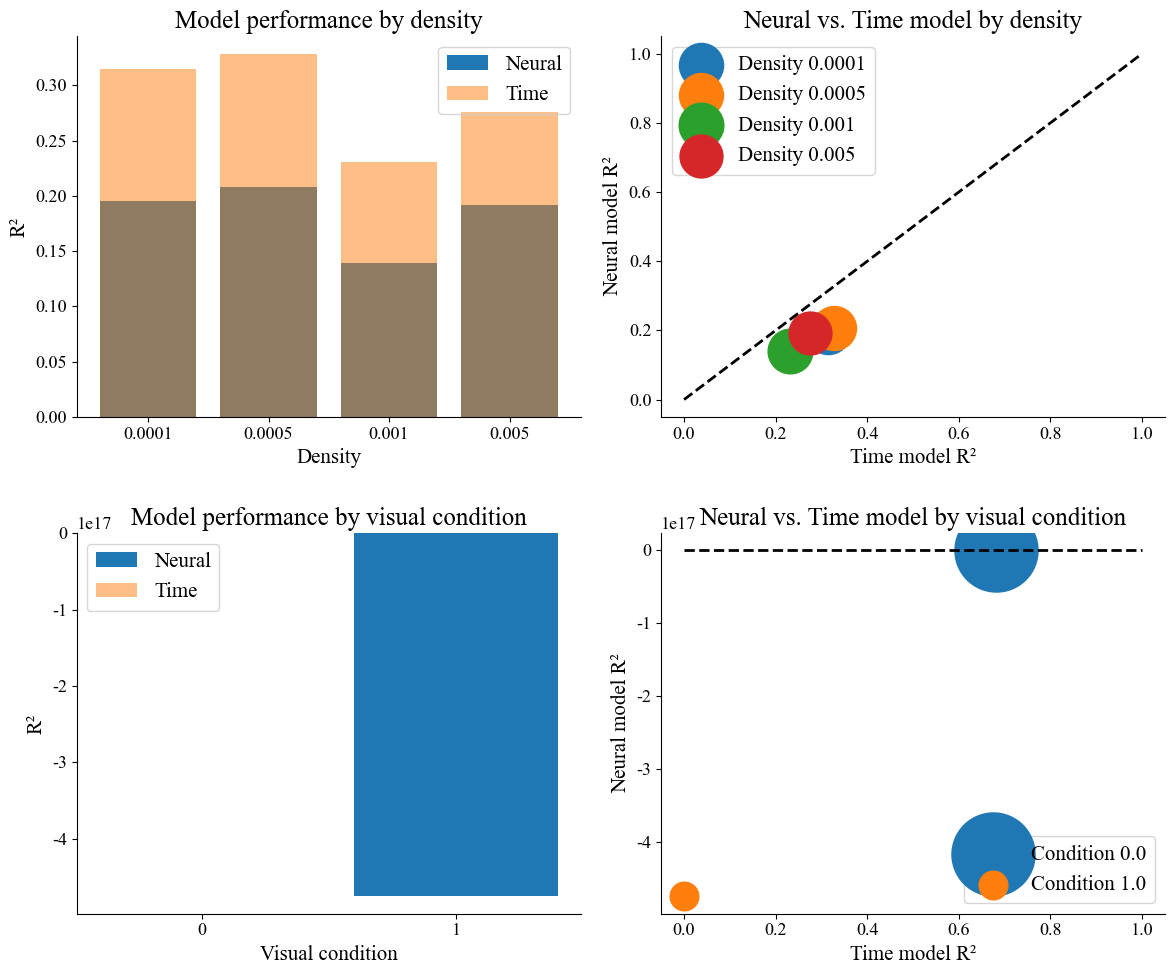

In [64]:
# Analyze how uncertainty encoding varies across different task conditions
def analyze_task_conditions(timedf, sessdf):
    """Analyze how uncertainty encoding varies across different task conditions"""
    print("\nAnalyzing uncertainty encoding across task conditions...")
    
    # Import necessary libraries
    from scipy.stats import pearsonr
    from sklearn.metrics import r2_score
    from sklearn.model_selection import KFold, cross_val_predict
    from sklearn.linear_model import LinearRegression
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    
    neural_data = np.stack(timedf.PPC.to_numpy())
    beh_uncertainty = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5  # std
    time_ratio = timedf.timeratio.to_numpy()
    
    # Get condition variables
    density = timedf.density.to_numpy()  # Task difficulty
    fullon = timedf.fullon.to_numpy()    # Visual condition
    
    # Group data by density levels
    unique_densities = np.unique(density)
    print(f"Found {len(unique_densities)} unique density levels")
    
    density_results = []
    
    for dens in unique_densities:
        dens_mask = density == dens
        if sum(dens_mask) < 100:  # Skip conditions with too few samples
            continue
            
        # Get data for this condition
        dens_neural = neural_data[dens_mask]
        dens_uncertainty = beh_uncertainty[dens_mask]
        dens_time = time_ratio[dens_mask]
        
        # Full neural model
        model = LinearRegression()
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        neural_predictions = cross_val_predict(model, dens_neural, dens_uncertainty, cv=cv)
        
        # Time-only model
        time_model = LinearRegression()
        time_predictions = cross_val_predict(time_model, dens_time.reshape(-1, 1), dens_uncertainty, cv=cv)
        
        # Evaluate models
        neural_r2 = r2_score(dens_uncertainty, neural_predictions)
        time_r2 = r2_score(dens_uncertainty, time_predictions)
        neural_corr, neural_p = pearsonr(dens_uncertainty, neural_predictions)
        time_corr, time_p = pearsonr(dens_uncertainty, time_predictions)
        
        density_results.append({
            'density': dens,
            'neural_r2': neural_r2,
            'time_r2': time_r2,
            'neural_corr': neural_corr,
            'time_corr': time_corr,
            'n_samples': sum(dens_mask)
        })
    
    # Convert to DataFrame
    density_df = pd.DataFrame(density_results)
    
    # Similar analysis for visual condition
    unique_fullons = np.unique(fullon)
    print(f"Found {len(unique_fullons)} unique visual conditions")
    
    fullon_results = []
    
    for vis in unique_fullons:
        vis_mask = fullon == vis
        if sum(vis_mask) < 100:  # Skip conditions with too few samples
            continue
            
        # Get data for this condition
        vis_neural = neural_data[vis_mask]
        vis_uncertainty = beh_uncertainty[vis_mask]
        vis_time = time_ratio[vis_mask]
        
        # Full neural model
        model = LinearRegression()
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        neural_predictions = cross_val_predict(model, vis_neural, vis_uncertainty, cv=cv)
        
        # Time-only model
        time_model = LinearRegression()
        time_predictions = cross_val_predict(time_model, vis_time.reshape(-1, 1), vis_uncertainty, cv=cv)
        
        # Evaluate models
        neural_r2 = r2_score(vis_uncertainty, neural_predictions)
        time_r2 = r2_score(vis_uncertainty, time_predictions)
        neural_corr, neural_p = pearsonr(vis_uncertainty, neural_predictions)
        time_corr, time_p = pearsonr(vis_uncertainty, time_predictions)
        
        fullon_results.append({
            'fullon': vis,
            'neural_r2': neural_r2,
            'time_r2': time_r2,
            'neural_corr': neural_corr,
            'time_corr': time_corr,
            'n_samples': sum(vis_mask)
        })
    
    # Convert to DataFrame
    fullon_df = pd.DataFrame(fullon_results)
    
    # Plot results
    plt.figure(figsize=(12, 10))
    
    # Density plots
    plt.subplot(2, 2, 1)
    plt.bar(density_df['density'].astype(str), density_df['neural_r2'], label='Neural')
    plt.bar(density_df['density'].astype(str), density_df['time_r2'], label='Time', alpha=0.5)
    plt.xlabel('Density')
    plt.ylabel('R²')
    plt.title('Model performance by density')
    plt.legend()
    
    plt.subplot(2, 2, 2)
    for i, row in density_df.iterrows():
        plt.scatter(row['time_r2'], row['neural_r2'], s=row['n_samples']/100, 
                   label=f"Density {row['density']}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('Time model R²')
    plt.ylabel('Neural model R²')
    plt.title('Neural vs. Time model by density')
    plt.legend()
    
    # Fullon plots
    if len(fullon_df) > 0:
        plt.subplot(2, 2, 3)
        plt.bar(fullon_df['fullon'].astype(str), fullon_df['neural_r2'], label='Neural')
        plt.bar(fullon_df['fullon'].astype(str), fullon_df['time_r2'], label='Time', alpha=0.5)
        plt.xlabel('Visual condition')
        plt.ylabel('R²')
        plt.title('Model performance by visual condition')
        plt.legend()
        
        plt.subplot(2, 2, 4)
        for i, row in fullon_df.iterrows():
            plt.scatter(row['time_r2'], row['neural_r2'], s=row['n_samples']/100, 
                       label=f"Condition {row['fullon']}")
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('Time model R²')
        plt.ylabel('Neural model R²')
        plt.title('Neural vs. Time model by visual condition')
        plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return density_df, fullon_df

density_results, fullon_results = analyze_task_conditions(timedf, sessdf)

Analyzing correlations between neural dimensions and uncertainty/time...

Top 5 neural dimensions correlating with uncertainty:
Dimension 105: uncertainty r=-0.227 (p=0.000e+00), time r=-0.354 (p=0.000e+00)
Dimension 6: uncertainty r=-0.215 (p=0.000e+00), time r=-0.430 (p=0.000e+00)
Dimension 0: uncertainty r=-0.195 (p=0.000e+00), time r=-0.316 (p=0.000e+00)
Dimension 68: uncertainty r=-0.190 (p=0.000e+00), time r=-0.349 (p=0.000e+00)
Dimension 79: uncertainty r=-0.183 (p=0.000e+00), time r=-0.322 (p=0.000e+00)

Performing partial correlation analysis to control for time...

Top 5 neural dimensions with partial correlation to uncertainty (controlling for time):
Dimension 88: partial r=-0.060 (p=0.000e+00)
Dimension 70: partial r=-0.055 (p=5.012e-261)
Dimension 78: partial r=-0.052 (p=4.147e-239)
Dimension 105: partial r=-0.050 (p=6.734e-224)
Dimension 48: partial r=-0.044 (p=3.614e-174)

Performing linear regression to predict uncertainty from neural data...
Full model: R² = 0.163, RMS

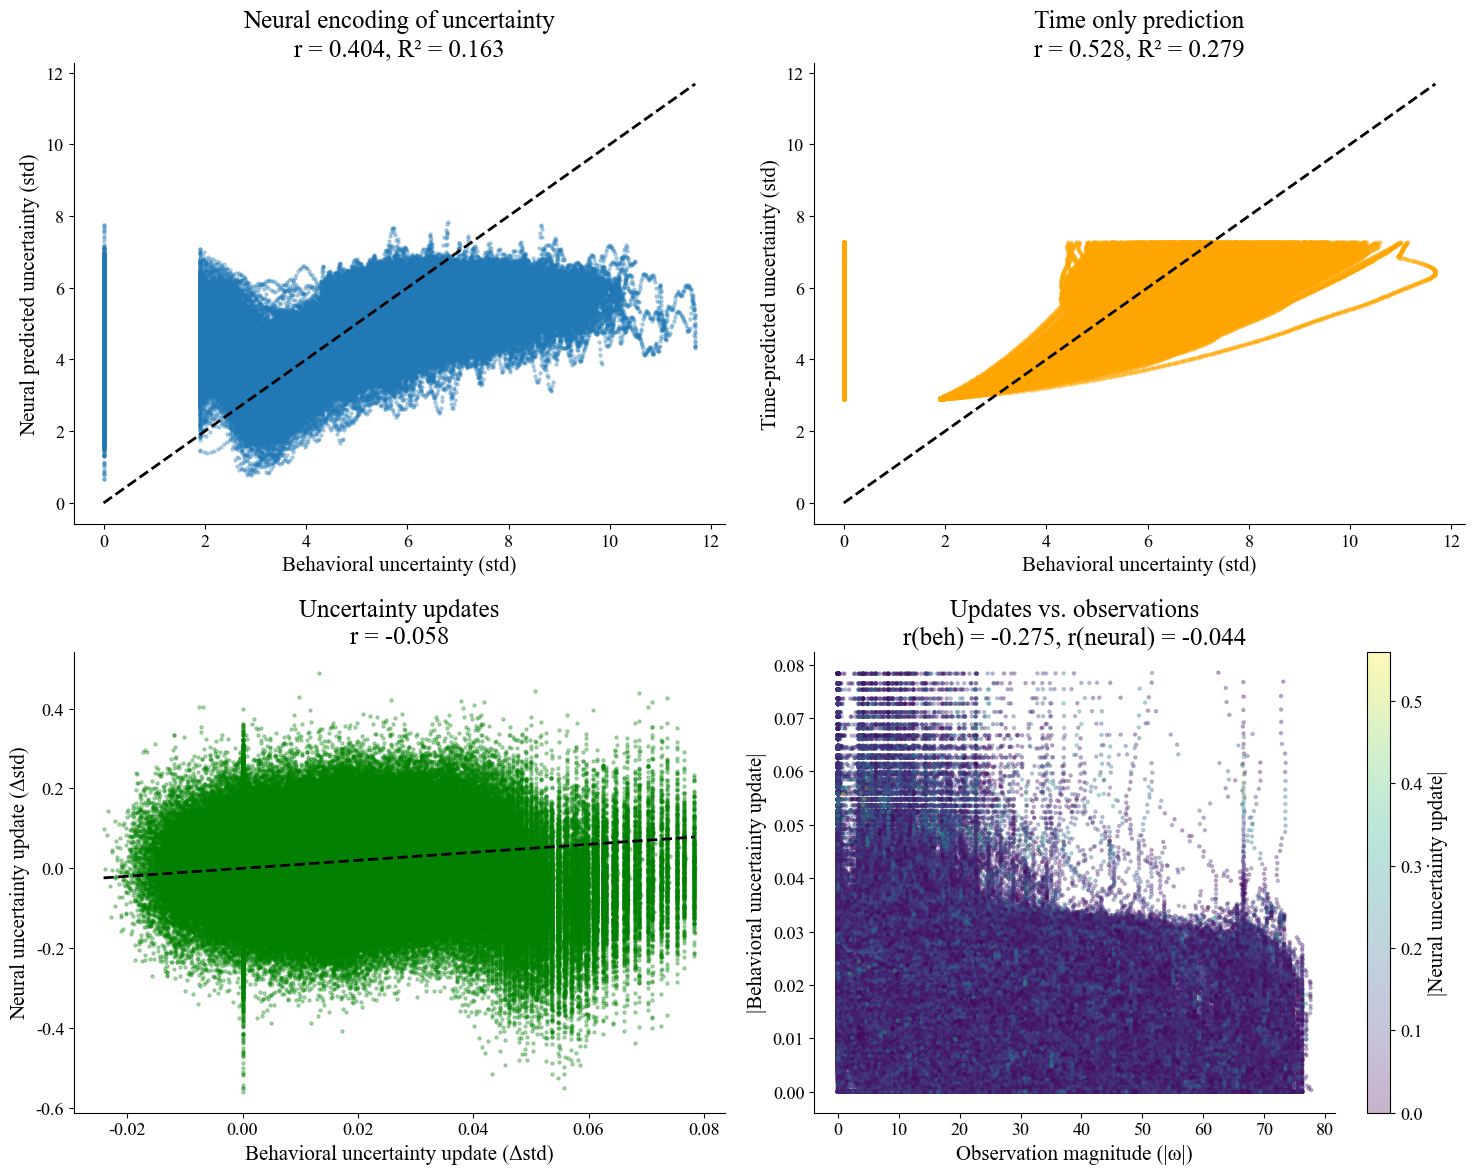

In [59]:
# Revised uncertainty analysis function with simpler approach
def analyze_neural_uncertainty(timedf, sessdf, plot_results=True):
    """
    Simplified analysis of neural encoding of uncertainty
    """
    results = {}
    
    # Extract relevant variables
    neural_data = np.stack(timedf.PPC.to_numpy())
    beh_uncertainty = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5  # std
    time_ratio = timedf.timeratio.to_numpy()
    trial_ids = timedf.trial.to_numpy()
    obs = np.abs(timedf.mw.to_numpy())  # Absolute observation values
    
    # 1. Basic correlation analysis
    from scipy.stats import pearsonr
    
    # Compute correlations between neural dimensions and uncertainty/time
    n_dims = neural_data.shape[1]
    uncertainty_corrs = []
    time_corrs = []
    
    print("Analyzing correlations between neural dimensions and uncertainty/time...")
    for i in range(n_dims):
        u_corr, u_p = pearsonr(neural_data[:,i], beh_uncertainty)
        t_corr, t_p = pearsonr(neural_data[:,i], time_ratio)
        uncertainty_corrs.append((u_corr, u_p))
        time_corrs.append((t_corr, t_p))
    
    # Find dimensions with strongest correlation to uncertainty
    uncertainty_corrs_abs = [abs(c[0]) for c in uncertainty_corrs]
    top_uncertainty_dims = np.argsort(uncertainty_corrs_abs)[::-1][:5]
    
    print("\nTop 5 neural dimensions correlating with uncertainty:")
    for i, dim in enumerate(top_uncertainty_dims):
        u_corr, u_p = uncertainty_corrs[dim]
        t_corr, t_p = time_corrs[dim]
        print(f"Dimension {dim}: uncertainty r={u_corr:.3f} (p={u_p:.3e}), time r={t_corr:.3f} (p={t_p:.3e})")
    
    results['uncertainty_corrs'] = uncertainty_corrs
    results['time_corrs'] = time_corrs
    results['top_uncertainty_dims'] = top_uncertainty_dims
    
    # 2. Partial correlation analysis to control for time
    print("\nPerforming partial correlation analysis to control for time...")
    from pingouin import partial_corr
    
    partial_corrs = []
    for i in range(n_dims):
        data = pd.DataFrame({
            'neural': neural_data[:,i],
            'uncertainty': beh_uncertainty,
            'time': time_ratio
        })
        
        # Partial correlation between neural activity and uncertainty, controlling for time
        partial = partial_corr(data=data, x='neural', y='uncertainty', covar='time')
        partial_corrs.append((partial['r'].values[0], partial['p-val'].values[0]))
    
    # Find dimensions with strongest partial correlation to uncertainty
    partial_corrs_abs = [abs(c[0]) for c in partial_corrs]
    top_partial_dims = np.argsort(partial_corrs_abs)[::-1][:5]
    
    print("\nTop 5 neural dimensions with partial correlation to uncertainty (controlling for time):")
    for i, dim in enumerate(top_partial_dims):
        p_corr, p_p = partial_corrs[dim]
        print(f"Dimension {dim}: partial r={p_corr:.3f} (p={p_p:.3e})")
    
    results['partial_corrs'] = partial_corrs
    results['top_partial_dims'] = top_partial_dims
    
    # 3. Linear regression to predict uncertainty from neural data
    from sklearn.model_selection import KFold, cross_val_predict
    from sklearn.linear_model import LinearRegression, Ridge
    from sklearn.metrics import r2_score, mean_squared_error
    
    print("\nPerforming linear regression to predict uncertainty from neural data...")
    
    # 3.1 Full model
    model = LinearRegression()
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    neural_uncertainty = cross_val_predict(model, neural_data, beh_uncertainty, cv=cv)
    
    # Evaluate full model
    r2_full = r2_score(beh_uncertainty, neural_uncertainty)
    rmse_full = np.sqrt(mean_squared_error(beh_uncertainty, neural_uncertainty))
    corr_full, p_full = pearsonr(beh_uncertainty, neural_uncertainty)
    
    print(f"Full model: R² = {r2_full:.3f}, RMSE = {rmse_full:.3f}, Correlation = {corr_full:.3f} (p={p_full:.3e})")
    
    results['neural_uncertainty'] = neural_uncertainty
    results['full_model_metrics'] = {'r2': r2_full, 'rmse': rmse_full, 'corr': corr_full, 'p': p_full}
    
    # 3.2 Control model with time only
    time_model = LinearRegression()
    time_features = time_ratio.reshape(-1, 1)
    time_predicted = cross_val_predict(time_model, time_features, beh_uncertainty, cv=cv)
    
    # Evaluate time model
    r2_time = r2_score(beh_uncertainty, time_predicted)
    rmse_time = np.sqrt(mean_squared_error(beh_uncertainty, time_predicted))
    corr_time, p_time = pearsonr(beh_uncertainty, time_predicted)
    
    print(f"Time-only model: R² = {r2_time:.3f}, RMSE = {rmse_time:.3f}, Correlation = {corr_time:.3f} (p={p_time:.3e})")
    
    results['time_predicted'] = time_predicted
    results['time_model_metrics'] = {'r2': r2_time, 'rmse': rmse_time, 'corr': corr_time, 'p': p_time}
    
    # 3.3 Use Ridge regression instead of Lasso to avoid sparse matrix issues
    print("\nUsing Ridge regression to identify neural dimensions encoding uncertainty...")
    
    # Use cross-validation to find optimal alpha
    from sklearn.linear_model import RidgeCV
    
    alphas = np.logspace(-5, 5, 20)
    ridge_cv = RidgeCV(alphas=alphas, cv=5)
    ridge_cv.fit(neural_data, beh_uncertainty)
    optimal_alpha = ridge_cv.alpha_
    
    # Train final Ridge model with optimal alpha
    ridge_model = Ridge(alpha=optimal_alpha)
    ridge_model.fit(neural_data, beh_uncertainty)
    ridge_coefs = ridge_model.coef_
    
    # Get top coefficients
    top_ridge_dims = np.argsort(abs(ridge_coefs))[::-1][:5]
    
    print(f"Ridge regression with optimal alpha={optimal_alpha:.5f}")
    print("Top 5 dimensions by coefficient magnitude:")
    for dim in top_ridge_dims:
        print(f"Dimension {dim}: coefficient = {ridge_coefs[dim]:.5f}")
    
    results['ridge_coefs'] = ridge_coefs
    results['top_ridge_dims'] = top_ridge_dims
    
    # 4. Analysis of uncertainty updates in relation to observations
    print("\nAnalyzing uncertainty updates in relation to observations...")
    
    # Calculate trial-by-trial uncertainty updates and neural predictions
    beh_updates, neural_updates, obs_values, trial_indices = [], [], [], []
    
    unique_trials = np.unique(trial_ids)
    for trial in unique_trials:
        trial_mask = trial_ids == trial
        if sum(trial_mask) < 3:  # Skip very short trials
            continue
            
        trial_beh = beh_uncertainty[trial_mask]
        trial_neural = neural_uncertainty[trial_mask]
        trial_obs = obs[trial_mask]
        
        # Calculate updates
        beh_update = np.diff(trial_beh)
        neural_update = np.diff(trial_neural)
        obs_value = trial_obs[:-1]  # Observation at t corresponds to update from t to t+1
        
        beh_updates.extend(beh_update)
        neural_updates.extend(neural_update)
        obs_values.extend(obs_value)
        trial_indices.extend([trial] * len(beh_update))
    
    # Convert to arrays
    beh_updates = np.array(beh_updates)
    neural_updates = np.array(neural_updates)
    obs_values = np.array(obs_values)
    
    # Compute correlation between behavioral and neural updates
    update_corr, update_p = pearsonr(beh_updates, neural_updates)
    print(f"Correlation between behavioral and neural uncertainty updates: r={update_corr:.3f} (p={update_p:.3e})")
    
    # Compute correlation between updates and observation magnitude
    beh_obs_corr, beh_obs_p = pearsonr(abs(beh_updates), obs_values)
    neural_obs_corr, neural_obs_p = pearsonr(abs(neural_updates), obs_values)
    
    print(f"Correlation between behavioral updates and observation magnitude: r={beh_obs_corr:.3f} (p={beh_obs_p:.3e})")
    print(f"Correlation between neural updates and observation magnitude: r={neural_obs_corr:.3f} (p={neural_obs_p:.3e})")
    
    results['updates'] = {
        'beh_updates': beh_updates,
        'neural_updates': neural_updates,
        'obs_values': obs_values,
        'update_corr': update_corr,
        'beh_obs_corr': beh_obs_corr,
        'neural_obs_corr': neural_obs_corr
    }
    
    # 5. Plot results if requested
    if plot_results:
        import matplotlib.pyplot as plt
        
        fig = plt.figure(figsize=(15, 12))
        
        # Plot 1: Scatter of behavioral vs. neural uncertainty
        ax1 = fig.add_subplot(2, 2, 1)
        ax1.scatter(beh_uncertainty, neural_uncertainty, alpha=0.3, s=5)
        ax1.plot([min(beh_uncertainty), max(beh_uncertainty)], 
                 [min(beh_uncertainty), max(beh_uncertainty)], 'k--')
        ax1.set_xlabel('Behavioral uncertainty (std)')
        ax1.set_ylabel('Neural predicted uncertainty (std)')
        ax1.set_title(f'Neural encoding of uncertainty\nr = {corr_full:.3f}, R² = {r2_full:.3f}')
        
        # Plot 2: Compare with time prediction
        ax2 = fig.add_subplot(2, 2, 2)
        ax2.scatter(beh_uncertainty, time_predicted, alpha=0.3, s=5, color='orange')
        ax2.plot([min(beh_uncertainty), max(beh_uncertainty)], 
                 [min(beh_uncertainty), max(beh_uncertainty)], 'k--')
        ax2.set_xlabel('Behavioral uncertainty (std)')
        ax2.set_ylabel('Time-predicted uncertainty (std)')
        ax2.set_title(f'Time only prediction\nr = {corr_time:.3f}, R² = {r2_time:.3f}')
        
        # Plot 3: Uncertainty updates
        ax3 = fig.add_subplot(2, 2, 3)
        ax3.scatter(beh_updates, neural_updates, alpha=0.3, s=5, color='green')
        ax3.plot([min(beh_updates), max(beh_updates)], 
                 [min(beh_updates), max(beh_updates)], 'k--')
        ax3.set_xlabel('Behavioral uncertainty update (Δstd)')
        ax3.set_ylabel('Neural uncertainty update (Δstd)')
        ax3.set_title(f'Uncertainty updates\nr = {update_corr:.3f}')
        
        # Plot 4: Uncertainty updates vs observation magnitude
        ax4 = fig.add_subplot(2, 2, 4)
        im = ax4.scatter(obs_values, abs(beh_updates), alpha=0.3, s=5, 
                         c=abs(neural_updates), cmap='viridis')
        ax4.set_xlabel('Observation magnitude (|ω|)')
        ax4.set_ylabel('|Behavioral uncertainty update|')
        ax4.set_title(f'Updates vs. observations\nr(beh) = {beh_obs_corr:.3f}, r(neural) = {neural_obs_corr:.3f}')
        cbar = plt.colorbar(im, ax=ax4)
        cbar.set_label('|Neural uncertainty update|')
        
        plt.tight_layout()
        plt.show()
        
    return results

# Now let's run the analysis
results = analyze_neural_uncertainty(timedf, sessdf)


=== UNCERTAINTY VARIANCE ANALYSIS ===
Found 1537 unique trials in timedf
Processed 1537 valid trials


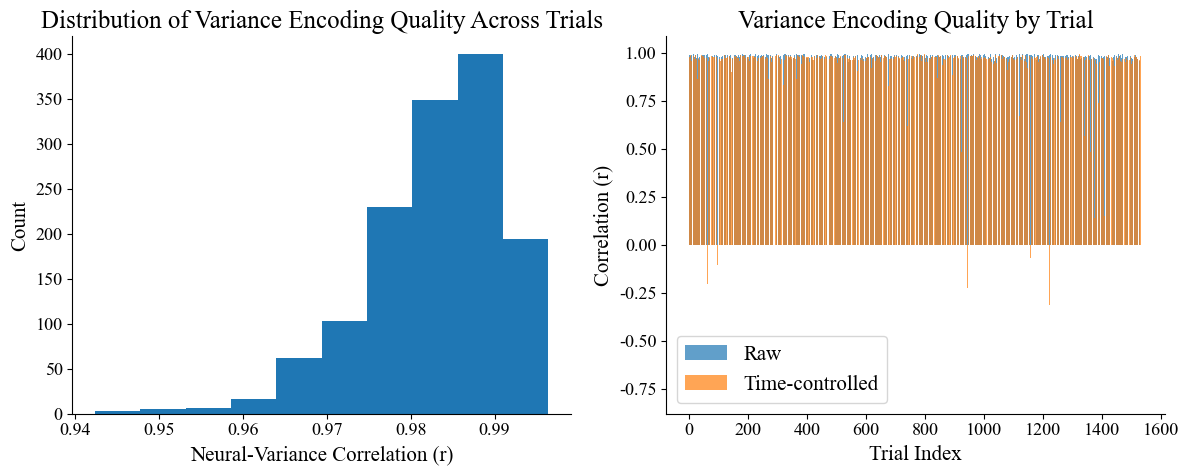

Mean variance encoding across trials: r=nan
Number of trials with significant encoding: 1369/1537

Pooled variance encoding: r=0.492, p=0.000e+00


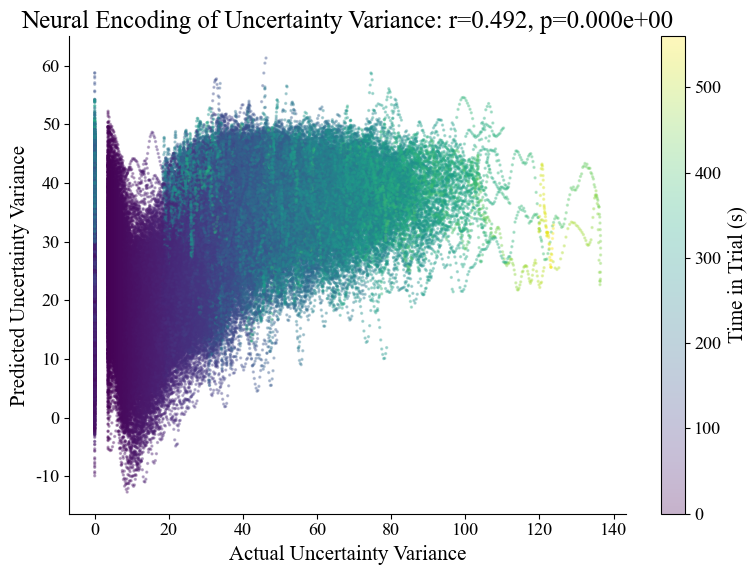

Pooled variance encoding (controlling for time): r=0.172, p=0.000e+00


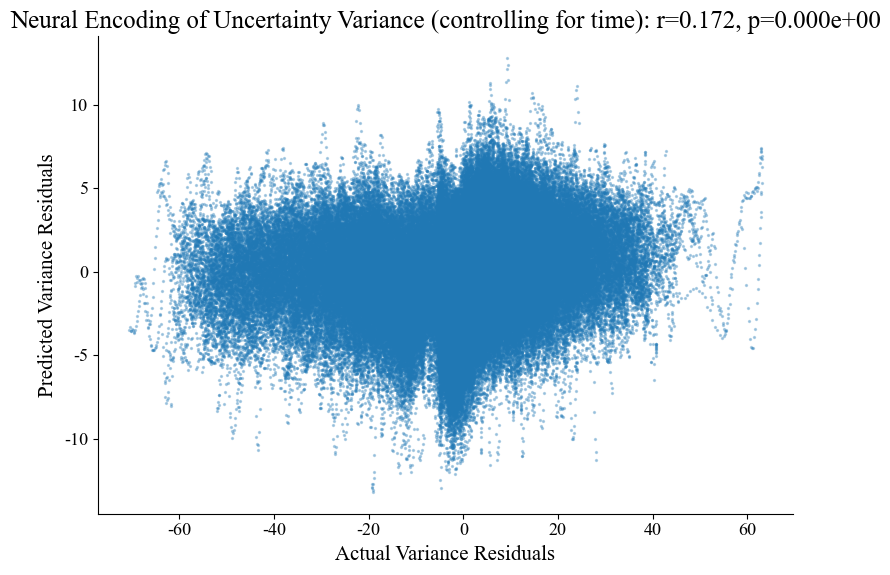


=== UNCERTAINTY UPDATES ANALYSIS ===
Found 1537 unique trials for update analysis
Processed 1537 valid trials for updates


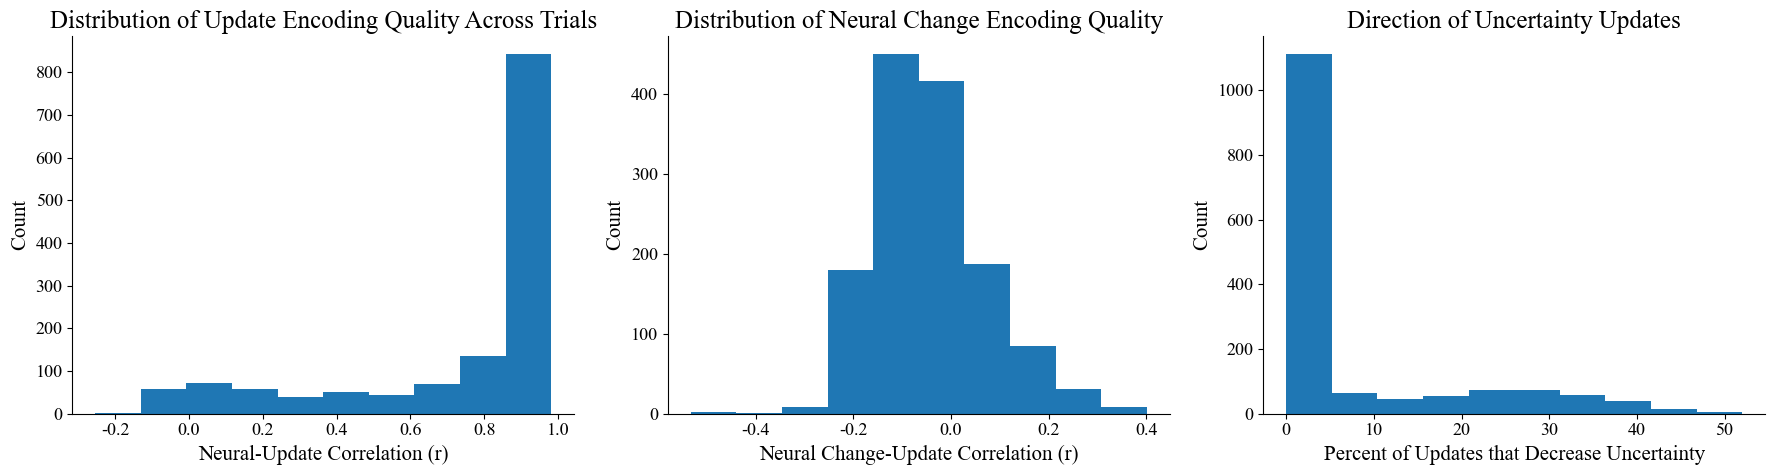

Mean absolute update encoding across trials: r=0.740
Mean neural change encoding across trials: r=-0.044
Average percent of updates decreasing uncertainty: 6.7%
Number of trials with significant update encoding: 1230/1537
Percent of all updates that decrease uncertainty: 7.7%

Correlation between observation magnitude and absolute uncertainty updates: r=-0.231, p=0.000e+00


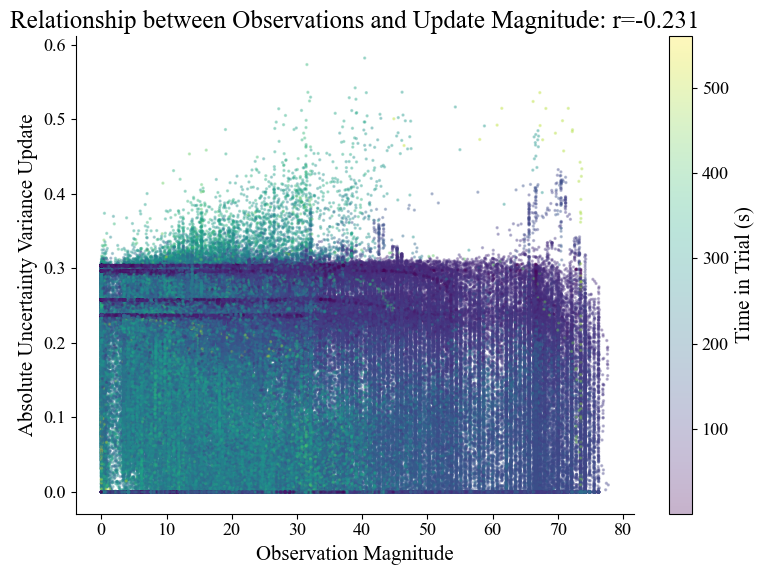

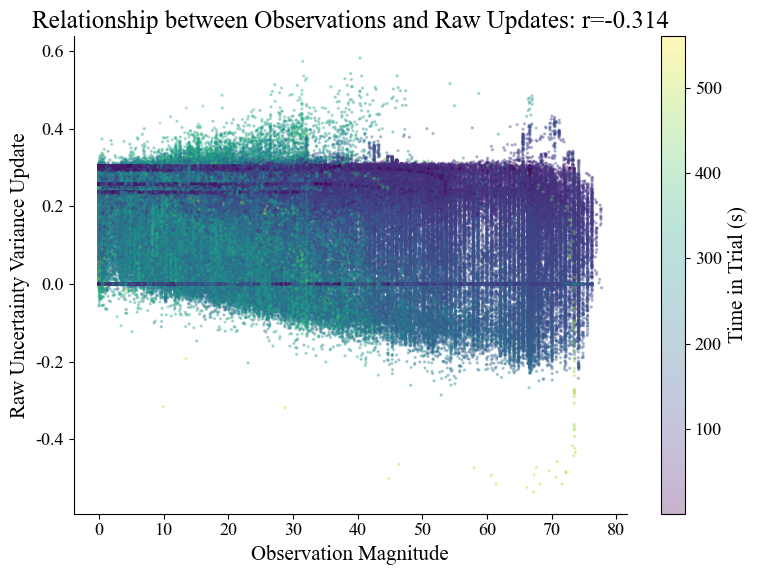

Pooled absolute update encoding: r=0.332, p=0.000e+00
Pooled neural change encoding: r=0.037, p=2.616e-123


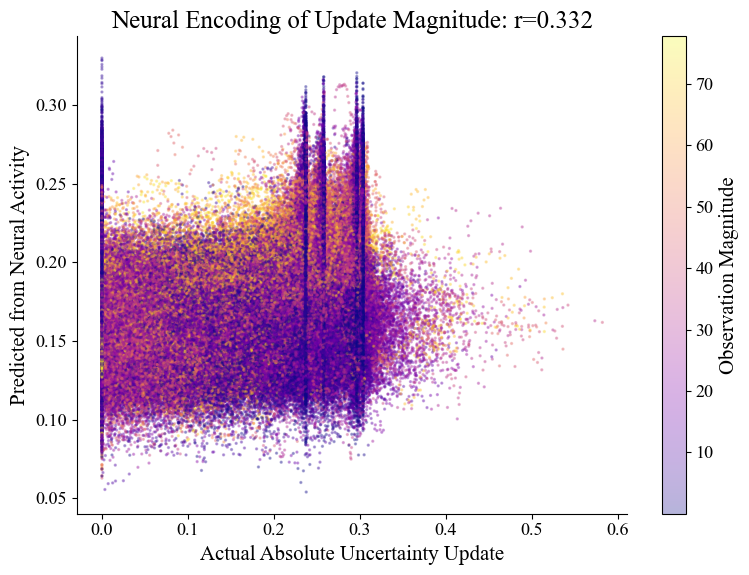

High observation absolute update encoding: r=0.385, p=0.000e+00
Low observation absolute update encoding: r=0.296, p=0.000e+00


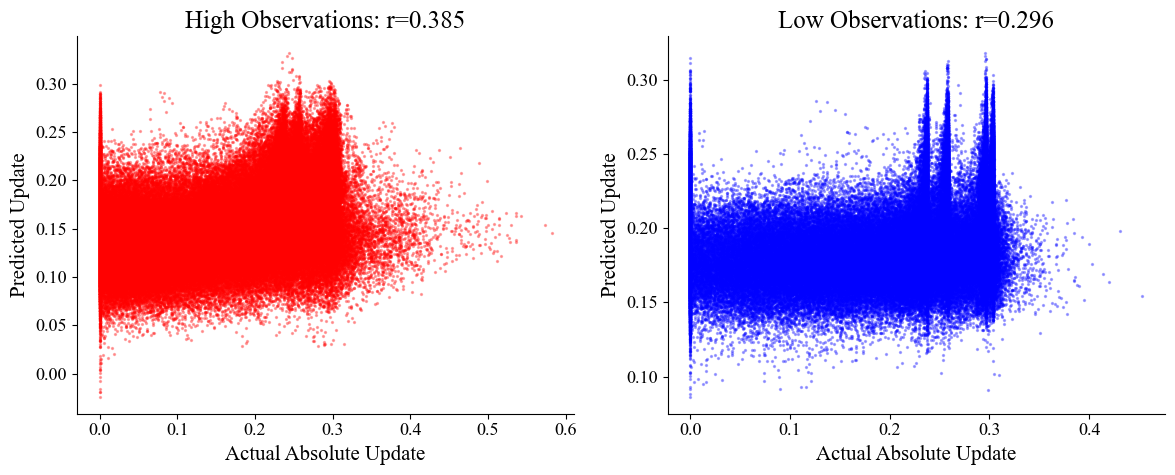

Correlation between time and update magnitude: r=-0.358, p=0.000e+00


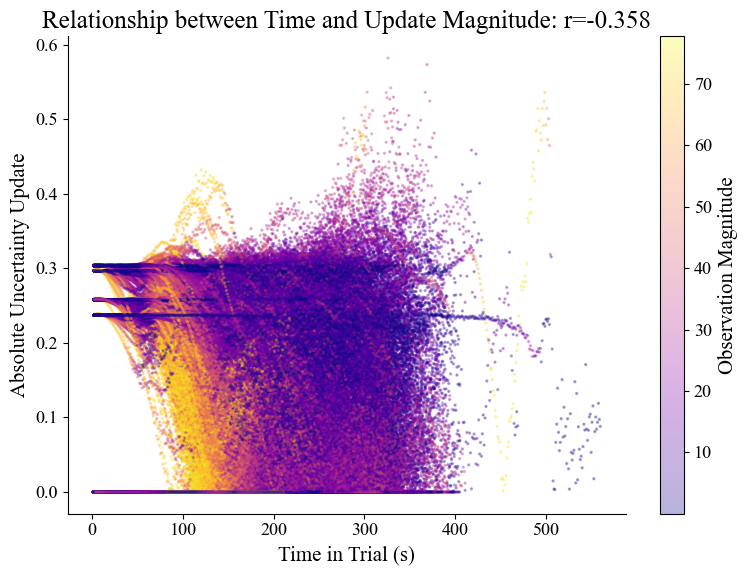

Increasing updates encoding: r=0.408, p=0.000e+00, n=324189
Decreasing updates encoding: r=0.323, p=0.000e+00, n=30646


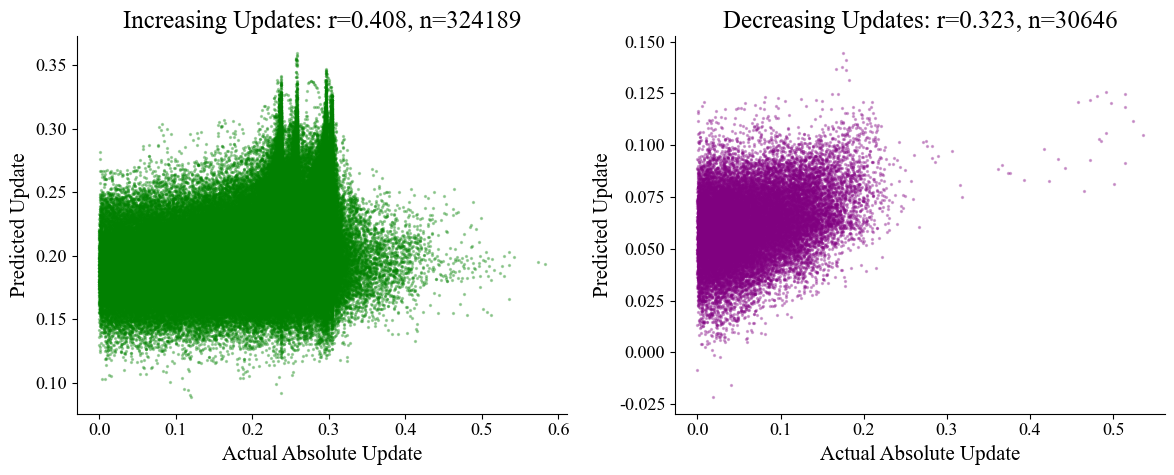

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV
from sklearn.model_selection import cross_val_predict, KFold
from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

def analyze_uncertainty_var_by_trial(timedf):
    """Analyze neural encoding of uncertainty variance with proper trial boundaries using timedf"""
    # Get unique trials
    unique_trials = np.unique(timedf.trial)
    print(f"Found {len(unique_trials)} unique trials in timedf")
    
    # Results storage
    trial_results = []
    neural_var_correlations = []
    
    # Analyze each trial separately
    for trial_num in unique_trials:
        # Extract data for this trial
        trial_data = timedf[timedf.trial == trial_num]
        
        if len(trial_data) < 10:  # Skip trials with too few samples
            continue
            
        trial_neural = np.stack(trial_data.PPC.to_numpy())
        trial_uncertainty_var = np.stack(trial_data.uncertainty.to_numpy())[:,0,0]  # variance
        trial_timer = trial_data.timer.to_numpy()
        
        # Calculate correlation between time and uncertainty variance
        time_var_r, time_var_p = pearsonr(trial_timer, trial_uncertainty_var)
        
        # Calculate neural encoding of variance
        model = Ridge(alpha=1.0)
        kf = KFold(n_splits=min(5, len(trial_neural) // 2), shuffle=True, random_state=42)
        
        try:
            predictions = cross_val_predict(model, trial_neural, trial_uncertainty_var, cv=kf)
            var_r, var_p = pearsonr(trial_uncertainty_var, predictions)
            neural_var_correlations.append(var_r)
            
            # After controlling for time
            var_residuals = trial_uncertainty_var - np.polyval(np.polyfit(trial_timer, trial_uncertainty_var, 1), trial_timer)
            res_predictions = cross_val_predict(model, trial_neural, var_residuals, cv=kf)
            res_r, res_p = pearsonr(var_residuals, res_predictions)
            
            # Store results
            trial_results.append({
                'trial': trial_num,
                'var_r': var_r,
                'var_p': var_p,
                'time_var_r': time_var_r,
                'res_r': res_r,
                'res_p': res_p,
                'mean_var': np.mean(trial_uncertainty_var),
                'n_timepoints': len(trial_neural)
            })
        except Exception as e:
            # Skip trials that cause errors
            print(f"Error in trial {trial_num}: {e}")
            continue
    
    print(f"Processed {len(trial_results)} valid trials")
    
    # Plot distribution of variance encoding across trials
    if len(neural_var_correlations) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Histogram
        axes[0].hist(neural_var_correlations, bins=10)
        axes[0].set_xlabel('Neural-Variance Correlation (r)')
        axes[0].set_ylabel('Count')
        axes[0].set_title('Distribution of Variance Encoding Quality Across Trials')
        
        # Individual trials
        var_correlations = [t['var_r'] for t in trial_results]
        res_correlations = [t['res_r'] for t in trial_results]
        
        axes[1].bar(range(len(var_correlations)), var_correlations, alpha=0.7, label='Raw')
        axes[1].bar(range(len(res_correlations)), res_correlations, alpha=0.7, label='Time-controlled')
        axes[1].set_xlabel('Trial Index')
        axes[1].set_ylabel('Correlation (r)')
        axes[1].set_title('Variance Encoding Quality by Trial')
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()
        
        # Summary statistics
        print(f"Mean variance encoding across trials: r={np.mean(neural_var_correlations):.3f}")
        print(f"Number of trials with significant encoding: {sum(1 for t in trial_results if t['var_p'] < 0.05)}/{len(trial_results)}")
    
    # Now analyze pooled data while respecting trial boundaries
    all_neural = []
    all_uncertainty_var = []
    all_timer = []
    all_trial_idx = []
    
    for trial_num in unique_trials:
        trial_data = timedf[timedf.trial == trial_num]
        
        if len(trial_data) < 10:  # Skip trials with too few samples
            continue
            
        neural = np.stack(trial_data.PPC.to_numpy())
        uncertainty_var = np.stack(trial_data.uncertainty.to_numpy())[:,0,0]  # variance
        timer = trial_data.timer.to_numpy()
        trial_idx = np.ones(len(neural)) * trial_num
        
        all_neural.append(neural)
        all_uncertainty_var.append(uncertainty_var)
        all_timer.append(timer)
        all_trial_idx.append(trial_idx)
    
    # Concatenate data
    all_neural = np.vstack(all_neural)
    all_uncertainty_var = np.concatenate(all_uncertainty_var)
    all_timer = np.concatenate(all_timer)
    all_trial_idx = np.concatenate(all_trial_idx)
    
    # Train model on all data
    model = Ridge(alpha=1.0)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    predictions = cross_val_predict(model, all_neural, all_uncertainty_var, cv=kf)
    var_r, var_p = pearsonr(all_uncertainty_var, predictions)
    
    print(f"\nPooled variance encoding: r={var_r:.3f}, p={var_p:.3e}")
    
    # Plot predicted vs actual
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(all_uncertainty_var, predictions, alpha=0.3, s=2, c=all_timer, cmap='viridis')
    ax.set_xlabel('Actual Uncertainty Variance')
    ax.set_ylabel('Predicted Uncertainty Variance')
    ax.set_title(f'Neural Encoding of Uncertainty Variance: r={var_r:.3f}, p={var_p:.3e}')
    cbar = plt.colorbar(scatter)
    cbar.set_label('Time in Trial (s)')
    plt.tight_layout()
    plt.show()
    
    # After controlling for time
    time_model = Ridge(alpha=1.0)
    var_residuals = all_uncertainty_var - cross_val_predict(time_model, all_timer.reshape(-1, 1), all_uncertainty_var)
    
    res_model = Ridge(alpha=1.0)
    res_predictions = cross_val_predict(res_model, all_neural, var_residuals, cv=kf)
    res_r, res_p = pearsonr(var_residuals, res_predictions)
    
    print(f"Pooled variance encoding (controlling for time): r={res_r:.3f}, p={res_p:.3e}")
    
    # Plot residual predictions
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(var_residuals, res_predictions, alpha=0.3, s=2)
    ax.set_xlabel('Actual Variance Residuals')
    ax.set_ylabel('Predicted Variance Residuals')
    ax.set_title(f'Neural Encoding of Uncertainty Variance (controlling for time): r={res_r:.3f}, p={res_p:.3e}')
    plt.tight_layout()
    plt.show()
    
    return {
        'trial_results': trial_results,
        'pooled_var_r': var_r,
        'pooled_res_r': res_r,
        'all_neural': all_neural,
        'all_uncertainty_var': all_uncertainty_var,
        'all_timer': all_timer,
        'all_trial_idx': all_trial_idx
    }

def analyze_uncertainty_updates_by_trial(timedf):
    """Analyze neural encoding of uncertainty updates with proper trial boundaries using timedf"""
    # Get unique trials
    unique_trials = np.unique(timedf.trial)
    print(f"Found {len(unique_trials)} unique trials for update analysis")
    
    # Results storage
    update_results = []
    
    # Aggregate storage across all trials
    all_update_neural = []
    all_abs_uncertainty_update = []  # Using absolute change in uncertainty
    all_raw_uncertainty_update = []  # Raw (signed) change in uncertainty
    all_update_obs = []
    all_update_timer = []
    all_dneural = []
    all_trial_idx = []
    
    for trial_num in unique_trials:
        # Extract data for this trial
        trial_data = timedf[timedf.trial == trial_num]
        
        if len(trial_data) < 10:  # Skip trials with too few samples
            continue
            
        trial_neural = np.stack(trial_data.PPC.to_numpy())
        trial_uncertainty_var = np.stack(trial_data.uncertainty.to_numpy())[:,0,0]  # variance
        trial_timer = trial_data.timer.to_numpy()
        trial_obs = np.abs(trial_data.mw.to_numpy())  # observation magnitude
        
        # Calculate uncertainty updates (changes) within this trial only
        d_uncertainty_var = np.diff(trial_uncertainty_var)
        
        if len(d_uncertainty_var) < 5:  # Skip trials with too few updates
            continue
        
        # Take absolute value of updates - we care about magnitude of change
        abs_d_uncertainty_var = np.abs(d_uncertainty_var)
        
        # Also calculate direction of updates (1 for increase, -1 for decrease)
        update_direction = np.sign(d_uncertainty_var)
        
        # For the neural and observation data, we need to remove the first point to align with d_uncertainty_var
        update_neural = trial_neural[1:]
        update_obs = trial_obs[1:]
        update_timer = trial_timer[1:]
        update_trial_idx = np.ones(len(update_neural)) * trial_num
        
        # Calculate neural changes
        dneural = np.diff(trial_neural, axis=0)
        
        # Check correlation between observation magnitude and absolute uncertainty updates
        obs_update_r, obs_update_p = pearsonr(update_obs, abs_d_uncertainty_var)
        
        # Predict absolute uncertainty updates from neural activity
        model = Ridge(alpha=1.0)
        kf = KFold(n_splits=min(5, len(update_neural) // 2), shuffle=True, random_state=42)
        
        try:
            predictions = cross_val_predict(model, update_neural, abs_d_uncertainty_var, cv=kf)
            update_r, update_p = pearsonr(abs_d_uncertainty_var, predictions)
            
            # Also try neural changes to predict uncertainty updates
            dneural_predictions = cross_val_predict(model, dneural, abs_d_uncertainty_var, cv=kf)
            dneural_r, dneural_p = pearsonr(abs_d_uncertainty_var, dneural_predictions)
            
            # Store trial results
            update_results.append({
                'trial': trial_num,
                'update_r': update_r,
                'update_p': update_p,
                'dneural_r': dneural_r,
                'dneural_p': dneural_p,
                'obs_update_r': obs_update_r,
                'mean_update': np.mean(abs_d_uncertainty_var),
                'n_updates': len(abs_d_uncertainty_var),
                'percent_decrease': np.mean(update_direction < 0) * 100
            })
            
            # Append to pooled data
            all_update_neural.append(update_neural)
            all_abs_uncertainty_update.append(abs_d_uncertainty_var)
            all_raw_uncertainty_update.append(d_uncertainty_var)
            all_update_obs.append(update_obs)
            all_update_timer.append(update_timer)
            all_dneural.append(dneural)
            all_trial_idx.append(update_trial_idx)
            
        except Exception as e:
            print(f"Error in trial {trial_num} updates: {e}")
            continue
    
    print(f"Processed {len(update_results)} valid trials for updates")
    
    # Plot distribution of update encoding across trials
    if len(update_results) > 0:
        update_correlations = [t['update_r'] for t in update_results]
        dneural_correlations = [t['dneural_r'] for t in update_results]
        percent_decrease = [t['percent_decrease'] for t in update_results]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Histogram of neural activity predicting updates
        axes[0].hist(update_correlations, bins=10)
        axes[0].set_xlabel('Neural-Update Correlation (r)')
        axes[0].set_ylabel('Count')
        axes[0].set_title('Distribution of Update Encoding Quality Across Trials')
        
        # Histogram of neural changes predicting updates
        axes[1].hist(dneural_correlations, bins=10)
        axes[1].set_xlabel('Neural Change-Update Correlation (r)')
        axes[1].set_ylabel('Count')
        axes[1].set_title('Distribution of Neural Change Encoding Quality')
        
        # Histogram of percent decrease in uncertainty
        axes[2].hist(percent_decrease, bins=10)
        axes[2].set_xlabel('Percent of Updates that Decrease Uncertainty')
        axes[2].set_ylabel('Count')
        axes[2].set_title('Direction of Uncertainty Updates')
        
        plt.tight_layout()
        plt.show()
        
        # Summary statistics
        print(f"Mean absolute update encoding across trials: r={np.nanmean(update_correlations):.3f}")
        print(f"Mean neural change encoding across trials: r={np.nanmean(dneural_correlations):.3f}")
        print(f"Average percent of updates decreasing uncertainty: {np.mean(percent_decrease):.1f}%")
        print(f"Number of trials with significant update encoding: {sum(1 for t in update_results if t['update_p'] < 0.05)}/{len(update_results)}")
    
    # Process pooled data
    if len(all_update_neural) == 0:
        print("No valid updates data found")
        return {}
        
    # Concatenate data
    all_update_neural = np.vstack(all_update_neural)
    all_abs_uncertainty_update = np.concatenate(all_abs_uncertainty_update)
    all_raw_uncertainty_update = np.concatenate(all_raw_uncertainty_update)
    all_update_obs = np.concatenate(all_update_obs)
    all_update_timer = np.concatenate(all_update_timer)
    all_dneural = np.vstack(all_dneural)
    all_trial_idx = np.concatenate(all_trial_idx)
    
    # Direction of updates
    percent_decreasing = np.mean(all_raw_uncertainty_update < 0) * 100
    print(f"Percent of all updates that decrease uncertainty: {percent_decreasing:.1f}%")
    
    # Check correlation between observation magnitude and absolute updates
    obs_update_r, obs_update_p = pearsonr(all_update_obs, all_abs_uncertainty_update)
    print(f"\nCorrelation between observation magnitude and absolute uncertainty updates: r={obs_update_r:.3f}, p={obs_update_p:.3e}")
    
    # Plot relationship between observations and absolute updates
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(all_update_obs, all_abs_uncertainty_update, alpha=0.3, s=2, c=all_update_timer, cmap='viridis')
    ax.set_xlabel('Observation Magnitude')
    ax.set_ylabel('Absolute Uncertainty Variance Update')
    ax.set_title(f'Relationship between Observations and Update Magnitude: r={obs_update_r:.3f}')
    cbar = plt.colorbar(scatter)
    cbar.set_label('Time in Trial (s)')
    plt.tight_layout()
    plt.show()
    
    # Also show relationship between observations and raw updates
    obs_raw_update_r, obs_raw_update_p = pearsonr(all_update_obs, all_raw_uncertainty_update)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(all_update_obs, all_raw_uncertainty_update, alpha=0.3, s=2, c=all_update_timer, cmap='viridis')
    ax.set_xlabel('Observation Magnitude')
    ax.set_ylabel('Raw Uncertainty Variance Update')
    ax.set_title(f'Relationship between Observations and Raw Updates: r={obs_raw_update_r:.3f}')
    cbar = plt.colorbar(scatter)
    cbar.set_label('Time in Trial (s)')
    plt.tight_layout()
    plt.show()
    
    # Analyze neural encoding of absolute updates
    model = Ridge(alpha=1.0)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Predict using neural activity
    update_predictions = cross_val_predict(model, all_update_neural, all_abs_uncertainty_update, cv=kf)
    update_r, update_p = pearsonr(all_abs_uncertainty_update, update_predictions)
    
    print(f"Pooled absolute update encoding: r={update_r:.3f}, p={update_p:.3e}")
    
    # Predict using neural changes
    dneural_predictions = cross_val_predict(model, all_dneural, all_abs_uncertainty_update, cv=kf)
    dneural_r, dneural_p = pearsonr(all_abs_uncertainty_update, dneural_predictions)
    print(f"Pooled neural change encoding: r={dneural_r:.3f}, p={dneural_p:.3e}")
    
    # Plot neural prediction of absolute updates
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(all_abs_uncertainty_update, update_predictions, alpha=0.3, s=2, c=all_update_obs, cmap='plasma')
    ax.set_xlabel('Actual Absolute Uncertainty Update')
    ax.set_ylabel('Predicted from Neural Activity')
    ax.set_title(f'Neural Encoding of Update Magnitude: r={update_r:.3f}')
    cbar = plt.colorbar(scatter)
    cbar.set_label('Observation Magnitude')
    plt.tight_layout()
    plt.show()
    
    # Separate analysis for high vs low observations
    high_obs_mask = all_update_obs > np.median(all_update_obs)
    low_obs_mask = ~high_obs_mask
    
    # High observations
    high_obs_predictions = cross_val_predict(
        model, all_update_neural[high_obs_mask], all_abs_uncertainty_update[high_obs_mask], cv=kf)
    high_obs_r, high_obs_p = pearsonr(all_abs_uncertainty_update[high_obs_mask], high_obs_predictions)
    
    # Low observations
    low_obs_predictions = cross_val_predict(
        model, all_update_neural[low_obs_mask], all_abs_uncertainty_update[low_obs_mask], cv=kf)
    low_obs_r, low_obs_p = pearsonr(all_abs_uncertainty_update[low_obs_mask], low_obs_predictions)
    
    print(f"High observation absolute update encoding: r={high_obs_r:.3f}, p={high_obs_p:.3e}")
    print(f"Low observation absolute update encoding: r={low_obs_r:.3f}, p={low_obs_p:.3e}")
    
    # Plot high vs low observation results
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # High observations
    axes[0].scatter(all_abs_uncertainty_update[high_obs_mask], high_obs_predictions, alpha=0.3, s=2, c='red')
    axes[0].set_xlabel('Actual Absolute Update')
    axes[0].set_ylabel('Predicted Update')
    axes[0].set_title(f'High Observations: r={high_obs_r:.3f}')
    
    # Low observations
    axes[1].scatter(all_abs_uncertainty_update[low_obs_mask], low_obs_predictions, alpha=0.3, s=2, c='blue')
    axes[1].set_xlabel('Actual Absolute Update')
    axes[1].set_ylabel('Predicted Update')
    axes[1].set_title(f'Low Observations: r={low_obs_r:.3f}')
    
    plt.tight_layout()
    plt.show()
    
    # Also analyze correlation between update magnitude and time in trial
    time_update_r, time_update_p = pearsonr(all_update_timer, all_abs_uncertainty_update)
    print(f"Correlation between time and update magnitude: r={time_update_r:.3f}, p={time_update_p:.3e}")
    
    # Plot relationship
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(all_update_timer, all_abs_uncertainty_update, alpha=0.3, s=2, c=all_update_obs, cmap='plasma')
    ax.set_xlabel('Time in Trial (s)')
    ax.set_ylabel('Absolute Uncertainty Update')
    ax.set_title(f'Relationship between Time and Update Magnitude: r={time_update_r:.3f}')
    cbar = plt.colorbar(scatter)
    cbar.set_label('Observation Magnitude')
    plt.tight_layout()
    plt.show()
    
    # Analyze increasing vs decreasing updates separately
    inc_mask = all_raw_uncertainty_update > 0
    dec_mask = all_raw_uncertainty_update < 0
    
    # Models for increasing/decreasing updates
    inc_model = Ridge(alpha=1.0)
    dec_model = Ridge(alpha=1.0)
    
    if np.sum(inc_mask) > 10:
        inc_predictions = cross_val_predict(
            inc_model, all_update_neural[inc_mask], all_abs_uncertainty_update[inc_mask], cv=kf)
        inc_r, inc_p = pearsonr(all_abs_uncertainty_update[inc_mask], inc_predictions)
        print(f"Increasing updates encoding: r={inc_r:.3f}, p={inc_p:.3e}, n={np.sum(inc_mask)}")
    else:
        inc_r = np.nan
        
    if np.sum(dec_mask) > 10:
        dec_predictions = cross_val_predict(
            dec_model, all_update_neural[dec_mask], all_abs_uncertainty_update[dec_mask], cv=kf)
        dec_r, dec_p = pearsonr(all_abs_uncertainty_update[dec_mask], dec_predictions)
        print(f"Decreasing updates encoding: r={dec_r:.3f}, p={dec_p:.3e}, n={np.sum(dec_mask)}")
    else:
        dec_r = np.nan
    
    # Plot for increasing vs decreasing if both have enough samples
    if not np.isnan(inc_r) and not np.isnan(dec_r):
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Increasing updates
        axes[0].scatter(all_abs_uncertainty_update[inc_mask], inc_predictions, alpha=0.3, s=2, c='green')
        axes[0].set_xlabel('Actual Absolute Update')
        axes[0].set_ylabel('Predicted Update')
        axes[0].set_title(f'Increasing Updates: r={inc_r:.3f}, n={np.sum(inc_mask)}')
        
        # Decreasing updates
        axes[1].scatter(all_abs_uncertainty_update[dec_mask], dec_predictions, alpha=0.3, s=2, c='purple')
        axes[1].set_xlabel('Actual Absolute Update')
        axes[1].set_ylabel('Predicted Update')
        axes[1].set_title(f'Decreasing Updates: r={dec_r:.3f}, n={np.sum(dec_mask)}')
        
        plt.tight_layout()
        plt.show()
    
    return {
        'update_results': update_results,
        'pooled_update_r': update_r,
        'pooled_dneural_r': dneural_r,
        'high_obs_r': high_obs_r,
        'low_obs_r': low_obs_r,
        'inc_r': inc_r,
        'dec_r': dec_r,
        'percent_decreasing': percent_decreasing,
        'obs_update_r': obs_update_r,
        'time_update_r': time_update_r
    }

# Run the analyses
print("\n=== UNCERTAINTY VARIANCE ANALYSIS ===")
variance_results = analyze_uncertainty_var_by_trial(timedf)

print("\n=== UNCERTAINTY UPDATES ANALYSIS ===")
updates_results = analyze_uncertainty_updates_by_trial(timedf)

Found 1537 unique trials to check

Trial 2 update statistics:
Number of uncertainty increases: 189
Number of uncertainty decreases: 82
Number of no changes: 1
Percent increases: 69.49%


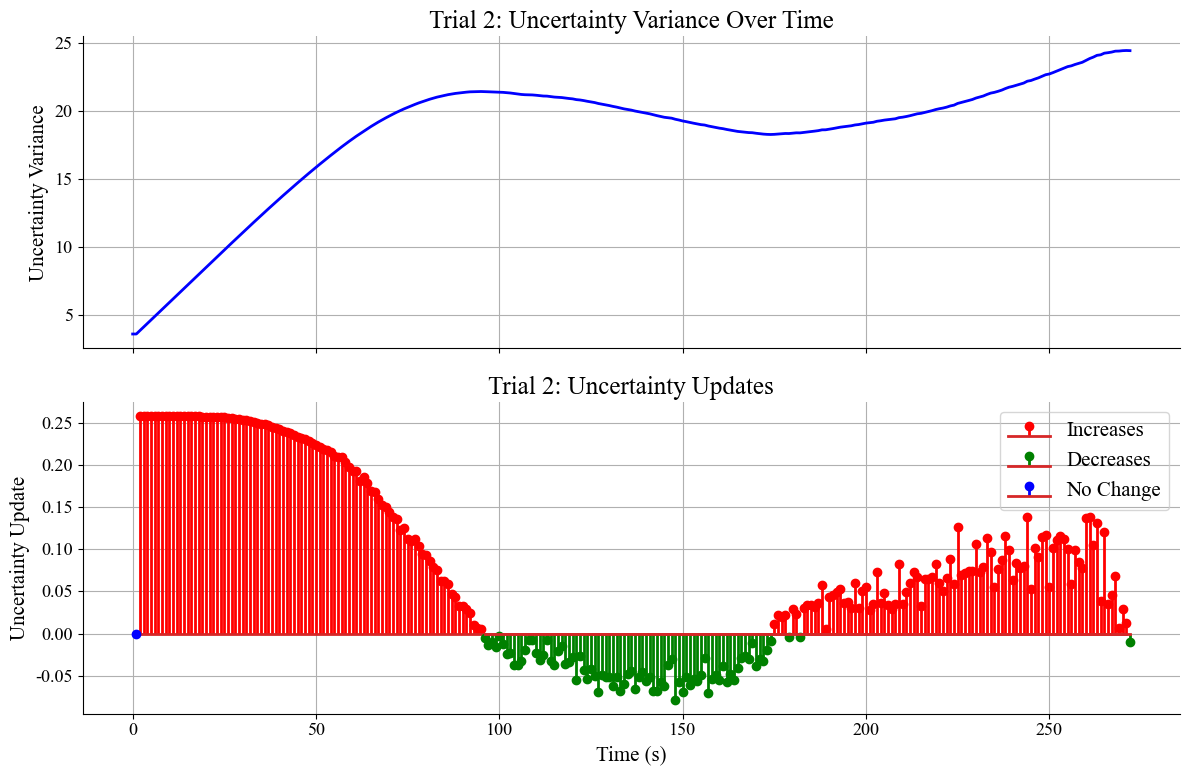

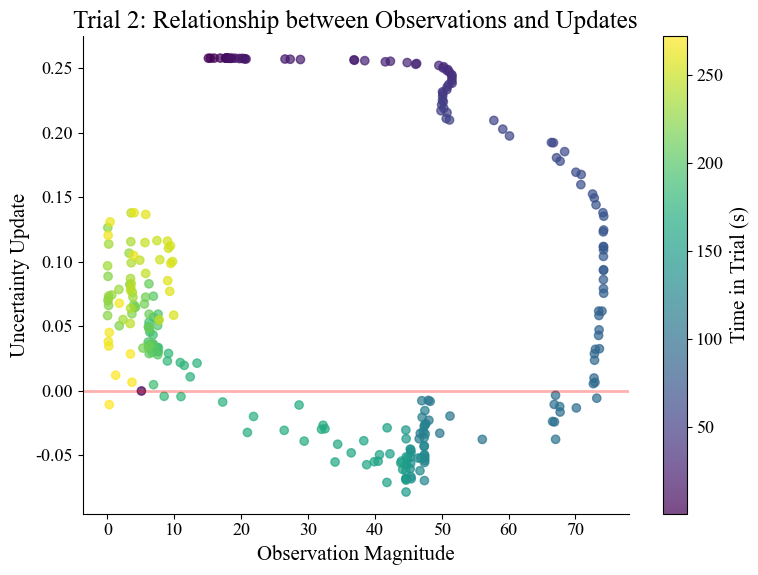


Trial 3 update statistics:
Number of uncertainty increases: 201
Number of uncertainty decreases: 0
Number of no changes: 1
Percent increases: 99.50%


ValueError: zero-size array to reduction operation minimum which has no identity

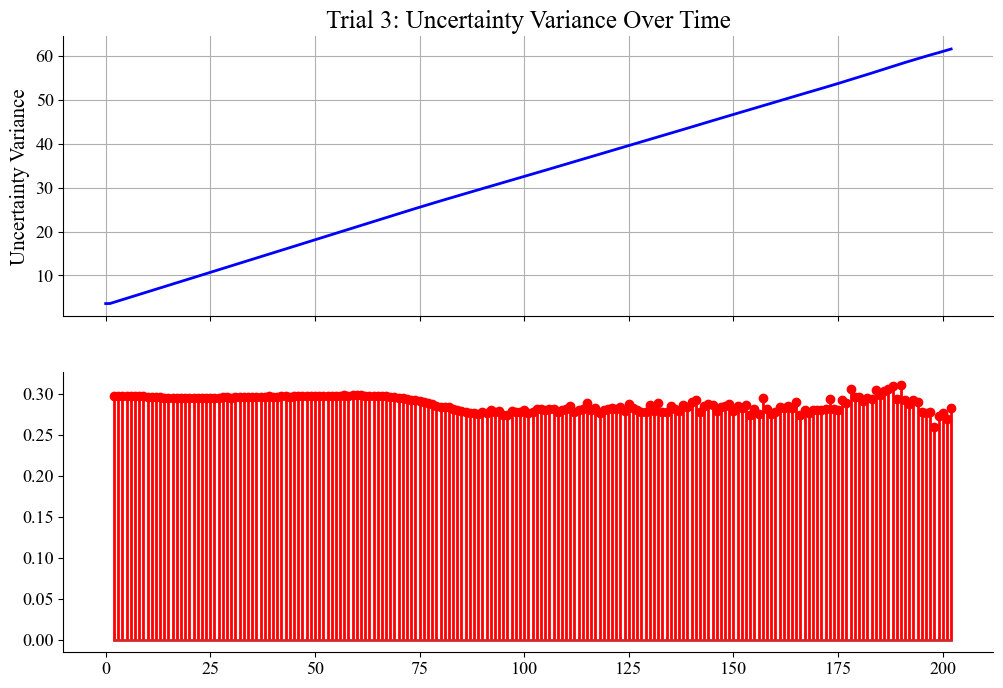

In [55]:
def analyze_uncertainty_updates_check(timedf):
    """Check for potential issues with uncertainty updates by looking within trials"""
    # Get unique trials
    unique_trials = np.unique(timedf.trial)
    print(f"Found {len(unique_trials)} unique trials to check")
    
    # Let's check a few trials in detail to diagnose the issue
    sample_trials = unique_trials[:5]  # Check first 5 trials
    
    for trial_num in sample_trials:
        # Extract data for this trial
        trial_data = timedf[timedf.trial == trial_num]
        
        if len(trial_data) < 10:  # Skip trials with too few samples
            continue
            
        trial_uncertainty_var = np.stack(trial_data.uncertainty.to_numpy())[:,0,0]  # variance
        trial_timer = trial_data.timer.to_numpy()
        trial_obs = np.abs(trial_data.mw.to_numpy())  # observation magnitude
        
        # Calculate updates
        d_uncertainty_var = np.diff(trial_uncertainty_var)
        
        # Count increases and decreases
        n_increases = np.sum(d_uncertainty_var > 0)
        n_decreases = np.sum(d_uncertainty_var < 0)
        n_same = np.sum(d_uncertainty_var == 0)
        
        print(f"\nTrial {trial_num} update statistics:")
        print(f"Number of uncertainty increases: {n_increases}")
        print(f"Number of uncertainty decreases: {n_decreases}")
        print(f"Number of no changes: {n_same}")
        print(f"Percent increases: {n_increases/(n_increases+n_decreases+n_same)*100:.2f}%")
        
        # Plot raw uncertainty and its updates
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        
        # Plot uncertainty over time
        ax1.plot(trial_timer, trial_uncertainty_var, 'b-', label='Uncertainty Variance')
        ax1.set_ylabel('Uncertainty Variance')
        ax1.set_title(f'Trial {trial_num}: Uncertainty Variance Over Time')
        ax1.grid(True)
        
        # Plot updates with color coding
        increase_mask = d_uncertainty_var > 0
        decrease_mask = d_uncertainty_var < 0
        same_mask = d_uncertainty_var == 0
        
        # We need to align the update indices with the original timer
        # Updates are calculated as the difference between consecutive points
        # So we'll use the second point's time for each update
        update_timer = trial_timer[1:]
        
        ax2.stem(update_timer[increase_mask], d_uncertainty_var[increase_mask], 'r', markerfmt='ro', label='Increases')
        ax2.stem(update_timer[decrease_mask], d_uncertainty_var[decrease_mask], 'g', markerfmt='go', label='Decreases')
        if np.sum(same_mask) > 0:
            ax2.stem(update_timer[same_mask], d_uncertainty_var[same_mask], 'b', markerfmt='bo', label='No Change')
        
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('Uncertainty Update')
        ax2.set_title(f'Trial {trial_num}: Uncertainty Updates')
        ax2.legend()
        ax2.grid(True)
        
        plt.tight_layout()
        plt.show()
        
        # Also plot relationship between observation magnitude and updates
        fig, ax = plt.subplots(figsize=(8, 6))
        
        update_obs = trial_obs[1:]  # Align with updates
        
        scatter = ax.scatter(update_obs, d_uncertainty_var, alpha=0.7, c=update_timer, cmap='viridis')
        ax.set_xlabel('Observation Magnitude')
        ax.set_ylabel('Uncertainty Update')
        ax.set_title(f'Trial {trial_num}: Relationship between Observations and Updates')
        ax.axhline(y=0, color='r', linestyle='-', alpha=0.3)
        cbar = plt.colorbar(scatter)
        cbar.set_label('Time in Trial (s)')
        plt.tight_layout()
        plt.show()
    
    # Now check overall statistics across all trials
    total_increases = 0
    total_decreases = 0
    total_same = 0
    
    # Store trials with high percentage of increases
    problematic_trials = []
    
    for trial_num in unique_trials:
        trial_data = timedf[timedf.trial == trial_num]
        
        if len(trial_data) < 10:  # Skip trials with too few samples
            continue
            
        trial_uncertainty_var = np.stack(trial_data.uncertainty.to_numpy())[:,0,0]  # variance
        
        # Calculate updates
        d_uncertainty_var = np.diff(trial_uncertainty_var)
        
        # Count increases and decreases
        n_increases = np.sum(d_uncertainty_var > 0)
        n_decreases = np.sum(d_uncertainty_var < 0)
        n_same = np.sum(d_uncertainty_var == 0)
        
        total_increases += n_increases
        total_decreases += n_decreases
        total_same += n_same
        
        # Track trials with high percentage of increases
        if len(d_uncertainty_var) > 0:
            percent_increases = n_increases / len(d_uncertainty_var) * 100
            if percent_increases > 50:  # More than half are increases
                problematic_trials.append((trial_num, percent_increases, len(d_uncertainty_var)))
    
    # Print overall statistics
    total_updates = total_increases + total_decreases + total_same
    print("\nOverall update statistics across all trials:")
    print(f"Total uncertainty increases: {total_increases} ({total_increases/total_updates*100:.2f}%)")
    print(f"Total uncertainty decreases: {total_decreases} ({total_decreases/total_updates*100:.2f}%)")
    print(f"Total no changes: {total_same} ({total_same/total_updates*100:.2f}%)")
    
    # Report problematic trials
    if len(problematic_trials) > 0:
        print(f"\nFound {len(problematic_trials)} trials with more increases than decreases")
        print("Top 10 most problematic trials:")
        
        # Sort by percentage of increases
        problematic_trials.sort(key=lambda x: x[1], reverse=True)
        
        for i, (trial, percent, count) in enumerate(problematic_trials[:10]):
            print(f"Trial {trial}: {percent:.2f}% increases out of {count} updates")
    
    return {
        'total_increases': total_increases,
        'total_decreases': total_decreases,
        'total_same': total_same,
        'problematic_trials': problematic_trials
    }

# Run the diagnostics
problematic_update_results = analyze_uncertainty_updates_check(timedf)

=== BASIC UNCERTAINTY ENCODING ANALYSIS ===
Analyzing correlations between neural dimensions and uncertainty/time...

Top 5 neural dimensions correlating with uncertainty:
Dimension 105: uncertainty r=-0.227 (p=0.000e+00), time r=-0.354 (p=0.000e+00)
Dimension 6: uncertainty r=-0.215 (p=0.000e+00), time r=-0.430 (p=0.000e+00)
Dimension 0: uncertainty r=-0.195 (p=0.000e+00), time r=-0.316 (p=0.000e+00)
Dimension 68: uncertainty r=-0.190 (p=0.000e+00), time r=-0.349 (p=0.000e+00)
Dimension 79: uncertainty r=-0.183 (p=0.000e+00), time r=-0.322 (p=0.000e+00)

Performing partial correlation analysis to control for time...

Top 5 neural dimensions with partial correlation to uncertainty (controlling for time):
Dimension 88: partial r=-0.060 (p=0.000e+00)
Dimension 70: partial r=-0.055 (p=5.012e-261)
Dimension 78: partial r=-0.052 (p=4.147e-239)
Dimension 105: partial r=-0.050 (p=6.734e-224)
Dimension 48: partial r=-0.044 (p=3.614e-174)

Performing linear regression to predict uncertainty fro

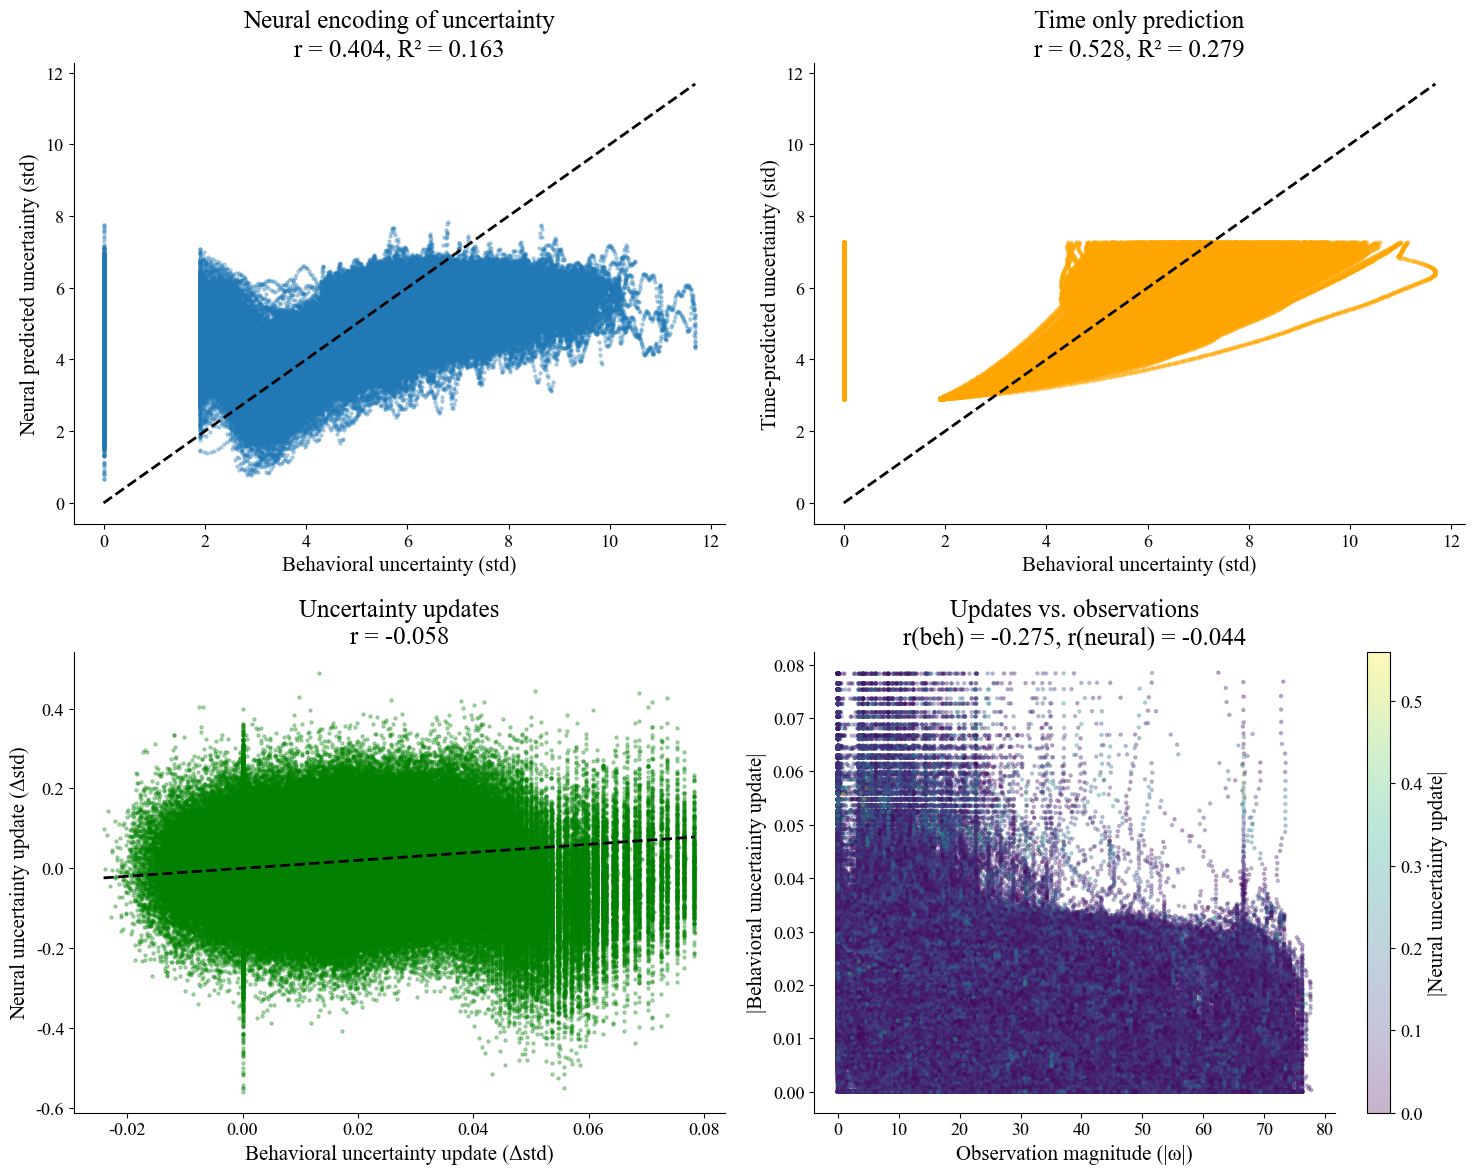


=== COMPARING STD VS VARIANCE FORMULATIONS ===

Comparing std vs variance formulations of uncertainty...
STD formulation: R² = 0.163, Correlation = 0.404 (p=0.000e+00)
VAR formulation: R² = 0.242, Correlation = 0.492 (p=0.000e+00)


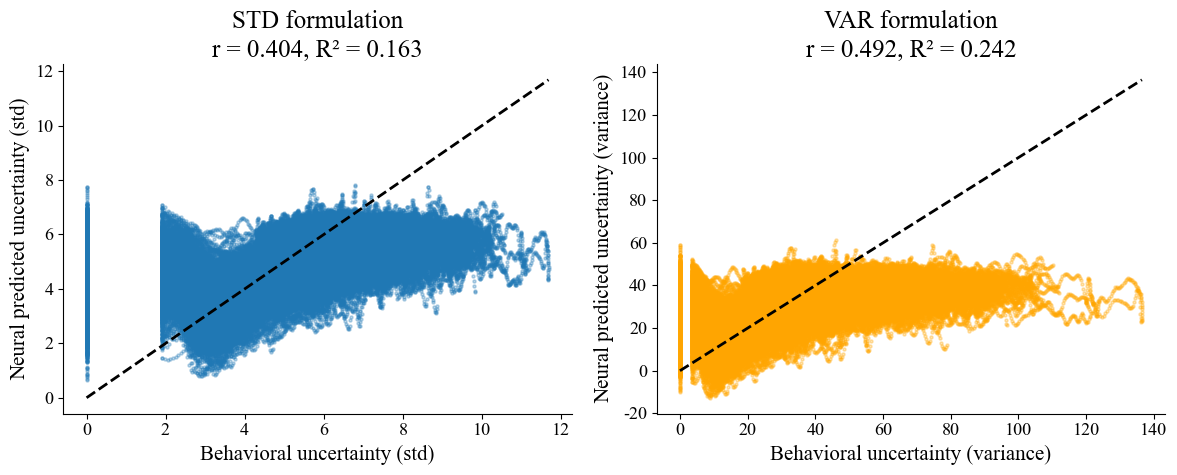


=== UNCERTAINTY-SPECIFIC ENCODING ===

Analyzing neural dimensions that encode uncertainty specifically...
Model using top 5 uncertainty-specific dimensions:
R² = 0.081, Correlation = 0.285 (p=0.000e+00)
Comparison - Full model: R² = 0.163, Time-only model: R² = 0.279


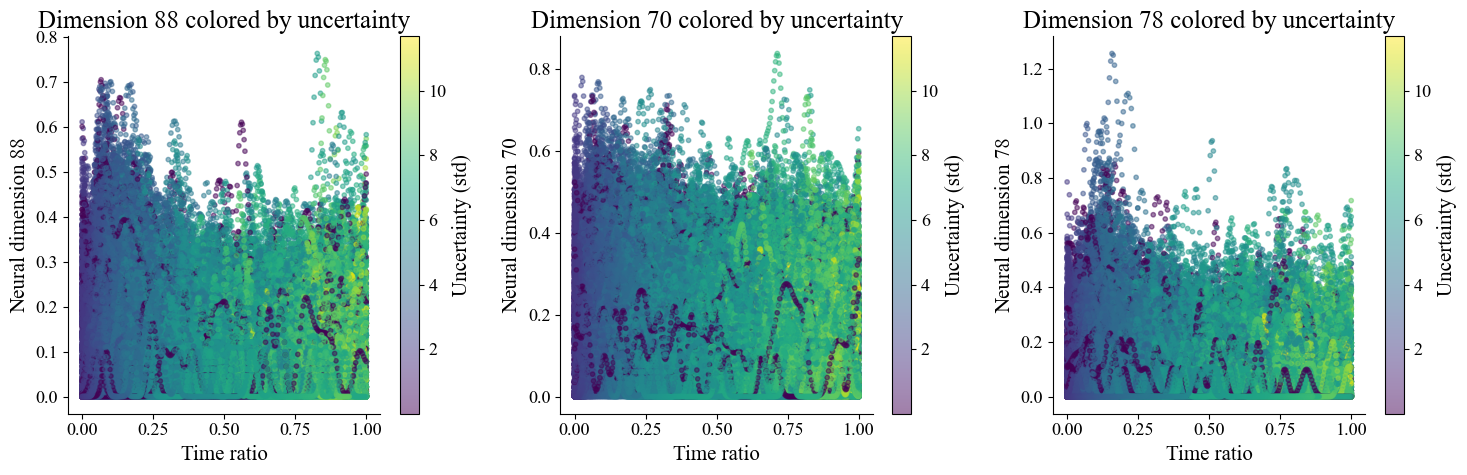


=== TRIAL-SPECIFIC ANALYSIS ===

Analyzing trial-specific uncertainty encoding...
Analyzing 1537 trials with sufficient data points...

Summary of trial-specific encoding:
Mean neural R² = -221318714215653026299904.000 (std: 5412266393395153883627520.000)
Mean time R² = 0.763 (std: 0.313)


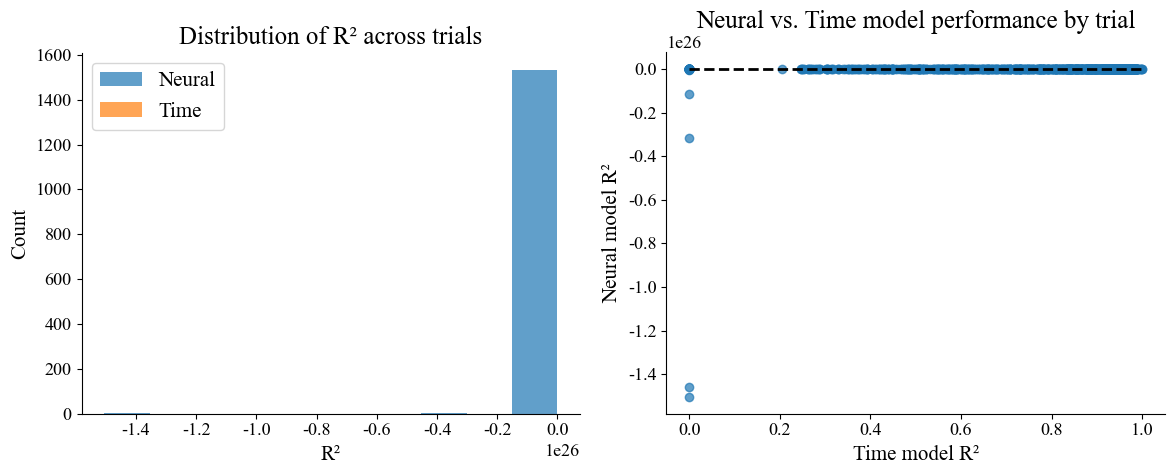

In [62]:
# 1. Compare std vs variance formulations of uncertainty
def compare_uncertainty_formulations(timedf, results):
    """Compare std vs variance formulations of uncertainty"""
    print("\nComparing std vs variance formulations of uncertainty...")
    
    neural_data = np.stack(timedf.PPC.to_numpy())
    
    # Extract both formulations of uncertainty
    beh_uncertainty_std = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5  # std
    beh_uncertainty_var = np.stack(timedf.uncertainty.to_numpy())[:,0,0]  # variance
    
    # Models
    model_std = LinearRegression()
    model_var = LinearRegression()
    
    # Cross-validated predictions
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    neural_uncertainty_std = cross_val_predict(model_std, neural_data, beh_uncertainty_std, cv=cv)
    neural_uncertainty_var = cross_val_predict(model_var, neural_data, beh_uncertainty_var, cv=cv)
    
    # Evaluate models
    r2_std = r2_score(beh_uncertainty_std, neural_uncertainty_std)
    r2_var = r2_score(beh_uncertainty_var, neural_uncertainty_var)
    
    corr_std, p_std = pearsonr(beh_uncertainty_std, neural_uncertainty_std)
    corr_var, p_var = pearsonr(beh_uncertainty_var, neural_uncertainty_var)
    
    print(f"STD formulation: R² = {r2_std:.3f}, Correlation = {corr_std:.3f} (p={p_std:.3e})")
    print(f"VAR formulation: R² = {r2_var:.3f}, Correlation = {corr_var:.3f} (p={p_var:.3e})")
    
    # Plot comparison
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(beh_uncertainty_std, neural_uncertainty_std, alpha=0.3, s=5)
    plt.plot([min(beh_uncertainty_std), max(beh_uncertainty_std)], 
             [min(beh_uncertainty_std), max(beh_uncertainty_std)], 'k--')
    plt.xlabel('Behavioral uncertainty (std)')
    plt.ylabel('Neural predicted uncertainty (std)')
    plt.title(f'STD formulation\nr = {corr_std:.3f}, R² = {r2_std:.3f}')
    
    plt.subplot(1, 2, 2)
    plt.scatter(beh_uncertainty_var, neural_uncertainty_var, alpha=0.3, s=5, color='orange')
    plt.plot([min(beh_uncertainty_var), max(beh_uncertainty_var)], 
             [min(beh_uncertainty_var), max(beh_uncertainty_var)], 'k--')
    plt.xlabel('Behavioral uncertainty (variance)')
    plt.ylabel('Neural predicted uncertainty (variance)')
    plt.title(f'VAR formulation\nr = {corr_var:.3f}, R² = {r2_var:.3f}')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'std': {'r2': r2_std, 'corr': corr_std, 'predictions': neural_uncertainty_std},
        'var': {'r2': r2_var, 'corr': corr_var, 'predictions': neural_uncertainty_var}
    }

# 2. Further analysis of neural dimensions that encode uncertainty beyond time
def analyze_uncertainty_specific_encoding(timedf, results):
    """Analyze neural dimensions that encode uncertainty specifically (not just time)"""
    print("\nAnalyzing neural dimensions that encode uncertainty specifically...")
    
    neural_data = np.stack(timedf.PPC.to_numpy())
    beh_uncertainty = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5  # std
    time_ratio = timedf.timeratio.to_numpy()
    
    # Get dimensions with strong partial correlation to uncertainty
    top_dims = results['top_partial_dims']
    
    # Extract top neural dimensions for uncertainty (controlling for time)
    top_neural_data = neural_data[:, top_dims]
    
    # Train a model using only these dimensions
    model = LinearRegression()
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    top_dim_predictions = cross_val_predict(model, top_neural_data, beh_uncertainty, cv=cv)
    
    # Evaluate
    r2_top = r2_score(beh_uncertainty, top_dim_predictions)
    corr_top, p_top = pearsonr(beh_uncertainty, top_dim_predictions)
    
    print(f"Model using top {len(top_dims)} uncertainty-specific dimensions:")
    print(f"R² = {r2_top:.3f}, Correlation = {corr_top:.3f} (p={p_top:.3e})")
    
    # Compare with full model and time-only model
    full_r2 = results['full_model_metrics']['r2']
    time_r2 = results['time_model_metrics']['r2']
    
    print(f"Comparison - Full model: R² = {full_r2:.3f}, Time-only model: R² = {time_r2:.3f}")
    
    # Visualize the top dimensions in relation to uncertainty and time
    plt.figure(figsize=(15, 5))
    
    for i, dim_idx in enumerate(top_dims[:3]):  # Plot the top 3 dimensions
        plt.subplot(1, 3, i+1)
        plt.scatter(time_ratio, neural_data[:, dim_idx], c=beh_uncertainty, 
                   cmap='viridis', alpha=0.5, s=10)
        plt.xlabel('Time ratio')
        plt.ylabel(f'Neural dimension {dim_idx}')
        plt.title(f'Dimension {dim_idx} colored by uncertainty')
        plt.colorbar(label='Uncertainty (std)')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'top_dims': top_dims,
        'top_dim_predictions': top_dim_predictions,
        'r2_top': r2_top,
        'corr_top': corr_top
    }

# 3. Analyze trial-specific encoding
def analyze_trial_specific_encoding(timedf, sessdf):
    """Analyze how uncertainty encoding varies across trials"""
    print("\nAnalyzing trial-specific uncertainty encoding...")
    
    neural_data = np.stack(timedf.PPC.to_numpy())
    beh_uncertainty = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5  # std
    time_ratio = timedf.timeratio.to_numpy()
    trial_ids = timedf.trial.to_numpy()
    
    # Get unique trials with enough data points
    unique_trials = np.unique(trial_ids)
    valid_trials = []
    
    for trial in unique_trials:
        if sum(trial_ids == trial) >= 10:  # Require at least 10 time points
            valid_trials.append(trial)
    
    print(f"Analyzing {len(valid_trials)} trials with sufficient data points...")
    
    # Analyze each trial
    trial_results = []
    
    for trial in valid_trials:
        # Get trial data
        trial_mask = trial_ids == trial
        trial_neural = neural_data[trial_mask]
        trial_uncertainty = beh_uncertainty[trial_mask]
        trial_time = time_ratio[trial_mask]
        
        # Full model (neural)
        model = LinearRegression()
        if len(trial_uncertainty) < 10:  # Skip trials with limited data
            continue
            
        # Use simple train/test split for very small sample sizes
        neural_pred = np.zeros_like(trial_uncertainty)
        time_pred = np.zeros_like(trial_uncertainty)
        
        # Simple 2-fold cross-validation
        for train_idx, test_idx in KFold(n_splits=2, shuffle=True, random_state=42).split(trial_neural):
            # Neural model
            model.fit(trial_neural[train_idx], trial_uncertainty[train_idx])
            neural_pred[test_idx] = model.predict(trial_neural[test_idx])
            
            # Time model
            time_model = LinearRegression()
            time_model.fit(trial_time[train_idx].reshape(-1, 1), trial_uncertainty[train_idx])
            time_pred[test_idx] = time_model.predict(trial_time[test_idx].reshape(-1, 1))
        
        # Evaluate
        neural_r2 = r2_score(trial_uncertainty, neural_pred)
        time_r2 = r2_score(trial_uncertainty, time_pred)
        neural_corr, neural_p = pearsonr(trial_uncertainty, neural_pred)
        time_corr, time_p = pearsonr(trial_uncertainty, time_pred)
        
        trial_results.append({
            'trial': trial,
            'neural_r2': neural_r2,
            'time_r2': time_r2,
            'neural_corr': neural_corr,
            'time_corr': time_corr,
            'n_points': sum(trial_mask)
        })
    
    # Convert to DataFrame
    trial_df = pd.DataFrame(trial_results)
    
    # Summary
    print("\nSummary of trial-specific encoding:")
    print(f"Mean neural R² = {trial_df['neural_r2'].mean():.3f} (std: {trial_df['neural_r2'].std():.3f})")
    print(f"Mean time R² = {trial_df['time_r2'].mean():.3f} (std: {trial_df['time_r2'].std():.3f})")
    
    # Plot comparisons
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(trial_df['neural_r2'], alpha=0.7, bins=10, label='Neural')
    plt.hist(trial_df['time_r2'], alpha=0.7, bins=10, label='Time')
    plt.xlabel('R²')
    plt.ylabel('Count')
    plt.title('Distribution of R² across trials')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.scatter(trial_df['time_r2'], trial_df['neural_r2'], alpha=0.7)
    plt.plot([min(trial_df['time_r2']), max(trial_df['time_r2'])],
             [min(trial_df['time_r2']), max(trial_df['time_r2'])], 'k--')
    plt.xlabel('Time model R²')
    plt.ylabel('Neural model R²')
    plt.title('Neural vs. Time model performance by trial')
    
    plt.tight_layout()
    plt.show()
    
    return trial_df


def comprehensive_uncertainty_analysis(timedf, sessdf):
    """Run a comprehensive analysis of neural encoding of uncertainty"""
    
    # Basic analysis
    print("=== BASIC UNCERTAINTY ENCODING ANALYSIS ===")
    results = analyze_neural_uncertainty(timedf, sessdf)
    
    # Additional analyses
    print("\n=== COMPARING STD VS VARIANCE FORMULATIONS ===")
    uncertainty_formulations = compare_uncertainty_formulations(timedf, results)
    
    print("\n=== UNCERTAINTY-SPECIFIC ENCODING ===")
    uncertainty_specific = analyze_uncertainty_specific_encoding(timedf, results)
    

    # Combine results
    all_results = {
        'basic': results,
        'formulations': uncertainty_formulations,
        'uncertainty_specific': uncertainty_specific,
        'trial_specific': trial_specific
    }
    
    return all_results

# Run the comprehensive analysis
all_results = comprehensive_uncertainty_analysis(timedf, sessdf)

